# Lección 11.4 · Enriquecimiento funcional: de una lista de genes a hipótesis biológicas

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-11-rnaseq/11.4_enriquecimiento_funcional.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 11 — Transcriptómica (RNA-seq)** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio–avanzado | Lecciones 11.2 (normalización) y 11.3 (expresión diferencial y FDR); probabilidad básica |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** qué son la Gene Ontology (sus tres ontologías, su grafo acíclico dirigido y la regla del camino
   verdadero), las rutas de KEGG y la colección *hallmark* de MSigDB, y **cargar** esas colecciones desde Enrichr.
2. **Calcular** a mano y con código el valor $p$ de sobrerrepresentación con la distribución hipergeométrica
   (ecuación 11-hiper del libro), **reconocer** que es la prueba exacta de Fisher unilateral y **corregir** miles de
   pruebas con Benjamini-Hochberg.
3. **Elegir** el universo correcto y **demostrar** con datos qué pasa cuando se usa el genoma entero.
4. **Diagnosticar** el sesgo de longitud con la función de probabilidad ponderada (PWF) de goseq y **corregirlo** por
   remuestreo ponderado y con la hipergeométrica no central de Wallenius.
5. **Programar desde cero** el paseo de GSEA (ecuación 11-gsea), la puntuación ES, la NES, el núcleo líder y los
   valores $p$ por permutación, y **compararlo** con `gseapy`.
6. **Interpretar** los resultados sobre un experimento real (músculo liso de vía aérea tratado con dexametasona)
   en términos de la biología de los glucocorticoides, con la prudencia que exige un enriquecimiento.

## 🗺️ Mapa de la clase

1. Demasiados pelirrojos en el autobús: la idea en cinco minutos
2. 🧪 Los datos: dexametasona en músculo liso de vía aérea y una clasificación compacta de genes
3. Vocabularios de función: GO, KEGG y *hallmarks* (y la regla del camino verdadero)
4. Análisis de sobrerrepresentación (ORA): hipergeométrica, Fisher y BH
5. El universo no es el genoma
6. El sesgo de longitud: PWF, «Un enriquecimiento espurio» (🎬 animación) y la corrección de goseq
7. GSEA sin umbrales: el paseo aleatorio (🎬 animación) y «Leer un resultado de GSEA»
8. 🧪 GSEA desde cero sobre el experimento real, permutaciones y comparación con `gseapy`
9. Lo que un enriquecimiento no dice
10. Ejercicios, resumen y lecturas

> 📖 Esta lección acompaña la sección **«Enriquecimiento funcional»** del capítulo 11 del libro. Usamos su notación
> ($N$, $K$, $n$, $k$ para la sobrerrepresentación; $r_j$, $g_j$, $N_H$, $N_R$, $p$, $P_{\mathrm{hit}}$,
> $P_{\mathrm{miss}}$, ES y NES para GSEA), sus figuras y sus dos ejemplos resueltos con las mismas cifras:
> **«Un enriquecimiento espurio»** ($N=9992$, $K=150$, $n=404$, $k=12$, $p=0{,}018$ que se convierte en $0{,}168$
> al corregir por longitud) y **«Leer un resultado de GSEA»** (ES $=0{,}668$ en la posición 1087, NES $=2{,}41$,
> $p=0{,}0016$, 30 genes líderes). La simulación del libro se reproduce exactamente a partir de un archivo pequeño
> del repositorio.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io, json, time, shutil, itertools
from collections import Counter
from scipy import stats, special, optimize, sparse
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import FancyBboxPatch, Rectangle
import warnings
warnings.filterwarnings("ignore", message="There are no gridspecs")    # aviso cosmético de las animaciones

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original; 3) copia en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=90) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

def read_table(name, **kw):
    """Tabla (tsv, opcionalmente comprimida) del directorio data/ del curso."""
    raw = course_bytes(name)
    if raw[:2] == b"\x1f\x8b":
        raw = gzip.decompress(raw)
    return pd.read_csv(io.BytesIO(raw), sep="\t", **kw)

def bh(p):
    """Valores q de Benjamini-Hochberg (lección 11.3)."""
    p = np.asarray(p, float); m = len(p); o = np.argsort(p)
    q = p[o] * m / np.arange(1, m + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(m); out[o] = np.minimum(q, 1)
    return out

T0 = time.time()
print("Utilidades listas ✔")

Entorno listo ✔  |  Colab: False


Utilidades listas ✔


---

## 1. Demasiados pelirrojos en el autobús

Empecemos sin genes. En una ciudad donde **uno de cada cincuenta** habitantes es pelirrojo, usted sube a un autobús
de **cuarenta** pasajeros y cuenta **siete** pelirrojos. Algo raro pasa: quizá el autobús viene de un congreso de
pelirrojos. Antes de concluirlo conviene hacerse dos preguntas:

1. **¿Cuántos pelirrojos cabría esperar por azar** en un autobús de ese tamaño? Si cada pasajero es pelirrojo con
   probabilidad $1/50$, en 40 pasajeros esperamos $40 \times 1/50 = 0{,}8$: **menos de uno**. Ver siete es mucho.
   Pero «mucho» no basta: hay que decir *cuán improbable* es ver siete o más si el autobús recoge gente al azar.
   Esa es la **prueba hipergeométrica**.
2. **¿El autobús recoge a la gente al azar**, o sólo pasa por un barrio donde los pelirrojos abundan? Si la ruta
   favorece a cierto tipo de pasajero, la cuenta «esperada» de la pregunta 1 está mal calculada. Ese es el **sesgo
   de selección** que obliga a corregir la prueba (en RNA-seq, el **sesgo de longitud**).

Cambie «pelirrojos» por «genes de la fosforilación oxidativa», «ciudad» por «los genes que medimos» y «autobús» por
«lista de genes diferencialmente expresados», y tendrá el problema de esta lección.

### Hagamos la cuenta a mano

Supongamos que la ciudad tiene $N = 5000$ habitantes, de los cuales $K = 100$ son pelirrojos ($1/50$), y que el
autobús toma $n = 40$ personas **sin reemplazo** (nadie sube dos veces). El número $X$ de pelirrojos a bordo sigue
una distribución **hipergeométrica**: la probabilidad de exactamente $x$ pelirrojos es el número de maneras de elegir
$x$ pelirrojos entre $K$ **y** $n-x$ no pelirrojos entre $N-K$, dividido entre todas las maneras de elegir $n$
personas entre $N$:

$$
\Pr(X = x) = \frac{\binom{K}{x}\binom{N-K}{n-x}}{\binom{N}{n}} .
$$

Para $x=0$: $\binom{100}{0}\binom{4900}{40}/\binom{5000}{40} \approx 0{,}444$ (casi la
mitad de los autobuses no llevan ningún pelirrojo). El valor $p$ de la observación es la suma de la cola,
$\Pr(X\ge 7)$. Calcularlo a mano es tedioso; para eso está el ordenador.

> 🤔 **Antes de ejecutar, prediga:** ¿el valor $p$ de ver 7 o más pelirrojos será del orden de $10^{-2}$, $10^{-4}$
> o $10^{-6}$?

Esperados por azar: E[X] = n·K/N = 0.80
P(X = 0)  = 0.444
P(X >= 7) = 1.13e-05   (sf(k-1) = P(X > k-1) = P(X >= k))
Con la binomial (ciudad infinita): 1.34e-05


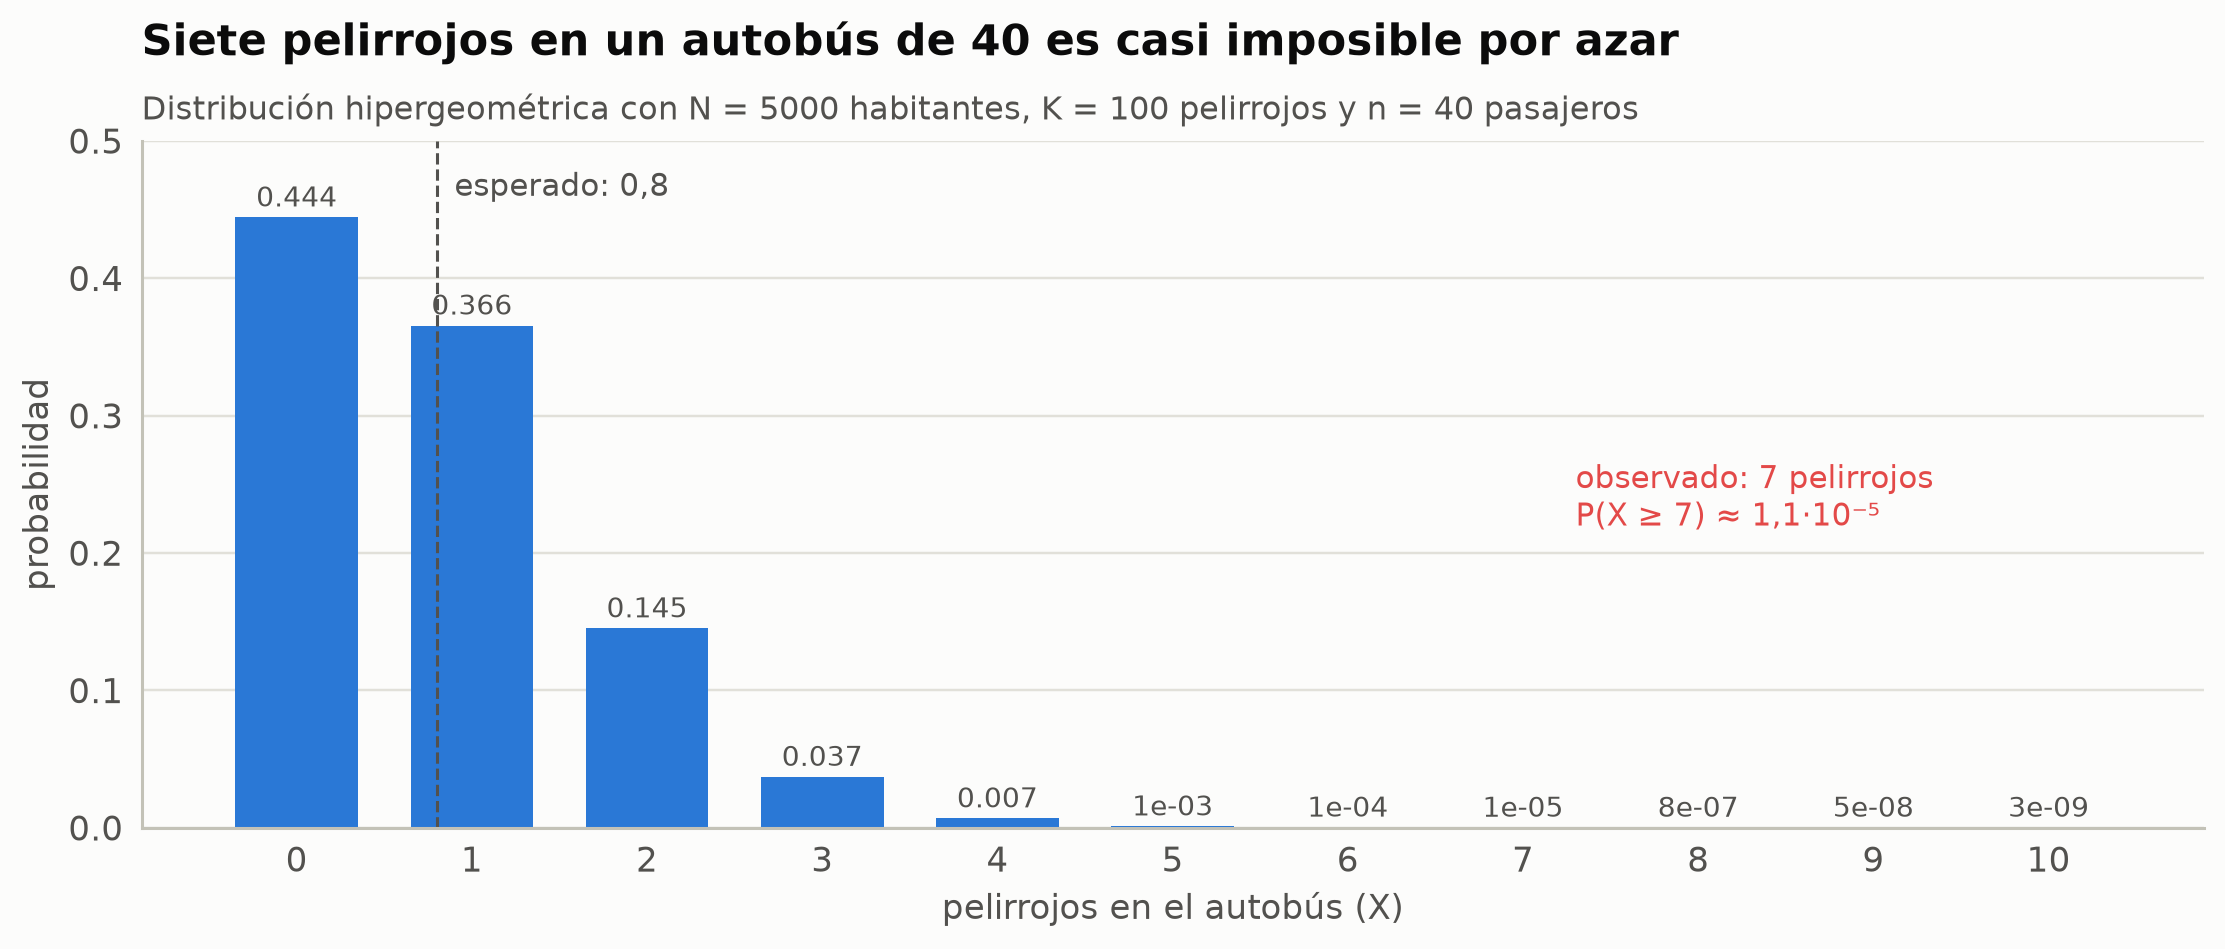

In [2]:
# El autobús: ciudad de N habitantes, K pelirrojos, autobús de n pasajeros, k observados
N_city, K_red, n_bus, k_obs = 5000, 100, 40, 7
X = stats.hypergeom(N_city, K_red, n_bus)            # SciPy usa el orden (M=N, n=K, N=n): ¡cuidado!
print(f"Esperados por azar: E[X] = n·K/N = {n_bus*K_red/N_city:.2f}")
print(f"P(X = 0)  = {X.pmf(0):.3f}")
print(f"P(X >= 7) = {X.sf(k_obs-1):.2e}   (sf(k-1) = P(X > k-1) = P(X >= k))")
print(f"Con la binomial (ciudad infinita): {stats.binom(n_bus, 1/50).sf(k_obs-1):.2e}")

x = np.arange(0, 11)
fig, ax = plt.subplots(figsize=(10, 4.2))
colors = [ec.RED if xi >= k_obs else ec.BLUE for xi in x]
ax.bar(x, X.pmf(x), color=colors, width=0.7)
for xi in x:
    pr = X.pmf(xi)
    ax.text(xi, pr + 0.008, f"{pr:.3f}" if pr >= 1e-3 else f"{pr:.0e}", ha="center", fontsize=9, color=ec.INK_2)
ax.axvline(n_bus * K_red / N_city, color=ec.INK_2, ls="--", lw=1)
ax.text(n_bus * K_red / N_city + 0.1, 0.46, "esperado: 0,8", color=ec.INK_2, fontsize=10)
ax.annotate("observado: 7 pelirrojos\nP(X ≥ 7) ≈ 1,1·10⁻⁵", xy=(7, 0.01), xytext=(7.3, 0.22),
            color=ec.RED, fontsize=10, arrowprops=dict(arrowstyle="->", color=ec.RED))
ax.set_xticks(x); ax.set_xlabel("pelirrojos en el autobús (X)"); ax.set_ylabel("probabilidad")
ax.set_ylim(0, 0.5)
ec.title(ax, "Siete pelirrojos en un autobús de 40 es casi imposible por azar",
         "Distribución hipergeométrica con N = 5000 habitantes, K = 100 pelirrojos y n = 40 pasajeros")
plt.show()

> 🔎 **Qué observamos.** El azar produce casi siempre 0, 1 o 2 pelirrojos; siete o más ocurre unas 11 veces en un
> millón de autobuses. La binomial da casi lo mismo porque el autobús es diminuto frente a la ciudad: muestrear
> sin reemplazo o con reemplazo apenas se distingue. En genómica el universo es de unos $10^4$ genes y las listas de
> cientos, así que la hipergeométrica es la elección natural. Fíjese también en el orden de los argumentos de
> SciPy, `hypergeom(M, n, N)` = (universo, éxitos en el universo, tamaño de la muestra): es la fuente de errores más
> frecuente al programar esta prueba.

> ✅ **Compruebe su comprensión.** Si el autobús recorre sólo un barrio donde uno de cada diez vecinos es
> pelirrojo, ¿cuántos esperaría ahora? ¿Seguiría siendo sorprendente ver siete? *(Esperaría 4; ver 7 o más ocurre
> con probabilidad ≈ 0,10: nada llamativo. El «enriquecimiento» se explica por la ruta, no por un congreso.)*

---

## 2. 🧪 Los datos: dexametasona en músculo liso de vía aérea

Los **glucocorticoides** inhalados (budesonida, fluticasona) son el tratamiento de base del asma, y la
**dexametasona** es el glucocorticoide sintético de referencia en el laboratorio. Actúan uniéndose al receptor de
glucocorticoides (GR, gen *NR3C1*), que entra al núcleo y **activa** genes con elementos de respuesta a
glucocorticoides (*FKBP5*, *TSC22D3*/GILZ, *DUSP1*, *PER1*, *KLF15*, *ZBTB16*) y **reprime** genes inflamatorios,
en buena parte interfiriendo con NF-κB y AP-1 (Rhen y Cidlowski, 2005).

Himes et al. (2014) secuenciaron el ARN de células de músculo liso de vía aérea de **cuatro donantes** (líneas
celulares) con y sin dexametasona 1 µM durante 18 h: es el experimento *airway*, el mismo que usa la viñeta de
DESeq2 y que analizamos en todo el Módulo 11. La matriz de conteos procede de **recount3** (Wilks et al., 2021):
recount3 guarda la cobertura por base sumada sobre los exones de cada gen (anotación GENCODE v26); nosotros la
dividimos entre las bases por fragmento y redondeamos para obtener conteos aproximados.

### Una clasificación compacta (la lección 11.3 hace el análisis completo)

El enriquecimiento necesita, como materia prima, **una tabla con una fila por gen**: su cambio, su valor $p$ y su
$q$ (para la sobrerrepresentación) y un **estadístico con signo** para ordenarlos (para GSEA). La lección 11.3
construye esa tabla con un GLM binomial negativo completo, al estilo DESeq2. Para que esta lección sea autosuficiente
y rápida calculamos aquí una versión **compacta** que aprovecha el diseño **pareado** (cada donante aporta una muestra
sin tratar y una tratada):

1. Normalizamos por **mediana de razones** (lección 11.2): $\tilde y_{gj} = y_{gj}/s_j$.
2. Para cada gen $g$ y donante $c$, la diferencia pareada en escala logarítmica,
   $d_{gc} = \log_2(\tilde y_{g,c,\mathrm{dex}}+1) - \log_2(\tilde y_{g,c,\mathrm{sin}}+1)$.
   Al restar dentro del mismo donante, la variación entre personas desaparece.
3. El log fold change es la media $\bar d_g$, y el estadístico es una $t$ pareada **moderada**: la varianza de cada
   gen, estimada con sólo 4 pares, se contrae hacia una varianza típica $s_0^2$ con $d_0$ grados de libertad
   «prestados» del resto de los genes (el método empírico-bayesiano de limma, Smyth, 2004):

$$
\tilde s_g^{2} = \frac{d_0\, s_0^{2} + d_g\, s_g^{2}}{d_0 + d_g},\qquad
\tilde t_g = \frac{\bar d_g}{\tilde s_g/\sqrt{m}},\qquad \tilde t_g \sim t_{d_0+d_g}\ \text{bajo } H_0 .
$$

| Símbolo | Significado |
|---|---|
| $y_{gj}$, $s_j$ | Conteo del gen $g$ en la muestra $j$ y factor de tamaño de la muestra |
| $d_{gc}$ | Diferencia pareada de $\log_2$ (dexametasona − sin tratar) del gen $g$ en el donante $c$ |
| $m$ | Número de pares (4 donantes); $d_g = m-1 = 3$ grados de libertad por gen |
| $s_g^2$, $\tilde s_g^2$ | Varianza de las diferencias del gen y su versión moderada |
| $s_0^2$, $d_0$ | Varianza previa y grados de libertad previos, estimados de todos los genes |
| $\tilde t_g$ | $t$ moderado: hará el papel del $z$ de Wald del libro para ordenar la lista en GSEA |

Nos quedamos con los genes **codificantes** con media normalizada $\ge 10$: ese será nuestro **universo**.

In [3]:
counts = read_table("airway_SRP033351_counts.tsv.gz")
samples = read_table("airway_SRP033351_samples.tsv")
lengths = read_table("114_gencode_v26_bp_length.tsv.gz")      # longitud exónica (unión de exones), GENCODE v26

design = samples[samples.treatment.isin(["Untreated", "Dexamethasone"])].sort_values(["cell", "treatment"])
print(design[["run", "cell", "treatment"]].to_string(index=False))

pc = counts[counts.gene_type == "protein_coding"].merge(lengths, on="gene_id")
pc = pc[~pc.symbol.duplicated(keep=False)].reset_index(drop=True)     # símbolos únicos (las colecciones usan símbolos)
Y = pc[design.run].to_numpy(float)

# 1) factores de tamaño por mediana de razones (lección 11.2)
logY = np.log(Y[(Y > 0).all(1)])
size_factors = np.exp(np.median(logY - logY.mean(1, keepdims=True), axis=0))
Yn = Y / size_factors
keep = Yn.mean(1) >= 10
pc, Y, Yn = pc[keep].reset_index(drop=True), Y[keep], Yn[keep]
print(f"\nfactores de tamaño: {np.round(size_factors, 3)}")
print(f"genes codificantes con media normalizada ≥ 10 (universo): {len(pc)}")

       run    cell     treatment
SRR1039513 N052611 Dexamethasone
SRR1039512 N052611     Untreated
SRR1039521 N061011 Dexamethasone
SRR1039520 N061011     Untreated
SRR1039517 N080611 Dexamethasone
SRR1039516 N080611     Untreated
SRR1039509  N61311 Dexamethasone
SRR1039508  N61311     Untreated



factores de tamaño: [1.354 0.897 1.289 1.15  1.067 0.998 0.684 0.77 ]
genes codificantes con media normalizada ≥ 10 (universo): 13922


In [4]:
# 2) diferencias pareadas por donante
cells = design.cell.to_numpy(); trt = design.treatment.to_numpy()
donors = sorted(set(cells))
i_ctl = [np.where((cells == c) & (trt == "Untreated"))[0][0] for c in donors]
i_dex = [np.where((cells == c) & (trt == "Dexamethasone"))[0][0] for c in donors]
L2 = np.log2(Yn + 1)
d = L2[:, i_dex] - L2[:, i_ctl]                       # genes x 4 donantes
m_pairs = d.shape[1]; df_g = m_pairs - 1
lfc = d.mean(1); s2 = d.var(1, ddof=1)

# 3) varianza previa por el método de momentos de Smyth (2004) sobre log s²
e = np.log(s2) - special.digamma(df_g / 2) + np.log(df_g / 2)
e_mean = e.mean()
e_var = e.var(ddof=1) - special.polygamma(1, df_g / 2)
d0 = 2 * optimize.brentq(lambda x: special.polygamma(1, x) - e_var, 1e-6, 1e6)
s0_2 = np.exp(e_mean + special.digamma(d0 / 2) - np.log(d0 / 2))
s2_mod = (d0 * s0_2 + df_g * s2) / (d0 + df_g)
t_mod = lfc / np.sqrt(s2_mod / m_pairs)
pval = 2 * stats.t.sf(np.abs(t_mod), df_g + d0)
print(f"d0 = {d0:.2f} grados de libertad previos · s0 = {np.sqrt(s0_2):.3f} (log2)")

ranking = pd.DataFrame({"gene_id": pc.gene_id, "symbol": pc.symbol, "bp_length": pc.bp_length,
                        "baseMean": Yn.mean(1), "log2FC": lfc, "t": t_mod, "pvalue": pval, "padj": bh(pval)})
ranking = ranking.sort_values("t", ascending=False).reset_index(drop=True)
if os.path.isdir(os.path.join("..", "data")):          # copia de respaldo en el repositorio (sólo en local)
    ranking.to_csv(os.path.join("..", "data", "114_airway_dex_ranking.tsv.gz"), sep="\t", index=False,
                   float_format="%.6g")
n_q = (ranking.padj < 0.05).sum()
print(f"genes con q < 0,05: {n_q}  ·  además |log2FC| > 1: {((ranking.padj < 0.05) & (ranking.log2FC.abs() > 1)).sum()}")

gc_genes = ["FKBP5", "TSC22D3", "ZBTB16", "PER1", "KLF15", "DUSP1", "CRISPLD2", "MT2A"]
print("\nGenes clásicos de respuesta a glucocorticoides:")
print(ranking[ranking.symbol.isin(gc_genes)][["symbol", "baseMean", "log2FC", "t", "padj"]]
      .assign(rango=lambda x: x.index + 1).round(4).to_string(index=False))

d0 = 2.45 grados de libertad previos · s0 = 0.174 (log2)
genes con q < 0,05: 4395  ·  además |log2FC| > 1: 905

Genes clásicos de respuesta a glucocorticoides:
  symbol  baseMean  log2FC       t   padj  rango
  ZBTB16  459.2252  7.1738 30.0510 0.0005      7
   DUSP1 4173.3104  2.9435 25.0773 0.0006     13
    MT2A 4219.4528  2.1811 23.2238 0.0007     16
    PER1  960.8145  3.1947 19.9681 0.0010     27
   KLF15  684.9966  4.3758 17.4561 0.0011     42
   FKBP5 3137.1319  4.0133 14.0359 0.0013    104
CRISPLD2 3761.6020  2.6081 12.3280 0.0017    151
 TSC22D3 2699.5621  3.1791 11.9583 0.0019    163


> 🔎 **Qué observamos.** Los genes de manual de la respuesta a glucocorticoides están todos arriba y con cambios
> enormes: *ZBTB16* y *FKBP5* se multiplican por decenas, *TSC22D3* (GILZ) y *DUSP1* (MKP-1, que apaga las MAP
> quinasas inflamatorias) por 5–10, y *CRISPLD2*, el gen que Himes et al. (2014) destacaron en el título de su
> artículo, también aparece inducido. El análisis compacto recupera la biología conocida, así que podemos usarlo como
> materia prima. Guardamos la tabla en `data/114_airway_dex_ranking.tsv.gz`. (La lección 11.3 guarda
> su análisis completo en `data/113_airway_dex_results.tsv.gz`; como ejercicio, repita el enriquecimiento con esa
> tabla y compare los términos principales.) No espere el mismo número de genes significativos que en 11.3 (5 684 con
> `padj` < 0,05; aquí, 4 395 con $q$ < 0,05): la prueba es una $t$ moderada al estilo limma, no un GLM binomial
> negativo, y tanto la normalización como el universo usan sólo genes codificantes (el universo, además, con media
> $\ge 10$), así que hasta los factores de tamaño cambian un poco (1,354 para SRR1039513, frente a 1,369 en 11.3). Lo que debe coincidir, y coincide, es la biología: las mismas dianas arriba.

La figura interactiva siguiente es un gráfico *volcano*. Pase el ratón por los puntos: verá el símbolo, el cambio,
el $t$ moderado, el valor $q$ y la **longitud** del gen, que usaremos en la sección 6.

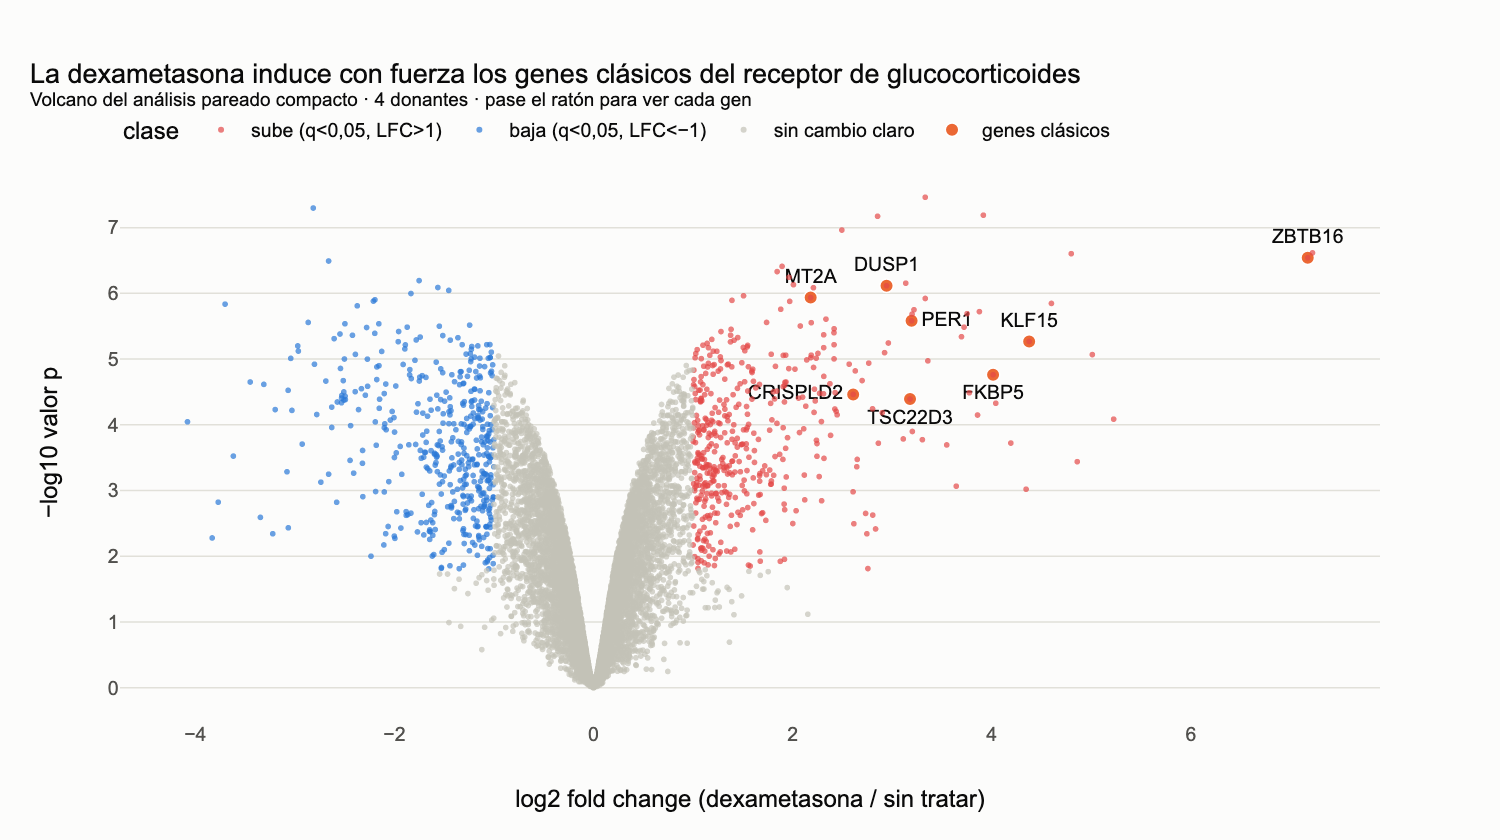

In [5]:
vol = ranking.copy()
vol["mlog10p"] = -np.log10(vol.pvalue)
vol["clase"] = np.select([(vol.padj < 0.05) & (vol.log2FC > 1), (vol.padj < 0.05) & (vol.log2FC < -1)],
                         ["sube (q<0,05, LFC>1)", "baja (q<0,05, LFC<−1)"], "sin cambio claro")
vol["nota"] = np.where(vol.symbol.isin(gc_genes), "gen clásico de respuesta a glucocorticoides", "")
cmap = {"sube (q<0,05, LFC>1)": ec.RED, "baja (q<0,05, LFC<−1)": ec.BLUE, "sin cambio claro": ec.BASELINE}
fig = px.scatter(vol, x="log2FC", y="mlog10p", color="clase", color_discrete_map=cmap, render_mode="webgl",
                 custom_data=["symbol", "t", "padj", "bp_length", "baseMean", "nota"],
                 category_orders={"clase": list(cmap)})
fig.update_traces(marker=dict(size=4, opacity=0.7),
                  hovertemplate="<b>%{customdata[0]}</b> %{customdata[5]}<br>log2FC = %{x:.2f} (×%{text})"
                                "<br>t moderado = %{customdata[1]:.1f}<br>q = %{customdata[2]:.2g}"
                                "<br>longitud exónica = %{customdata[3]:,} pb<br>media normalizada = %{customdata[4]:.0f}"
                                "<extra></extra>")
for tr in fig.data:                                     # factor de cambio en escala lineal para el hover
    tr.text = [f"{2**v:.2f}" for v in tr.x]
lab = vol[vol.symbol.isin(gc_genes)]
fig.add_trace(go.Scatter(x=lab.log2FC, y=lab.mlog10p, mode="markers+text", text=lab.symbol,
                         textposition=[{"CRISPLD2": "middle left", "TSC22D3": "bottom center", "PER1": "middle right",
                                       "FKBP5": "bottom center"}.get(g, "top center") for g in lab.symbol],
                         marker=dict(size=9, color=ec.ORANGE, line=dict(color="white", width=1)),
                         name="genes clásicos", hoverinfo="skip"))
fig.update_layout(title="La dexametasona induce con fuerza los genes clásicos del receptor de glucocorticoides"
                        "<br><sup>Volcano del análisis pareado compacto · 4 donantes · pase el ratón para ver cada gen</sup>",
                  xaxis_title="log2 fold change (dexametasona / sin tratar)", yaxis_title="−log10 valor p",
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=560, margin=dict(t=110))
fig.show()

---

## 3. Vocabularios de función: GO, KEGG y *hallmarks*

Una lista de 400 genes no es un resultado biológico. Para interpretarla necesitamos saber **qué hacen** esos genes,
y hacerlo de forma sistemática, no gen a gen con la memoria de cada cual.

### La Gene Ontology

La **Gene Ontology** (GO; Ashburner et al., 2000) nació para que las bases de datos de organismos modelo describieran
los productos génicos con un **vocabulario común**. Tiene tres ontologías independientes:

| Ontología | Pregunta que responde | Ejemplo |
|---|---|---|
| **Proceso biológico** (BP) | ¿Qué contribuye a conseguir el gen? | «fosforilación oxidativa» |
| **Función molecular** (MF) | ¿Qué actividad bioquímica tiene? | «actividad de citocromo c oxidasa» |
| **Componente celular** (CC) | ¿Dónde actúa? | «membrana mitocondrial interna» |

Los términos no forman una lista plana sino un **grafo acíclico dirigido** (DAG): cada término puede tener **varios
padres**, conectados por relaciones como `is_a` («es un tipo de») o `part_of` («es parte de»). Un árbol genealógico
en el que un hijo pudiera tener tres padres sería un DAG, no un árbol. Hoy la GO reúne decenas de miles de términos y
millones de anotaciones de miles de especies (The Gene Ontology Consortium, 2023).

> **Regla del camino verdadero.** Si un gen está anotado a un término, está implícitamente anotado a **todos sus
> ancestros** en el grafo. Por eso los términos generales («proceso metabólico») contienen miles de genes y los
> específicos, unas decenas.

La figura reproduce el fragmento de la ontología de procesos biológicos que dibuja el libro.

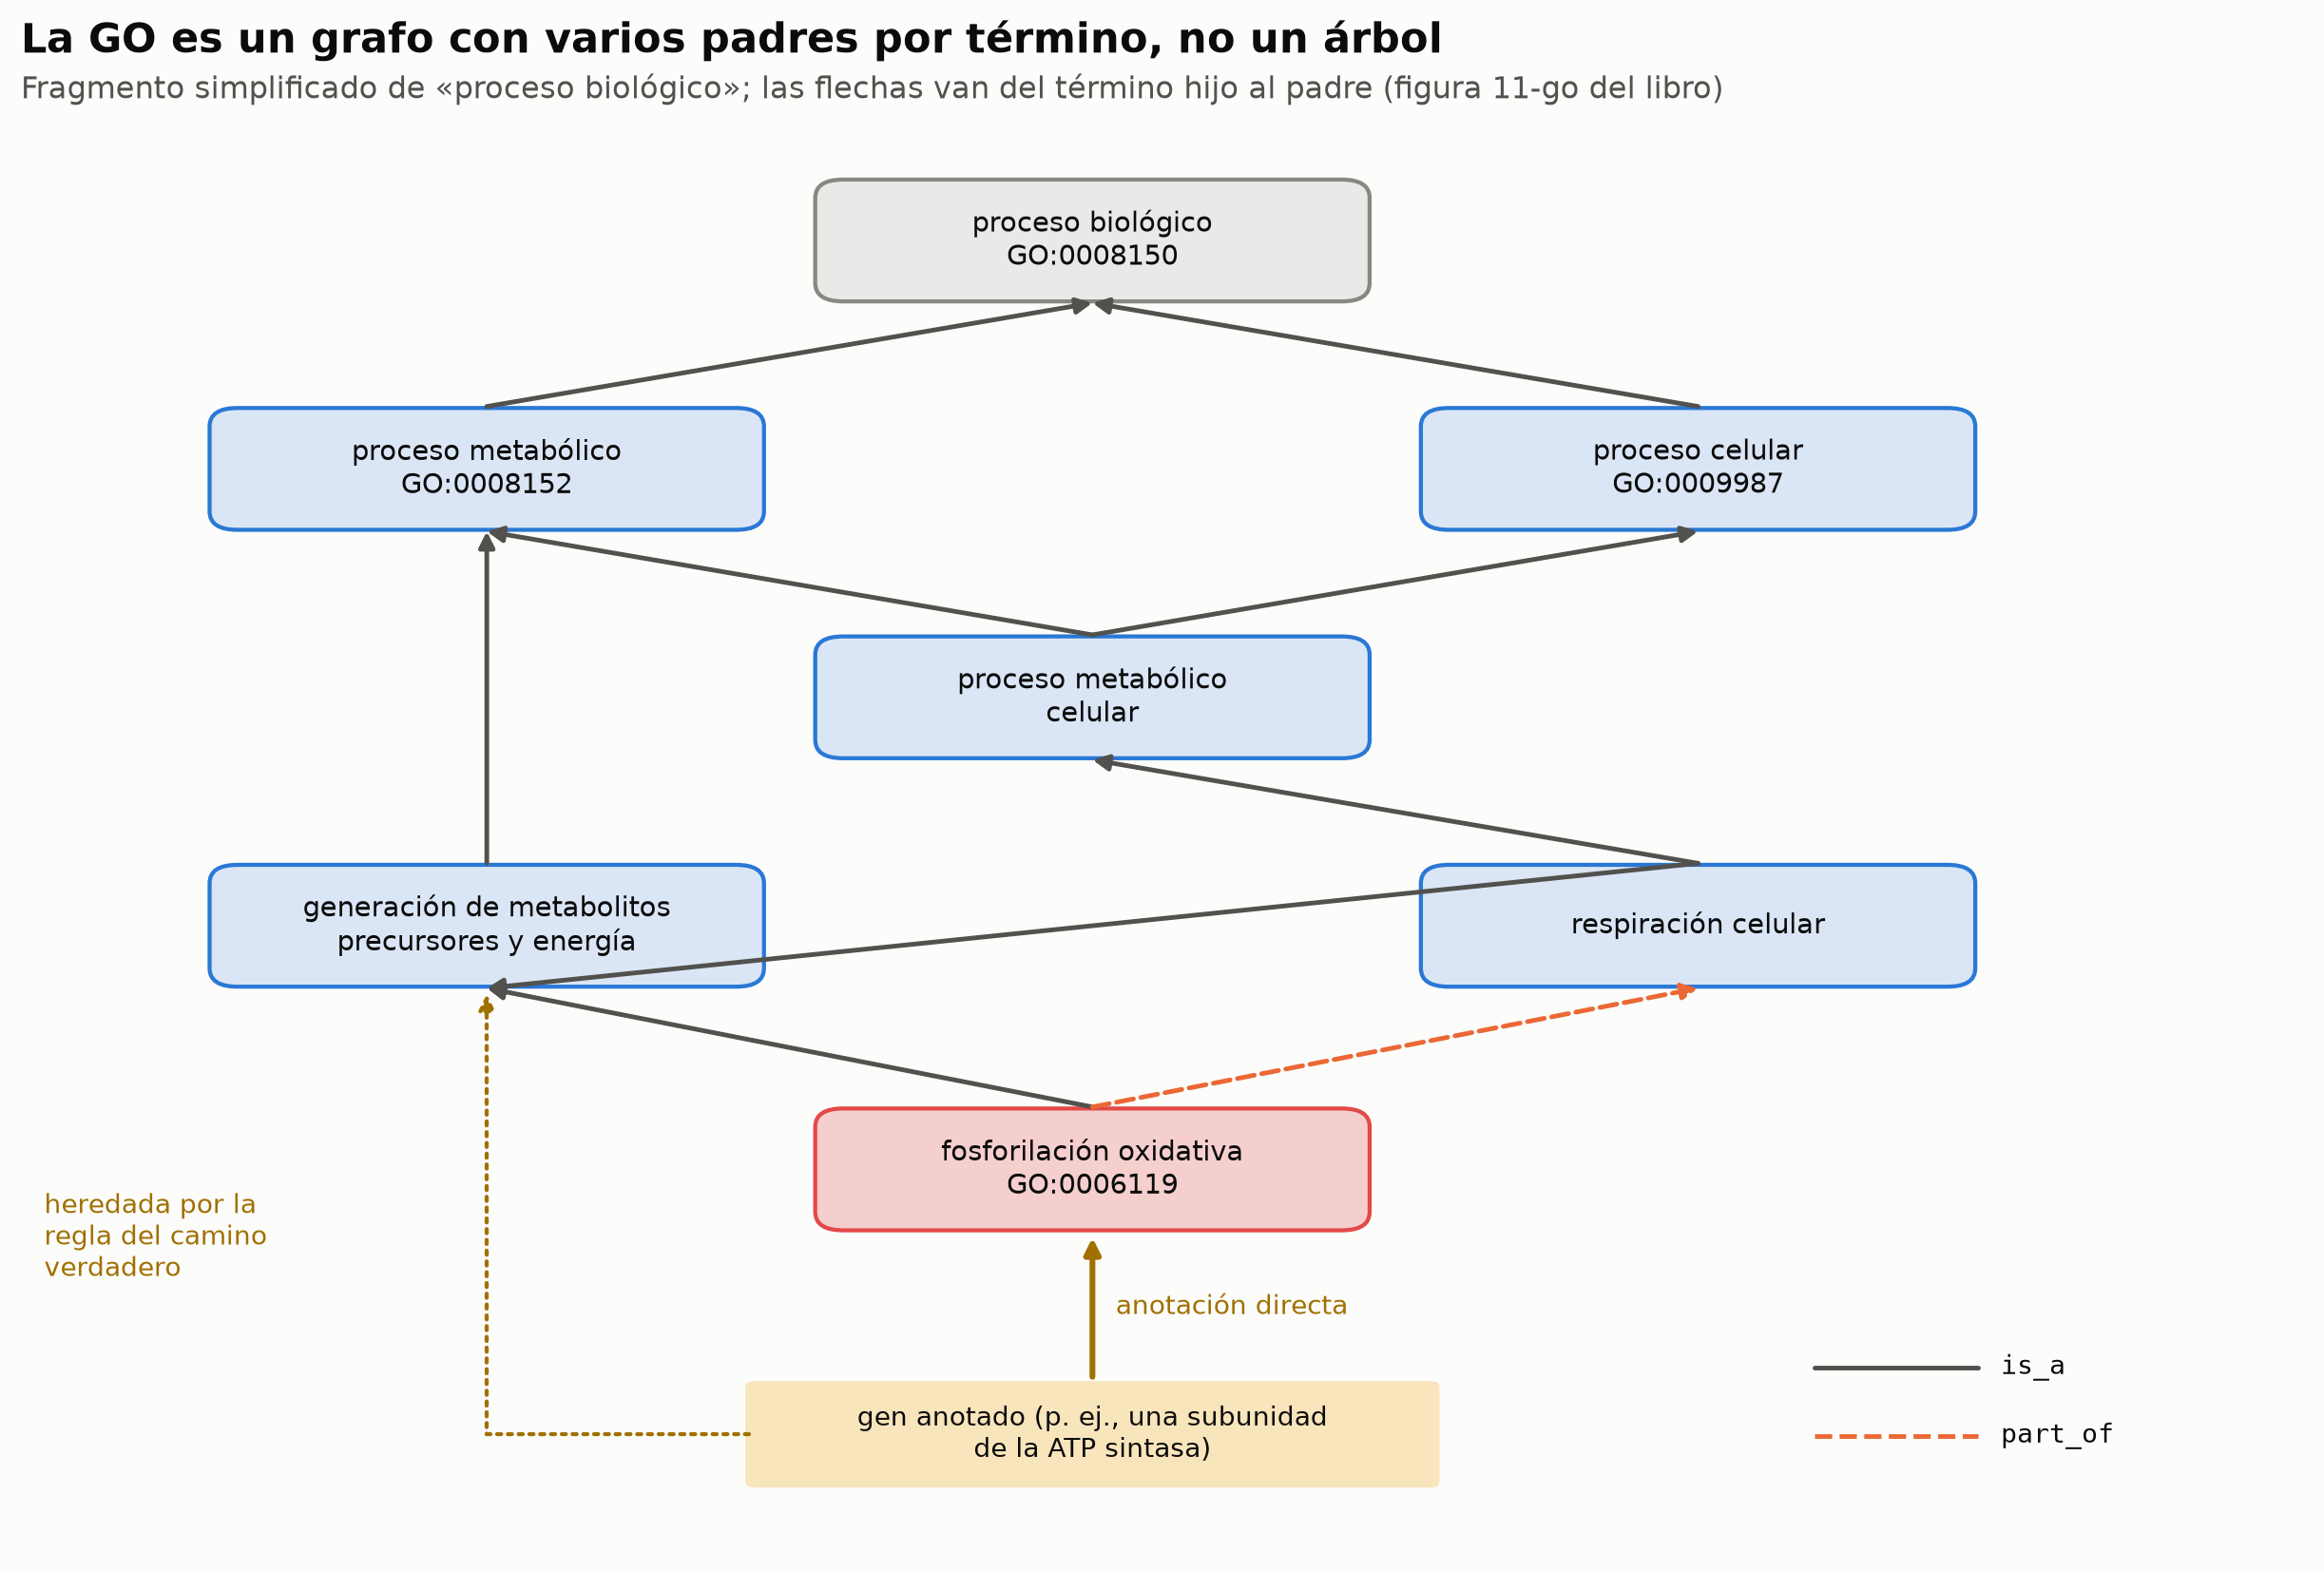

Un gen anotado a 'fosforilación oxidativa' cuenta también para:
   · proceso biológico GO:0008150
   · proceso metabólico GO:0008152
   · proceso celular GO:0009987
   · proceso metabólico celular
   · generación de metabolitos precursores y energía
   · respiración celular


In [6]:
# Fragmento de la GO (figura 11-go del libro): nodos, posiciones y relaciones hijo -> padre
nodes = {"bp":   ("proceso biológico\nGO:0008150", (3.2, 4.6), ec.MUTED),
         "met":  ("proceso metabólico\nGO:0008152", (0.6, 3.1), ec.BLUE),
         "cel":  ("proceso celular\nGO:0009987", (5.8, 3.1), ec.BLUE),
         "cmet": ("proceso metabólico\ncelular", (3.2, 1.6), ec.BLUE),
         "ener": ("generación de metabolitos\nprecursores y energía", (0.6, 0.1), ec.BLUE),
         "resp": ("respiración celular", (5.8, 0.1), ec.BLUE),
         "oxp":  ("fosforilación oxidativa\nGO:0006119", (3.2, -1.5), ec.RED)}
edges = [("met", "bp", "is_a"), ("cel", "bp", "is_a"), ("cmet", "met", "is_a"), ("cmet", "cel", "is_a"),
         ("ener", "met", "is_a"), ("resp", "cmet", "is_a"), ("resp", "ener", "is_a"),
         ("oxp", "ener", "is_a"), ("oxp", "resp", "part_of")]

fig, ax = plt.subplots(figsize=(11, 7.4))
ax.set_xlim(-1.4, 8.4); ax.set_ylim(-4.0, 5.3); ax.axis("off"); ax.grid(False)
W, H = 2.3, 0.72
for key, (txt, (x, y), col) in nodes.items():
    ax.add_patch(FancyBboxPatch((x - W / 2, y - H / 2), W, H, boxstyle="round,pad=0.04,rounding_size=0.12",
                                fc=col, ec="none", alpha=0.16 if col != ec.RED else 0.25))
    ax.add_patch(FancyBboxPatch((x - W / 2, y - H / 2), W, H, boxstyle="round,pad=0.04,rounding_size=0.12",
                                fc="none", ec=col, lw=1.4))
    ax.text(x, y, txt, ha="center", va="center", fontsize=9.5, color=ec.INK)
for child, parent, rel in edges:
    (x0, y0), (x1, y1) = nodes[child][1], nodes[parent][1]
    ax.annotate("", xy=(x1, y1 - H / 2 - 0.05), xytext=(x0, y0 + H / 2 + 0.05),
                arrowprops=dict(arrowstyle="-|>", lw=1.6, color=ec.ORANGE if rel == "part_of" else ec.INK_2,
                                ls="--" if rel == "part_of" else "-", shrinkA=0, shrinkB=0))
# el gen anotado y la herencia por el camino verdadero
ax.add_patch(FancyBboxPatch((1.75, -3.55), 2.9, 0.62, boxstyle="round,pad=0.04", fc=ec.YELLOW, alpha=0.25, ec=ec.YELLOW))
ax.text(3.2, -3.24, "gen anotado (p. ej., una subunidad\nde la ATP sintasa)", ha="center", va="center", fontsize=9)
ax.annotate("", xy=(3.2, -1.5 - H / 2 - 0.05), xytext=(3.2, -2.9), arrowprops=dict(arrowstyle="-|>", lw=2, color="#a07000"))
ax.text(3.3, -2.45, "anotación directa", fontsize=9, color="#a07000")
ax.annotate("", xy=(0.6, 0.1 - H / 2 - 0.05), xytext=(1.75, -3.24),
            arrowprops=dict(arrowstyle="-|>", lw=1.4, color="#a07000", ls=":", connectionstyle="angle,angleA=180,angleB=90"))
ax.text(-1.3, -2.2, "heredada por la\nregla del camino\nverdadero", fontsize=9, color="#a07000")
ax.plot([6.3, 7.0], [-2.8, -2.8], color=ec.INK_2, lw=1.6); ax.text(7.1, -2.8, "is_a", va="center", family="monospace", fontsize=9)
ax.plot([6.3, 7.0], [-3.25, -3.25], color=ec.ORANGE, lw=1.6, ls="--"); ax.text(7.1, -3.25, "part_of", va="center", family="monospace", fontsize=9)
ec.title(ax, "La GO es un grafo con varios padres por término, no un árbol",
         "Fragmento simplificado de «proceso biológico»; las flechas van del término hijo al padre (figura 11-go del libro)")
plt.show()

# La regla del camino verdadero en código: propagar una anotación a todos los ancestros
parents = {}
for child, parent, _ in edges:
    parents.setdefault(child, []).append(parent)

def ancestors(term):
    """Todos los ancestros de un término (búsqueda en profundidad por el DAG)."""
    out, stack = set(), [term]
    while stack:
        for p_ in parents.get(stack.pop(), []):
            if p_ not in out:
                out.add(p_); stack.append(p_)
    return out

anc = ancestors("oxp")
print("Un gen anotado a 'fosforilación oxidativa' cuenta también para:")
for a_ in sorted(anc, key=lambda k: -nodes[k][1][1]):
    print("   ·", nodes[a_][0].replace("\n", " "))

> 🔎 **Qué observamos.** Un único gen de la ATP sintasa, anotado **una vez** a «fosforilación oxidativa», acaba
> contando para **seis** términos. Esa herencia tiene una consecuencia estadística importante: los términos están
> fuertemente **anidados**, así que sus pruebas de enriquecimiento **no son independientes**. Si un grupo de genes
> hace significativo a un término, arrastra también a sus padres y abuelos, y la tabla de resultados parece mostrar
> muchos hallazgos cuando en realidad hay uno solo (volveremos sobre esto en la sección 9).

### KEGG y los *hallmarks* de MSigDB

**KEGG** (Kanehisa y Goto, 2000) ofrece otra organización: en lugar de un vocabulario jerárquico, **mapas de rutas**
dibujados a mano (metabolismo, señalización, enfermedades) en los que cada gen ocupa un nodo concreto. Sus conjuntos
son menos numerosos y más fáciles de interpretar, a cambio de cubrir menos genes. La colección **MSigDB** reúne además
miles de conjuntos de estudios publicados; su colección ***hallmark*** (Liberzon et al., 2015) condensa esa
redundancia en **50 «marcas»** de procesos biológicos bien definidos, una buena elección para una primera exploración.

### Cargar las colecciones desde Enrichr

El servidor **Enrichr** (Kuleshov et al., 2016) distribuye estas colecciones como texto plano: una línea por conjunto,
con el nombre, un campo vacío y los símbolos de los genes separados por tabuladores. Usamos tres bibliotecas y
guardamos una copia comprimida en `data/api_cache/` para que la clase funcione sin red:

| Biblioteca de Enrichr | Contenido |
|---|---|
| `MSigDB_Hallmark_2020` | Los 50 *hallmarks* |
| `KEGG_2021_Human` | Rutas de KEGG humanas |
| `GO_Biological_Process_2023` | Términos de proceso biológico de la GO |

In [7]:
ENRICHR = "https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName="

def load_library(lib):
    """Colección de Enrichr como {término: set(símbolos)}: copia local → Enrichr → GitHub."""
    raw = course_bytes(f"api_cache/enrichr_{lib}.txt.gz", live_url=ENRICHR + lib)
    if raw[:2] == b"\x1f\x8b":                     # la copia del curso está comprimida; Enrichr envía texto plano
        raw = gzip.decompress(raw)
    sets = {}
    for line in raw.decode().splitlines():
        f = line.rstrip("\t").split("\t")
        genes = {g.split(",")[0] for g in f[2:] if g}      # algunas bibliotecas antiguas añaden ",peso"
        if genes:
            sets[f[0]] = genes
    return sets

LIBS = {"Hallmark": "MSigDB_Hallmark_2020", "KEGG": "KEGG_2021_Human", "GO BP": "GO_Biological_Process_2023"}
libraries = {short: load_library(lib) for short, lib in LIBS.items()}
universe = set(ranking.symbol)
rows = []
for short, sets in libraries.items():
    all_genes = set().union(*sets.values())
    sizes = np.array([len(s & universe) for s in sets.values()])
    rows.append({"colección": short, "conjuntos": len(sets), "genes distintos": len(all_genes),
                 "% de sus genes en nuestro universo": round(100 * len(all_genes & universe) / len(all_genes), 1),
                 "conjuntos con 15–500 genes del universo": int(((sizes >= 15) & (sizes <= 500)).sum()),
                 "mediana de tamaño (en el universo)": int(np.median(sizes))})
lib_summary = pd.DataFrame(rows)
lib_summary

,colección,conjuntos,genes distintos,% de sus genes en nuestro universo,conjuntos con 15–500 genes del universo,mediana de tamaño (en el universo)
0,Hallmark,50,4383,80.4,50,139
1,KEGG,320,8078,67.5,290,56
2,GO BP,5407,14698,70.1,2122,11


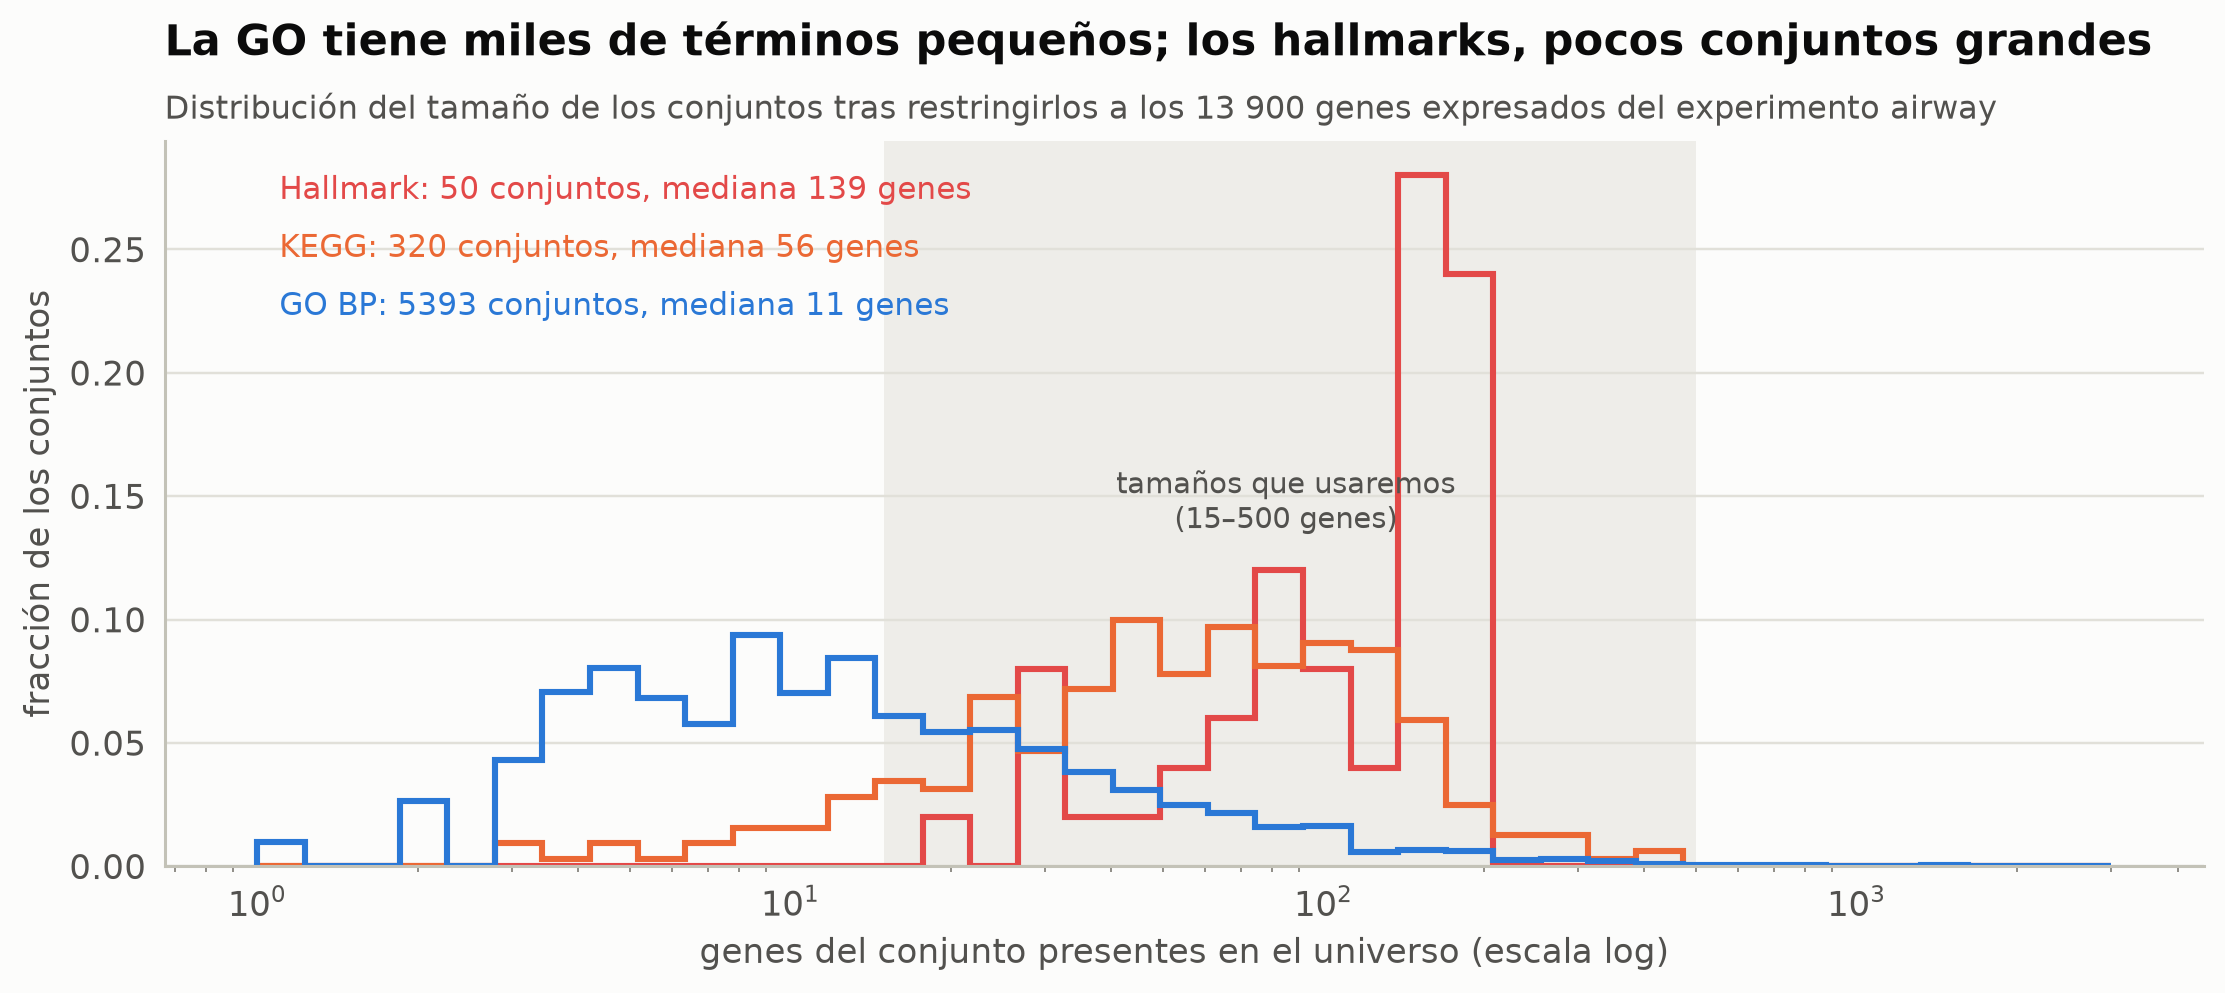

In [8]:
# ¿Cómo se reparten los tamaños de los conjuntos? (en el universo de genes expresados)
fig, ax = plt.subplots(figsize=(10, 4.4))
bins = np.logspace(0, np.log10(3000), 40)
for (short, sets), col in zip(libraries.items(), [ec.RED, ec.ORANGE, ec.BLUE]):
    sz = np.array([len(s & universe) for s in sets.values()])
    sz = sz[sz > 0]
    ax.hist(sz, bins=bins, histtype="step", linewidth=2, color=col, weights=np.full(len(sz), 1 / len(sz)))
ax.set_xscale("log")
ax.axvspan(15, 500, color=ec.GRID, alpha=0.5, zorder=0)
ymax = ax.get_ylim()[1]
ax.text(85, ymax * 0.55, "tamaños que usaremos\n(15–500 genes)", ha="center", va="top", fontsize=9.5, color=ec.INK_2)
for (short, sets), col, yy in zip(libraries.items(), [ec.RED, ec.ORANGE, ec.BLUE], [0.92, 0.84, 0.76]):
    sz = np.array([len(s & universe) for s in sets.values()]); sz = sz[sz > 0]
    ax.text(1.1, ymax * yy, f"{short}: {len(sz)} conjuntos, mediana {int(np.median(sz))} genes", color=col, fontsize=10, ha="left")
ax.set_xlabel("genes del conjunto presentes en el universo (escala log)"); ax.set_ylabel("fracción de los conjuntos")
ec.title(ax, "La GO tiene miles de términos pequeños; los hallmarks, pocos conjuntos grandes",
         "Distribución del tamaño de los conjuntos tras restringirlos a los 13 900 genes expresados del experimento airway")
plt.show()

> 🔎 **Qué observamos.** Tres filosofías distintas: los 50 *hallmarks* son conjuntos grandes y curados (≈150–200
> genes); KEGG, unos cientos de rutas de tamaño medio; la GO, miles de términos, muchos diminutos. Filtramos a
> conjuntos de **15 a 500 genes**: los muy pequeños no tienen potencia y dan resultados inestables, y los enormes
> («proceso metabólico») son tan generales que no dicen nada. Fíjese también en la columna de cobertura: entre un
> cuarto y un quinto de los genes de cada colección no está en nuestro universo, porque no se expresa en músculo liso
> o porque su símbolo cambió entre GENCODE v26 (2017) y las bibliotecas de 2020–2023. Por eso el libro insiste en
> **informar la versión de la anotación**.

> ✅ **Compruebe su comprensión.** ¿Por qué un término GO de 3000 genes casi nunca es informativo aunque salga
> «significativo»? *(Porque por la regla del camino verdadero es un ancestro muy general; su significación suele
> heredarse de algún descendiente específico, que es el que conviene leer.)*

---

## 4. Análisis de sobrerrepresentación (ORA)

La pregunta más simple es la del autobús: entre los $n$ genes de mi lista, **¿hay más genes del término $T$ de los
que esperaría por azar?** Supongamos que el universo tiene $N$ genes, de los cuales $K$ pertenecen a $T$, y que la
lista se hubiera formado eligiendo $n$ genes al azar y sin reemplazo. El número $X$ de genes de $T$ en la lista
seguiría una distribución hipergeométrica, y el valor $p$ de haber observado $k$ o más es

$$
p=\Pr(X\ge k)=\sum_{x=k}^{\min(n,K)}\frac{\binom{K}{x}\binom{N-K}{n-x}}{\binom{N}{n}},\qquad \mathbb{E}[X]=\frac{nK}{N}.
\tag{11-hiper}
$$

| Símbolo | Significado |
|---|---|
| $N$ | Tamaño del universo: genes **analizados** en el experimento |
| $K$ | Genes del universo anotados al término $T$ |
| $n$ | Genes de la lista (p. ej., significativos con FDR $<0{,}05$) |
| $k$ | Genes de la lista que pertenecen a $T$ |

Es exactamente la **prueba exacta de Fisher unilateral** sobre la tabla $2\times 2$ que cruza «en la lista / fuera
de ella» con «en el término / fuera de él». Se repite para cada uno de los miles de términos, y los valores $p$
resultantes se corrigen por **Benjamini-Hochberg** (lección 11.3).

### Un término real, a mano

Tomemos la lista de genes **inducidos** por la dexametasona ($q<0{,}05$ y $\log_2\mathrm{FC}>1$) y el *hallmark*
«TNF-alpha Signaling via NF-kB». Antes de calcular:

> 🤔 **Antes de ejecutar, prediga:** los glucocorticoides son antiinflamatorios. ¿Esperaría que la lista de genes
> **inducidos** estuviera enriquecida en la marca de señalización de TNF-α por NF-κB, o sólo la de reprimidos?

In [9]:
def ora(k, N, K, n):
    """p de sobrerrepresentación: P(X >= k), X hipergeométrica (código del libro)."""
    return stats.hypergeom.sf(k - 1, N, K, n)

sig_up = set(ranking.symbol[(ranking.padj < 0.05) & (ranking.log2FC > 1)])
sig_dn = set(ranking.symbol[(ranking.padj < 0.05) & (ranking.log2FC < -1)])
term = "TNF-alpha Signaling via NF-kB"
S = libraries["Hallmark"][term] & universe
N_u, K_t, n_l = len(universe), len(S), len(sig_up)
k_t = len(S & sig_up)
table = np.array([[k_t, n_l - k_t], [K_t - k_t, N_u - K_t - n_l + k_t]])
print(f"N = {N_u}, K = {K_t}, n = {n_l}, k = {k_t}")
print(f"E[X] = n·K/N = {n_l}·{K_t}/{N_u} = {n_l*K_t/N_u:.2f}   → observamos {k_t / (n_l*K_t/N_u):.1f} veces más")
print(pd.DataFrame(table, index=["en la lista", "fuera de la lista"], columns=["en el término", "fuera"]))
odds, p_fisher = stats.fisher_exact(table, alternative="greater")
print(f"\nrazón de momios = {stats.fisher_exact(table)[0]:.2f}")
print(f"p hipergeométrica = {ora(k_t, N_u, K_t, n_l):.3e}   ·   p Fisher unilateral = {p_fisher:.3e}  (idénticos)")
print("genes compartidos:", ", ".join(sorted(S & sig_up)))

N = 13922, K = 176, n = 455, k = 25
E[X] = n·K/N = 455·176/13922 = 5.75   → observamos 4.3 veces más
                   en el término  fuera
en la lista                   25    430
fuera de la lista            151  13316

razón de momios = 5.13
p hipergeométrica = 5.781e-10   ·   p Fisher unilateral = 5.781e-10  (idénticos)
genes compartidos: ATF3, CEBPD, CFLAR, DNAJB4, DUSP1, DUSP5, GADD45B, GCH1, GFPT2, IRS2, KLF6, KLF9, MAFF, MAP3K8, NAMPT, NFIL3, NR4A1, NR4A3, PDLIM5, PER1, PTX3, RCAN1, RHOB, SAT1, TSC22D1


> 🔎 **Qué observamos.** Esperábamos menos de 6 genes de la marca TNF-α/NF-κB entre los inducidos y encontramos 25:
> una razón de momios de ≈5 y $p\approx 6\times 10^{-10}$. Hipergeométrica y Fisher coinciden en todas las cifras,
> como anuncia el libro. ¿Contradice esto que la dexametasona sea antiinflamatoria? Mire los genes: *DUSP1*
> (MKP-1, que apaga las MAP quinasas p38 y JNK), *TSC22D1* (pariente de GILZ), *KLF6* y *KLF9*, *NFIL3*, *PER1*,
> *CEBPD*, *IRS2*… Muchos son genes de respuesta directa al receptor de glucocorticoides y, en buena parte,
> **frenos** de la respuesta inflamatoria (*NFKBIA*, IκBα, y *ZFP36*, tristetraprolina, también suben, aunque sin
> llegar a duplicarse). El conjunto *hallmark* reúne los genes que **cambian** cuando se activa
> NF-κB, e incluye tanto a los mediadores como a sus reguladores negativos. La dexametasona induce los frenos y
> reprime a los mediadores; como veremos, la misma marca aparece también entre los genes **reprimidos**. Un término
> enriquecido dice «aquí pasa algo con este proceso», no «este proceso se activa».

### ORA en las tres colecciones, con BH

Ahora repetimos la prueba para **todos** los conjuntos de 15–500 genes de cada colección, por separado para los genes
inducidos y los reprimidos, y corregimos con BH dentro de cada colección y dirección.

In [10]:
def ora_table(gene_list, sets, universe, min_size=15, max_size=500):
    """ORA de una lista contra una colección: una fila por conjunto, con p hipergeométrico y q de BH."""
    gene_list = set(gene_list) & universe
    N, n = len(universe), len(gene_list)
    rows = []
    for t, s in sets.items():
        S = s & universe
        K = len(S)
        if not (min_size <= K <= max_size):
            continue
        hits = S & gene_list
        rows.append((t, K, len(hits), n * K / N, ora(len(hits), N, K, n), ", ".join(sorted(hits))))
    out = pd.DataFrame(rows, columns=["term", "K", "k", "expected", "p", "genes"])
    out["fold"] = out.k / out.expected
    out["q"] = bh(out.p.values)
    return out.sort_values("p").reset_index(drop=True)

ora_res = {}
for short, sets in libraries.items():
    for direction, lst in [("up", sig_up), ("down", sig_dn)]:
        ora_res[(short, direction)] = ora_table(lst, sets, universe)
summary = pd.DataFrame([{"colección": s, "dirección": d, "conjuntos probados": len(r), "q < 0,05": int((r.q < 0.05).sum()),
                         "término más significativo": r.term[0][:55], "k/K": f"{r.k[0]}/{r.K[0]}", "q": f"{r.q[0]:.1e}"}
                        for (s, d), r in ora_res.items()])
summary

,colección,dirección,conjuntos probados,"q < 0,05",término más significativo,k/K,q
0,Hallmark,up,50,13,TNF-alpha Signaling via NF-kB,25/176,2.9e-08
1,Hallmark,down,50,5,p53 Pathway,20/180,7.5e-05
2,KEGG,up,290,3,Tyrosine metabolism,6/23,1.2e-02
3,KEGG,down,290,37,Cytokine-cytokine receptor interaction,22/134,8.9e-08
4,GO BP,up,2122,8,Negative Regulation Of Cell Motility (GO:2000146),16/106,6.8e-04
5,GO BP,down,2122,38,Axonogenesis (GO:0007409),20/138,3.9e-05


In [11]:
for key in [("Hallmark", "up"), ("Hallmark", "down"), ("KEGG", "down"), ("GO BP", "up")]:
    print(f"\n=== {key[0]} · genes {'inducidos' if key[1]=='up' else 'reprimidos'} ===")
    print(ora_res[key].head(6)[["term", "K", "k", "expected", "fold", "q"]].round({"expected": 2, "fold": 2})
          .to_string(index=False, formatters={"q": "{:.1e}".format}))


=== Hallmark · genes inducidos ===
                             term   K  k  expected  fold       q
    TNF-alpha Signaling via NF-kB 176 25      5.75  4.35 2.9e-08
Epithelial Mesenchymal Transition 194 18      6.34  2.84 1.7e-03
                          Hypoxia 172 14      5.62  2.49 2.1e-02
                KRAS Signaling Dn  87  9      2.84  3.17 2.1e-02
                KRAS Signaling Up 140 12      4.58  2.62 2.1e-02
                       Myogenesis 148 12      4.84  2.48 2.8e-02

=== Hallmark · genes reprimidos ===
                             term   K  k  expected  fold       q
                      p53 Pathway 180 20      5.82  3.44 7.5e-05
    TNF-alpha Signaling via NF-kB 176 17      5.69  2.99 9.8e-04
Epithelial Mesenchymal Transition 194 18      6.27  2.87 9.8e-04
            Inflammatory Response 134 13      4.33  3.00 5.0e-03
                KRAS Signaling Up 140 13      4.53  2.87 6.1e-03
                        Apoptosis 141 11      4.56  2.41 5.0e-02

=== KEGG · genes

La figura interactiva siguiente resume los 12 términos más significativos de cada colección y dirección. El eje
horizontal es el **enriquecimiento** $k/\mathbb{E}[X]$; el tamaño del punto, $k$; el color, $-\log_{10} q$. Pase el
ratón para leer la tabla $2\times2$ implícita y **los genes que sostienen cada término**, que es lo primero que hay
que mirar.

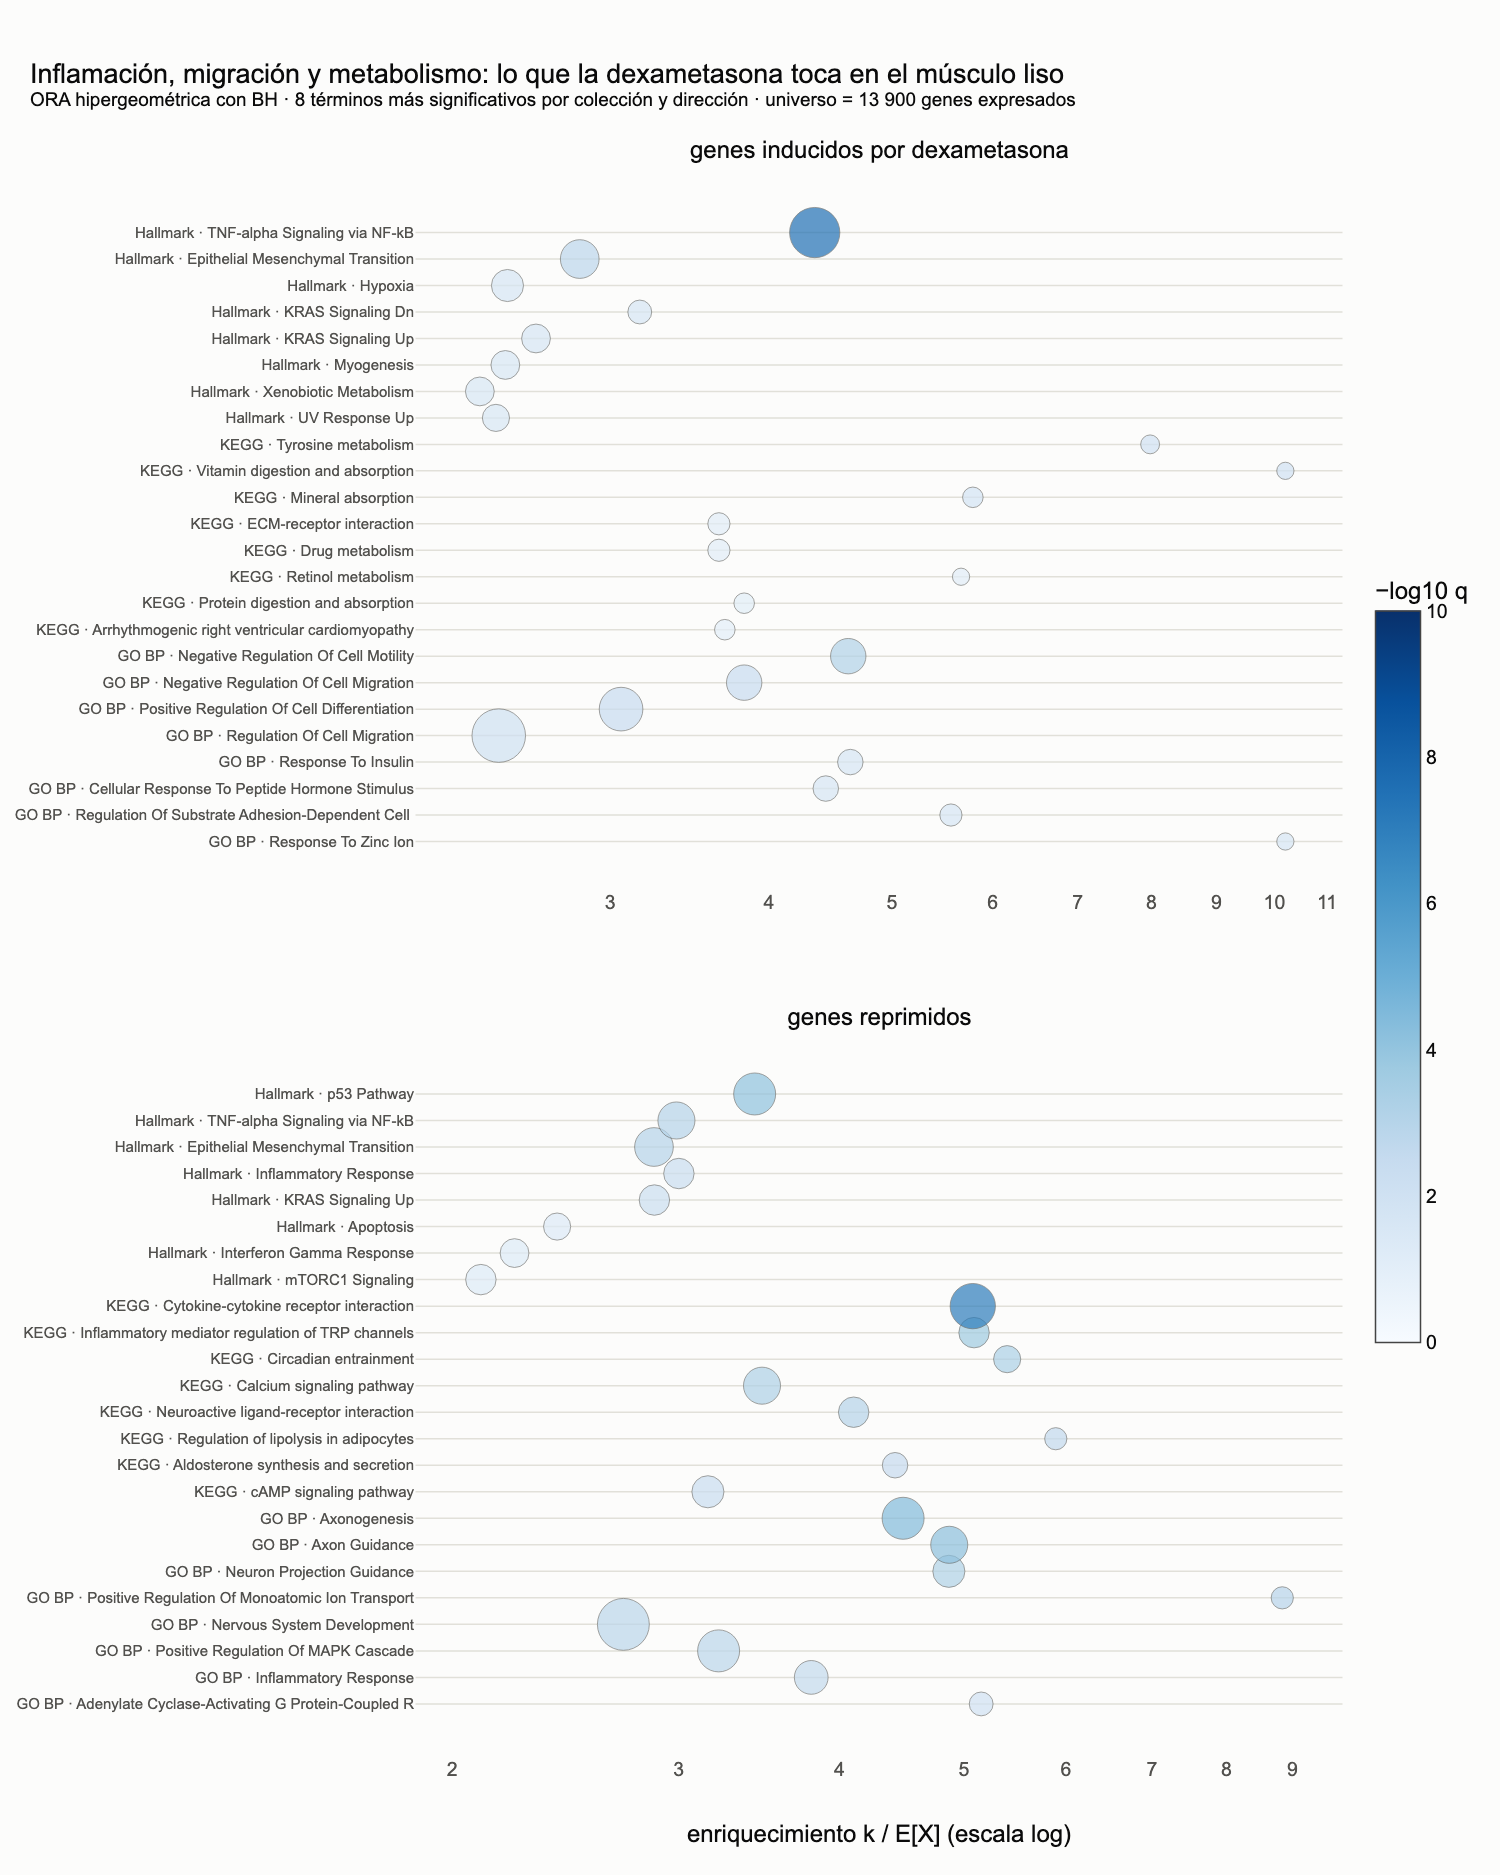

In [12]:
dot = []
for (short, direction), r in ora_res.items():
    top = r.head(8).copy()
    top["colección"] = short; top["dirección"] = "inducidos" if direction == "up" else "reprimidos"
    dot.append(top)
dot = pd.concat(dot)
dot["mlog10q"] = -np.log10(dot.q)
dot["label"] = dot.term.str.replace(r" \(GO:\d+\)", "", regex=True).str.slice(0, 48)
dot["fila"] = dot["colección"] + " · " + dot["label"]
dot["genes_hover"] = dot.genes.str.slice(0, 160) + np.where(dot.genes.str.len() > 160, "…", "")
fig = make_subplots(rows=2, cols=1, subplot_titles=["genes inducidos por dexametasona", "genes reprimidos"],
                    vertical_spacing=0.09)
for j, dirn in enumerate(["inducidos", "reprimidos"]):
    sub = dot[dot["dirección"] == dirn].iloc[::-1]
    fig.add_trace(go.Scatter(
        x=sub.fold, y=sub.fila, mode="markers",
        marker=dict(size=6 + 1.1 * sub.k, color=sub.mlog10q, colorscale="Blues", cmin=0, cmax=10,
                    line=dict(color=ec.INK_2, width=0.5),
                    colorbar=dict(title="−log10 q", len=0.5) if j == 1 else None, showscale=(j == 1)),
        customdata=np.stack([sub.term, sub.k, sub.K, sub.expected, sub.q, sub.genes_hover], 1),
        hovertemplate="<b>%{customdata[0]}</b><br>k = %{customdata[1]} de K = %{customdata[2]} genes del término"
                      "<br>esperados por azar: %{customdata[3]:.1f}  →  ×%{x:.1f}<br>q (BH) = %{customdata[4]:.1e}"
                      "<br><i>genes:</i> %{customdata[5]}<extra></extra>", showlegend=False), j + 1, 1)
fig.update_xaxes(type="log")
fig.update_xaxes(title_text="enriquecimiento k / E[X] (escala log)", row=2, col=1)
fig.update_yaxes(tickfont=dict(size=10), automargin=True)
fig.update_layout(title="Inflamación, migración y metabolismo: lo que la dexametasona toca en el músculo liso"
                        "<br><sup>ORA hipergeométrica con BH · 8 términos más significativos por colección y dirección · "
                        "universo = 13 900 genes expresados</sup>",
                  height=1250, margin=dict(t=110, l=10, r=10))
fig.show()

> 🔎 **Qué observamos.** Los resultados cuentan una historia coherente con la farmacología de los
> glucocorticoides, que conviene leer con prudencia («compatible con», no «demuestra»):
>
> * **Reprimidos:** la ruta de KEGG de **interacción citocina–receptor de citocina** y los términos GO de respuesta
>   inflamatoria: los glucocorticoides reducen la producción de citocinas y quimiocinas, el núcleo de su efecto
>   antiinflamatorio. También aparecen términos de **guía axonal** y de señalización por calcio y AMPc: genes de
>   adhesión y de señalización que, en músculo liso, regulan la migración y la contracción (el nombre «axonal» es
>   histórico: esos genes funcionan en muchos tejidos).
> * **Inducidos:** la marca TNF-α/NF-κB (sus frenos, como vimos), **transición epitelio-mesénquima** y **regulación
>   negativa de la motilidad celular** (el músculo liso de vía aérea migra y remodela la pared en el asma), y
>   **respuesta a la insulina** y a hormonas peptídicas y **metabolismo de la tirosina y minerales**, un eco de los
>   efectos metabólicos conocidos de los glucocorticoides. La **respuesta al ion zinc** la explican las
>   **metalotioneínas** (*MT1X*, *MT2A*…), inducidas por glucocorticoides desde hace décadas.
> * La marca *hallmark* **p53 Pathway** entre los reprimidos se apoya en genes de detención del ciclo y apoptosis;
>   antes de interpretarla habría que mirar esos genes uno a uno.

> ✅ **Compruebe su comprensión.** ¿Por qué hacemos dos ORA separados (inducidos y reprimidos) y no uno con toda
> la lista? *(Porque un proceso puede activarse en unos genes y frenarse en otros; mezclarlos diluye cada señal y
> oculta la dirección. Con la lista completa, TNF-α/NF-κB sale aún más significativo, pero ya no sabríamos que
> combina frenos inducidos con mediadores reprimidos.)*

---

## 5. El universo no es el genoma

El universo debe ser el conjunto de genes que **tuvieron alguna oportunidad de aparecer en la lista**: los que se
analizaron y pasaron el filtrado. Muchas herramientas web piden sólo la lista y usan por defecto **todo el genoma**
(o todos los genes de la colección). ¿Qué cambia?

Piense de nuevo en el autobús: si calcula la proporción de pelirrojos con **todo el país** en lugar de la ciudad por
donde pasa el autobús, y resulta que la ciudad tiene más pelirrojos que el país, verá «enriquecimiento» donde sólo
hay geografía. En el tejido estudiado se expresan ciertos genes (en músculo liso: matriz extracelular, contracción,
adhesión) y no otros (neuronas, hígado, linfocitos). Los genes no expresados **nunca** podían entrar en la lista;
si los contamos en el universo, los términos de genes «del tejido» parecen enriquecidos por el mero hecho de
expresarse.

Al pasar al genoma, $N$ crece para todos los términos, pero $K$ crece **según cuántos genes del término no se
expresan**. Si un término tiene casi todos sus genes expresados en el tejido, su $K$ apenas cambia mientras $N$ sube un
28 %: su número esperado $nK/N$ **baja** y el mismo $k$ parece más extraordinario.

> 🤔 **Antes de ejecutar, prediga:** ¿qué términos ganarán significación con el universo equivocado: los de genes que
> se expresan en casi todos los tejidos (señalización general, citoesqueleto) o los de genes específicos de neuronas o
> linfocitos?

universo correcto (expresados): 13922 genes · 'genoma' (todos los codificantes): 17866 genes
términos con q < 0,05 · universo correcto: 57 · genoma: 46
16 términos pierden la significación con el universo equivocado

5 términos 'significativos' sólo con el universo equivocado; los primeros:
                                                                      k    K  K_genome      q  q_genome
term                                                                                                   
Regulation Of Canonical Wnt Signaling Pathway (GO:0060828)           21  166       190  0.069     0.043
Ras Protein Signal Transduction (GO:0007265)                         17  121       140  0.063     0.045
Positive Regulation Of Canonical Wnt Signaling Pathway (GO:0090263)  12   72        81  0.063     0.045
Cellular Response To Peptide Hormone Stimulus (GO:0071375)           12   69        82  0.053     0.048
Ephrin Receptor Signaling Pathway (GO:0048013)                        8   35        

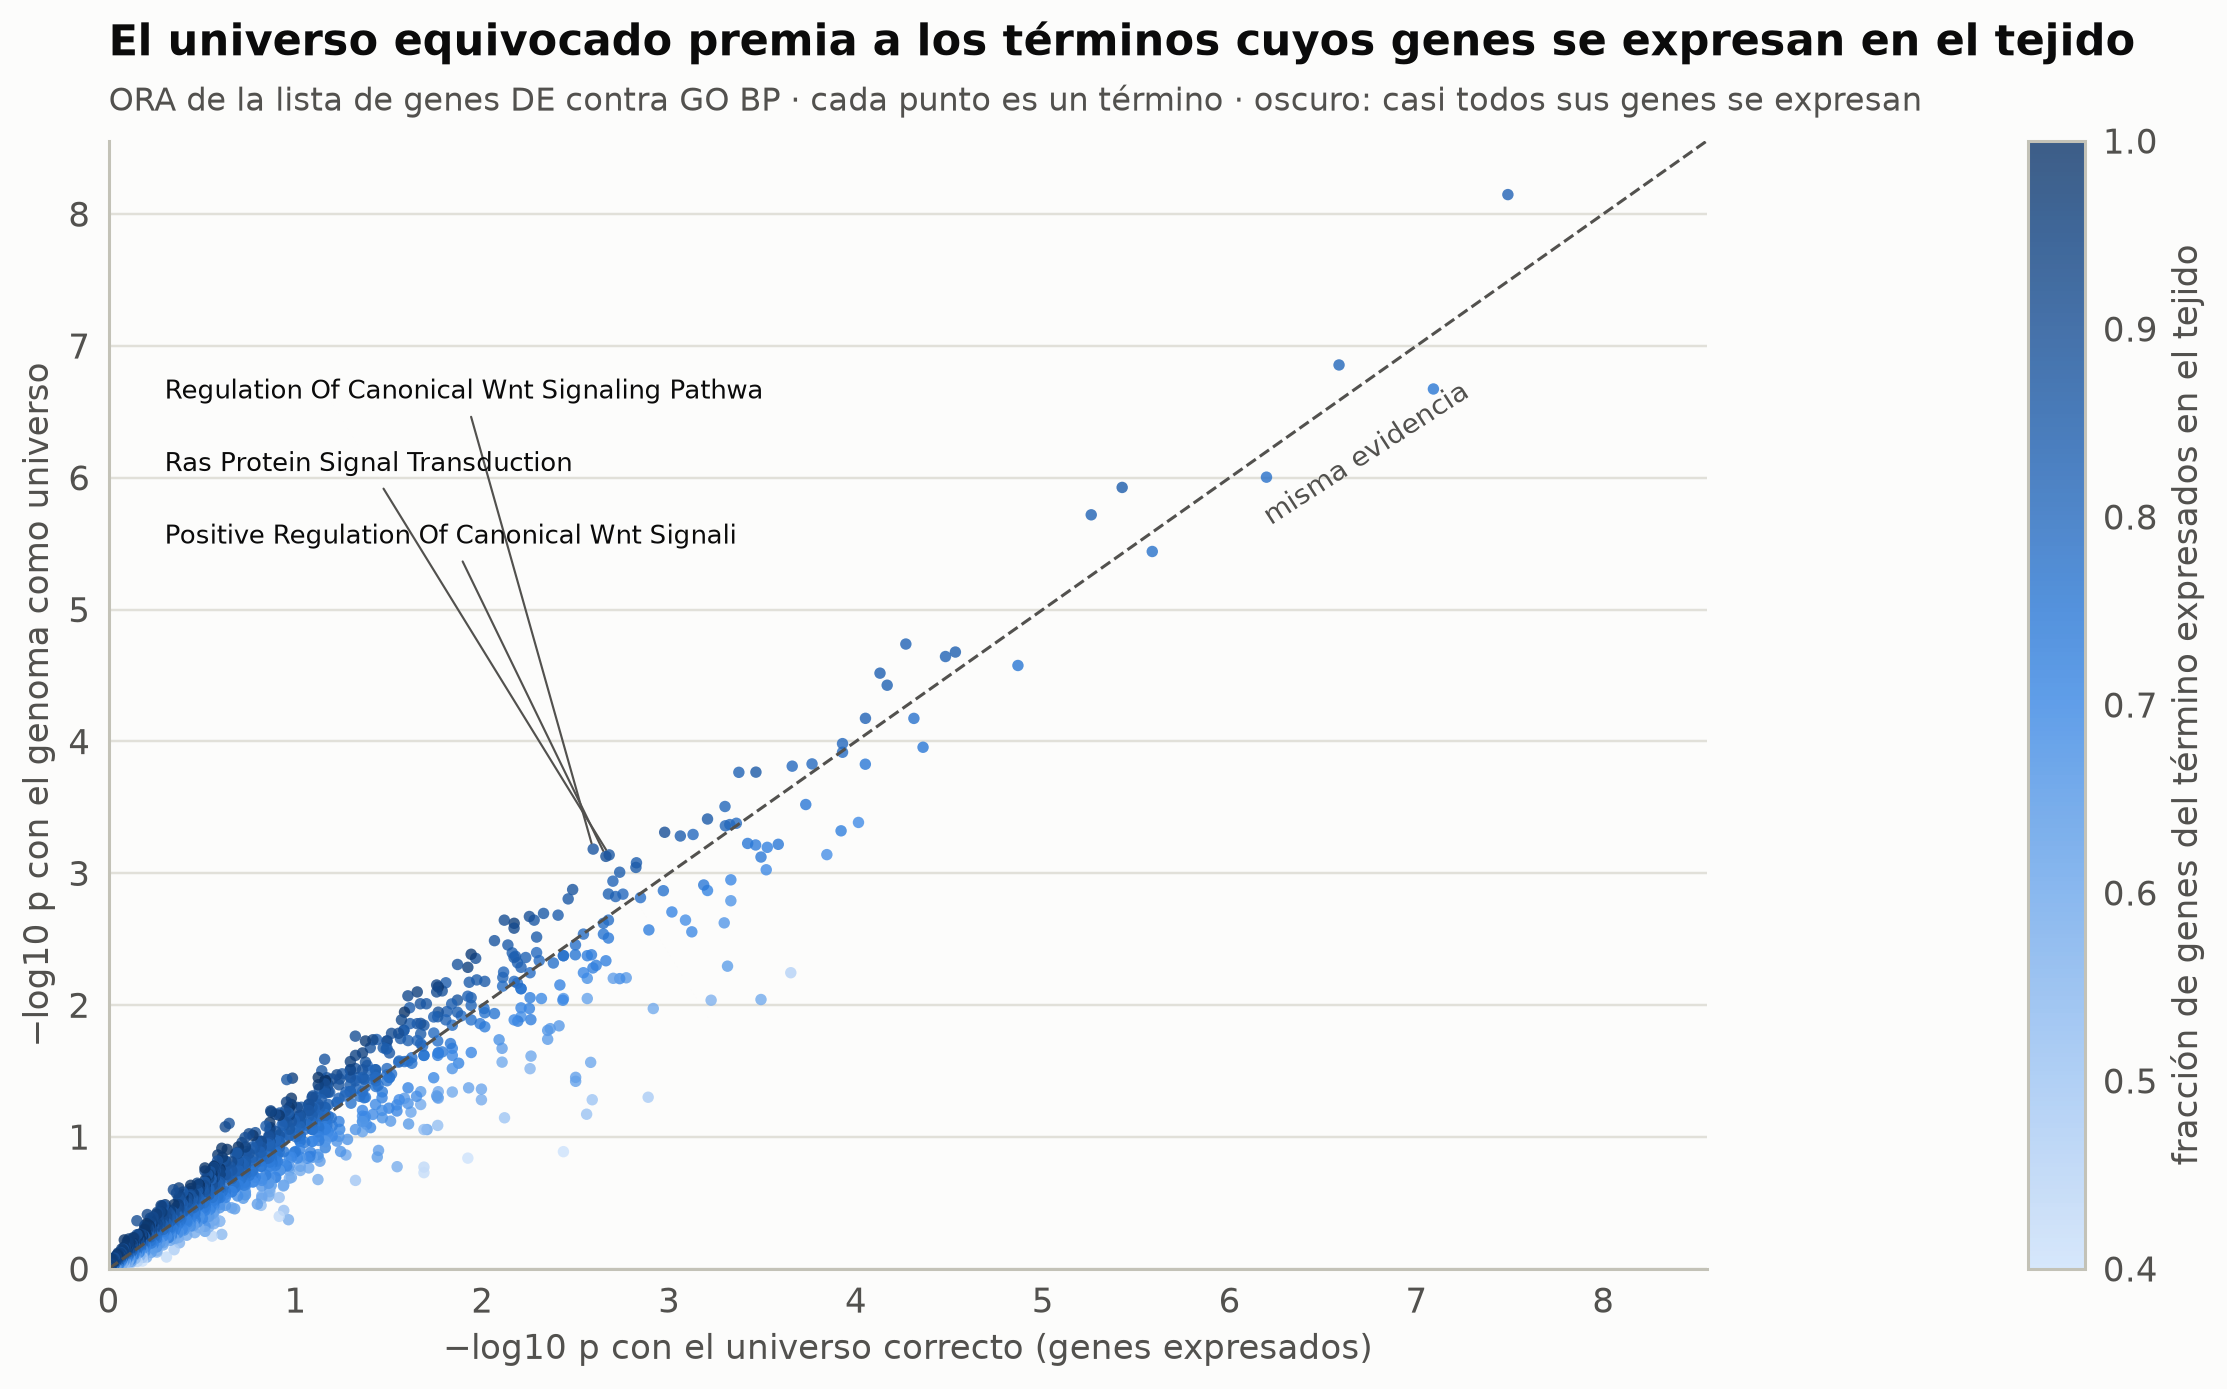

In [13]:
genome = set(counts.symbol[counts.gene_type == "protein_coding"].dropna())
print(f"universo correcto (expresados): {len(universe)} genes · 'genoma' (todos los codificantes): {len(genome)} genes")
go_sets = libraries["GO BP"]
lst = sig_up | sig_dn
r_ok = ora_table(lst, go_sets, universe).set_index("term")
r_gen = ora_table(lst, go_sets, genome).set_index("term")
cmp_u = r_ok[["p", "q", "k", "K"]].join(r_gen[["p", "q", "K"]], rsuffix="_genome", how="inner")
cmp_u["frac_expr"] = cmp_u.K / cmp_u.K_genome          # fracción de los genes del término que se expresan
print(f"términos con q < 0,05 · universo correcto: {(cmp_u.q < 0.05).sum()} · genoma: {(cmp_u.q_genome < 0.05).sum()}")
new = cmp_u[(cmp_u.q_genome < 0.05) & (cmp_u.q >= 0.05)].sort_values("p_genome")
lost = cmp_u[(cmp_u.q < 0.05) & (cmp_u.q_genome >= 0.05)]
print(f"{len(lost)} términos pierden la significación con el universo equivocado")
print(f"\n{len(new)} términos 'significativos' sólo con el universo equivocado; los primeros:")
print(new.head(8)[["k", "K", "K_genome", "q", "q_genome"]].round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 6.2))
xx, yy = -np.log10(cmp_u.p), -np.log10(cmp_u.p_genome)
sc = ax.scatter(xx, yy, c=cmp_u.frac_expr, cmap=ec.CMAP_SEQ, s=14, alpha=0.8, vmin=0.4, vmax=1)
lim = max(xx.max(), yy.max()) * 1.05
ax.plot([0, lim], [0, lim], color=ec.INK_2, lw=1, ls="--")
ax.text(lim * 0.72, lim * 0.66, "misma evidencia", color=ec.INK_2, fontsize=9, rotation=33)
for i_, t in enumerate(new.head(3).index):
    ax.annotate(t.split(" (GO")[0][:44], xy=(-np.log10(cmp_u.p[t]), -np.log10(cmp_u.p_genome[t])),
                xytext=(0.3, 6.6 - 0.55 * i_), fontsize=8.5,
                arrowprops=dict(arrowstyle="-", color=ec.INK_2, lw=0.7))
cb = plt.colorbar(sc, ax=ax, pad=0.02); cb.set_label("fracción de genes del término expresados en el tejido")
ax.set_xlabel("−log10 p con el universo correcto (genes expresados)")
ax.set_ylabel("−log10 p con el genoma como universo")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ec.title(ax, "El universo equivocado premia a los términos cuyos genes se expresan en el tejido",
         "ORA de la lista de genes DE contra GO BP · cada punto es un término · oscuro: casi todos sus genes se expresan")
plt.show()

> 🔎 **Qué observamos.** El universo equivocado no desplaza todos los puntos por igual: los **reordena**. Los
> términos oscuros (casi todos sus genes se expresan en músculo liso: señalización Wnt y Ras, efrinas) quedan por
> **encima** de la diagonal y algunos cruzan el umbral de significación sin que la dexametasona tenga nada que ver;
> los claros (muchos genes de neuronas, linfocitos o hígado que aquí no se expresan) quedan por **debajo** y algunos
> hallazgos reales se pierden. En este experimento el efecto es moderado porque el filtrado sólo excluyó un 22 % de
> los genes codificantes; en tejidos más especializados, o si el «genoma» incluye genes no codificantes, la
> distorsión es mucho mayor. **Regla práctica:** el universo es la tabla de resultados completa de la
> expresión diferencial tras el filtrado (en DESeq2, los genes con `padj` no nulo), no el genoma.

---

## 6. El sesgo de longitud

El modelo hipergeométrico supone que **todos los genes tenían la misma probabilidad de entrar en la lista**: el
autobús recoge gente al azar. En RNA-seq no es así. Young et al. (2010) observaron que, **para un mismo cambio de
expresión**, un gen largo produce más lecturas (se fragmenta en más trozos) y, por tanto, su prueba tiene más
**potencia** estadística: la probabilidad de ser declarado significativo crece con la longitud. Los términos GO que
agrupan genes largos (adhesión, matriz extracelular, desarrollo neuronal) aparecen entonces enriquecidos sin que haya
nada biológico detrás.

Su método, **goseq**, hace dos cosas:

1. Estima una **función de probabilidad ponderada** (PWF): la probabilidad de que un gen sea significativo en
   función de su longitud $\ell$, $\pi(\ell)=\Pr(\text{DE}\mid \ell)$, ajustando una curva monótona. Nosotros usamos
   la versión más simple que dibuja el libro, una **logística en $\log\ell$**:
   $\operatorname{logit}\pi(\ell) = \beta_0 + \beta_1 \log \ell$.
2. Sustituye la hipergeométrica por la distribución que resulta de **muestrear genes con esos pesos**: la
   hipergeométrica no central de **Wallenius**, o su aproximación por **remuestreo**.

### 6.1 La PWF en la simulación del libro

El libro simula un experimento de 3 contra 3 muestras con 9992 genes en el que el **10 %** de los genes recibe un
cambio real **con independencia de su longitud**; tras el análisis tipo DESeq2 quedan 404 genes con $q<0{,}1$.
Reproducimos exactamente esa simulación a partir de una tabla pequeña del repositorio (longitud, gen
significativo, cambio verdadero y estadístico de Wald de cada gen) y del estado del generador aleatorio del script
del libro justo antes de esta sección.

In [14]:
sim = read_table("114_libro_sim.tsv.gz")
book_rng = np.random.default_rng()
book_rng.bit_generator.state = json.loads(course_bytes("114_libro_rng.json"))["rng_11_4"]
glen_g = sim.length.to_numpy(); sig_b = sim.sig_q01.to_numpy().astype(bool)
de_b = sim.de_true.to_numpy().astype(bool); lfc_b = sim.lfc_true.to_numpy(); wald_b = sim.wald.to_numpy()
G = len(sim)
print(f"genes: {G} · con cambio verdadero: {de_b.sum()} · significativos (q<0,1): {sig_b.sum()}")

def fit_pwf(length, is_de):
    """PWF logística en log-longitud por máxima verosimilitud: devuelve (beta0, beta1)."""
    ll = np.log(length)
    def nll(b):
        z = b[0] + b[1] * ll
        return -np.sum(is_de * z - np.log1p(np.exp(z)))
    return optimize.minimize(nll, [-5, 0.5]).x

def binned(length, is_de, nbins=20):
    """Proporción de genes DE en bins de igual tamaño por longitud (mediana de cada bin)."""
    edges = np.quantile(length, np.linspace(0, 1, nbins + 1))
    b = np.clip(np.digitize(length, edges) - 1, 0, nbins - 1)
    return (np.array([np.median(length[b == j]) for j in range(nbins)]),
            np.array([is_de[b == j].mean() for j in range(nbins)]))

cen_b, prop_b = binned(glen_g, sig_b)
beta_b = fit_pwf(glen_g, sig_b)
print(f"proporción DE: bin más corto = {prop_b[0]:.3f} · bin más largo = {prop_b[-1]:.3f}")
print(f"pendiente logit por log-longitud β1 = {beta_b[1]:.2f}")
# ¿y los cambios verdaderos? (sólo existe en una simulación)
_, prop_true = binned(glen_g, de_b)
print(f"fracción con cambio VERDADERO por bin: media {prop_true.mean():.3f}, entre {prop_true.min():.3f} y "
      f"{prop_true.max():.3f} (sin tendencia: sólo ruido de muestreo)")

genes: 9992 · con cambio verdadero: 946 · significativos (q<0,1): 404
proporción DE: bin más corto = 0.020 · bin más largo = 0.090
pendiente logit por log-longitud β1 = 0.40
fracción con cambio VERDADERO por bin: media 0.095, entre 0.068 y 0.126 (sin tendencia: sólo ruido de muestreo)


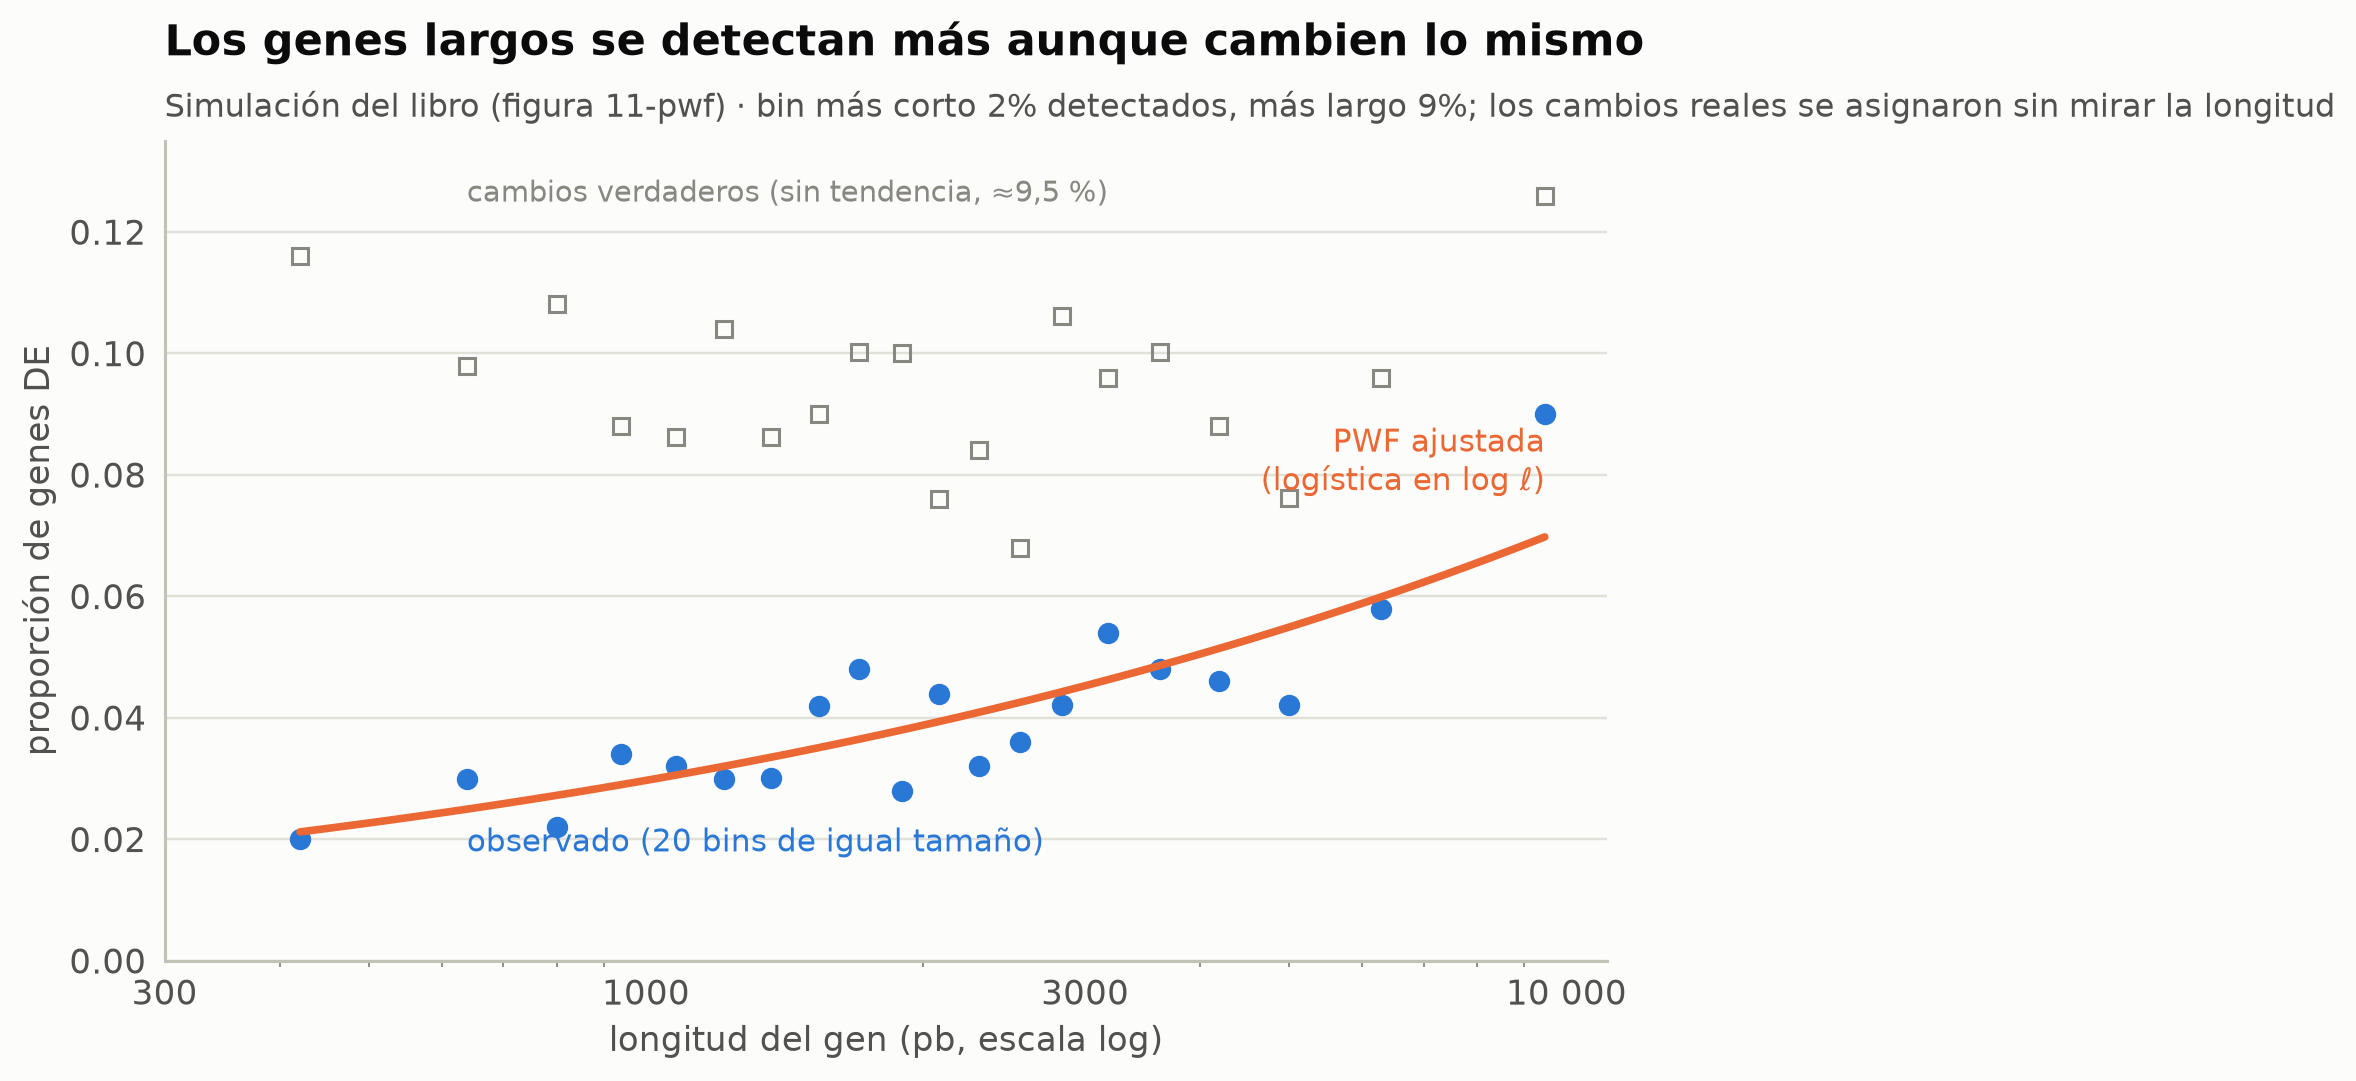

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.8))
xl = np.exp(np.linspace(np.log(cen_b[0]), np.log(cen_b[-1]), 80))
ax.plot(cen_b, prop_true, "s", color=ec.MUTED, ms=5, mfc="none")
ax.plot(cen_b, prop_b, "o", color=ec.BLUE, ms=6)
ax.plot(xl, special.expit(beta_b[0] + beta_b[1] * np.log(xl)), color=ec.ORANGE, lw=2.5)
ax.set_xscale("log"); ax.set_ylim(0, 0.135)
ax.set_xticks([300, 1000, 3000, 10000]); ax.set_xticklabels(["300", "1000", "3000", "10 000"])
ax.text(cen_b[1], prop_b[1] - 0.012, "observado (20 bins de igual tamaño)", color=ec.BLUE, fontsize=10)
ax.text(xl[-1], special.expit(beta_b[0] + beta_b[1] * np.log(xl[-1])) + 0.006, "PWF ajustada\n(logística en log ℓ)",
        color=ec.ORANGE, fontsize=10, ha="right", va="bottom")
ax.text(cen_b[1], 0.125, "cambios verdaderos (sin tendencia, ≈9,5 %)", color=ec.MUTED, fontsize=9.5)
ax.set_xlabel("longitud del gen (pb, escala log)"); ax.set_ylabel("proporción de genes DE")
ec.title(ax, "Los genes largos se detectan más aunque cambien lo mismo",
         f"Simulación del libro (figura 11-pwf) · bin más corto {prop_b[0]:.0%} detectados, más largo {prop_b[-1]:.0%}; "
         "los cambios reales se asignaron sin mirar la longitud")
plt.show()

> 🔎 **Qué observamos.** Los cambios verdaderos (cuadrados grises) están repartidos por igual en todas las
> longitudes, pero los **detectados** (azul) suben del 2 % en los genes más cortos al 9 % en los más largos. Esa
> diferencia no es biología, es **potencia**: un gen largo acumula más lecturas, su estimación del cambio es más
> precisa y su prueba lo declara significativo con más facilidad. La curva naranja es la PWF de goseq.

### 6.2 Ejemplo del libro: «Un enriquecimiento espurio»

En la simulación creamos un «término GO» de $K=150$ genes elegidos entre el **20 % más largo**, con 14 genes con
cambio real, **tantos como los que corresponden por azar** ($150\times 0{,}095\approx 14{,}2$): no hay
enriquecimiento biológico. La lista tiene $n=404$ genes significativos entre $N=9992$.

> 🤔 **Antes de ejecutar, prediga:** ¿la prueba hipergeométrica declarará enriquecido este término «sin biología»?

In [16]:
# Construcción del término (idéntica al script del libro, con el mismo generador)
long_rank = stats.rankdata(glen_g) / G
cand = np.where(long_rank > 0.8)[0]
nde_t = int(round(150 * de_b.mean()))
term_b = np.concatenate([book_rng.choice(cand[de_b[cand]], nde_t, replace=False),
                         book_rng.choice(cand[~de_b[cand]], 150 - nde_t, replace=False)])
N_b, K_b, n_b = G, len(term_b), int(sig_b.sum())
k_b = int(sig_b[term_b].sum())
print(f"N = {N_b}, K = {K_b}, n = {n_b}, k = {k_b} · cambios verdaderos en el término = {de_b[term_b].sum()}")
print(f"E[X] = {n_b}×{K_b}/{N_b} = {n_b*K_b/N_b:.2f}")
tab_b = np.array([[k_b, n_b - k_b], [K_b - k_b, N_b - K_b - n_b + k_b]])
print(pd.DataFrame(tab_b, index=["en la lista", "fuera de la lista"], columns=["en el término", "fuera"]))
print(f"razón de momios = {stats.fisher_exact(tab_b)[0]:.2f} · p hipergeométrico = {ora(k_b, N_b, K_b, n_b):.4f}"
      f" · p Fisher = {stats.fisher_exact(tab_b, 'greater')[1]:.4f}")

N = 9992, K = 150, n = 404, k = 12 · cambios verdaderos en el término = 14
E[X] = 404×150/9992 = 6.06
                   en el término  fuera
en la lista                   12    392
fuera de la lista            138   9450
razón de momios = 2.10 · p hipergeométrico = 0.0184 · p Fisher = 0.0184


La prueba dice $p=0{,}018$: el término «parece» enriquecido. Ahora aplicamos la idea de goseq: generamos listas
nulas **muestreando $n=404$ genes con probabilidad proporcional a la PWF** (sin reemplazo) y contamos cuántos genes
del término caen en cada una. El valor $p$ por remuestreo es

$$
p_{\text{rem}} = \frac{\#\{b : X^{(b)} \ge k\} + 1}{B + 1},
$$

con $B=4000$ listas nulas; el $+1$ evita declarar $p=0$ con un número finito de remuestreos.

In [17]:
pwf_b = special.expit(beta_b[0] + beta_b[1] * np.log(glen_g))
wts_b = pwf_b / pwf_b.sum()
t_ = time.time()
null_w = np.array([np.isin(book_rng.choice(G, n_b, replace=False, p=wts_b), term_b).sum() for _ in range(4000)])
p_w = (np.sum(null_w >= k_b) + 1) / (len(null_w) + 1)
print(f"media nula ponderada = {null_w.mean():.2f} (hipergeométrica: {n_b*K_b/N_b:.2f})")
print(f"p por remuestreo ponderado = {p_w:.3f}  (hipergeométrico: {ora(k_b, N_b, K_b, n_b):.3f})"
      f"   [{time.time()-t_:.1f} s]")

media nula ponderada = 8.79 (hipergeométrica: 6.06)
p por remuestreo ponderado = 0.168  (hipergeométrico: 0.018)   [0.7 s]


> 🔎 **Qué observamos.** Cifras idénticas a las del libro: con muestreo ponderado el número esperado de genes del
> término en la lista sube de 6,06 a **8,79**, y el mismo $k=12$ deja de ser llamativo ($p=0{,}168$). El
> «enriquecimiento» era sólo el reflejo de que los genes largos se detectan mejor. La animación siguiente muestra
> cómo se va construyendo la distribución nula ponderada, remuestreo a remuestreo, junto a la hipergeométrica.

![La distribución nula ponderada por la PWF (naranja) se construye remuestreo a remuestreo y queda desplazada a la derecha de la hipergeométrica (azul): el valor observado k = 12 deja de estar en la cola.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-11-rnaseq/11.4_nulo_ponderado.gif)

*La distribución nula ponderada por la PWF (naranja) se construye remuestreo a remuestreo y queda desplazada a la derecha de la hipergeométrica (azul): el valor observado k = 12 deja de estar en la cola.*

In [18]:
kx = np.arange(0, 27)
pmf_h = stats.hypergeom.pmf(kx, N_b, K_b, n_b)
checkpoints = np.unique(np.round(np.geomspace(20, len(null_w), 40)).astype(int))
fig, ax = plt.subplots(figsize=(10, 4.8))

def update(i):
    ax.clear()
    B = checkpoints[i]
    h = np.bincount(null_w[:B], minlength=len(kx))[:len(kx)] / B
    ax.bar(kx - 0.2, pmf_h, width=0.4, color=ec.BLUE, alpha=0.85, label="hipergeométrica (muestreo uniforme)")
    ax.bar(kx + 0.2, h, width=0.4, color=ec.ORANGE, alpha=0.9, label="remuestreo ponderado por la PWF")
    ax.axvline(k_b, color=ec.RED, ls="--", lw=2)
    pB = (np.sum(null_w[:B] >= k_b) + 1) / (B + 1)
    ax.text(k_b + 0.3, 0.172, f"observado: k = {k_b}", color=ec.RED, fontsize=10)
    ax.text(25.5, 0.13, f"remuestreos: {B}\np hipergeométrico = {ora(k_b, N_b, K_b, n_b):.3f}\np ponderado = {pB:.3f}",
            ha="right", va="top", fontsize=10, color=ec.INK_2)
    ax.set_xlim(-0.8, 26); ax.set_ylim(0, 0.19)
    ax.set_xlabel("genes del término en la lista (X)"); ax.set_ylabel("probabilidad")
    ax.legend(loc="upper left", frameon=False, bbox_to_anchor=(0, 0.98))
    ec.title(ax, "Con los pesos de la PWF, 12 genes del término ya no sorprenden",
             "Término de 150 genes largos, lista de 404 genes (ejemplo «Un enriquecimiento espurio»)")

ec.animate(fig, update, frames=len(checkpoints), interval=160, name="11.4_nulo_ponderado")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

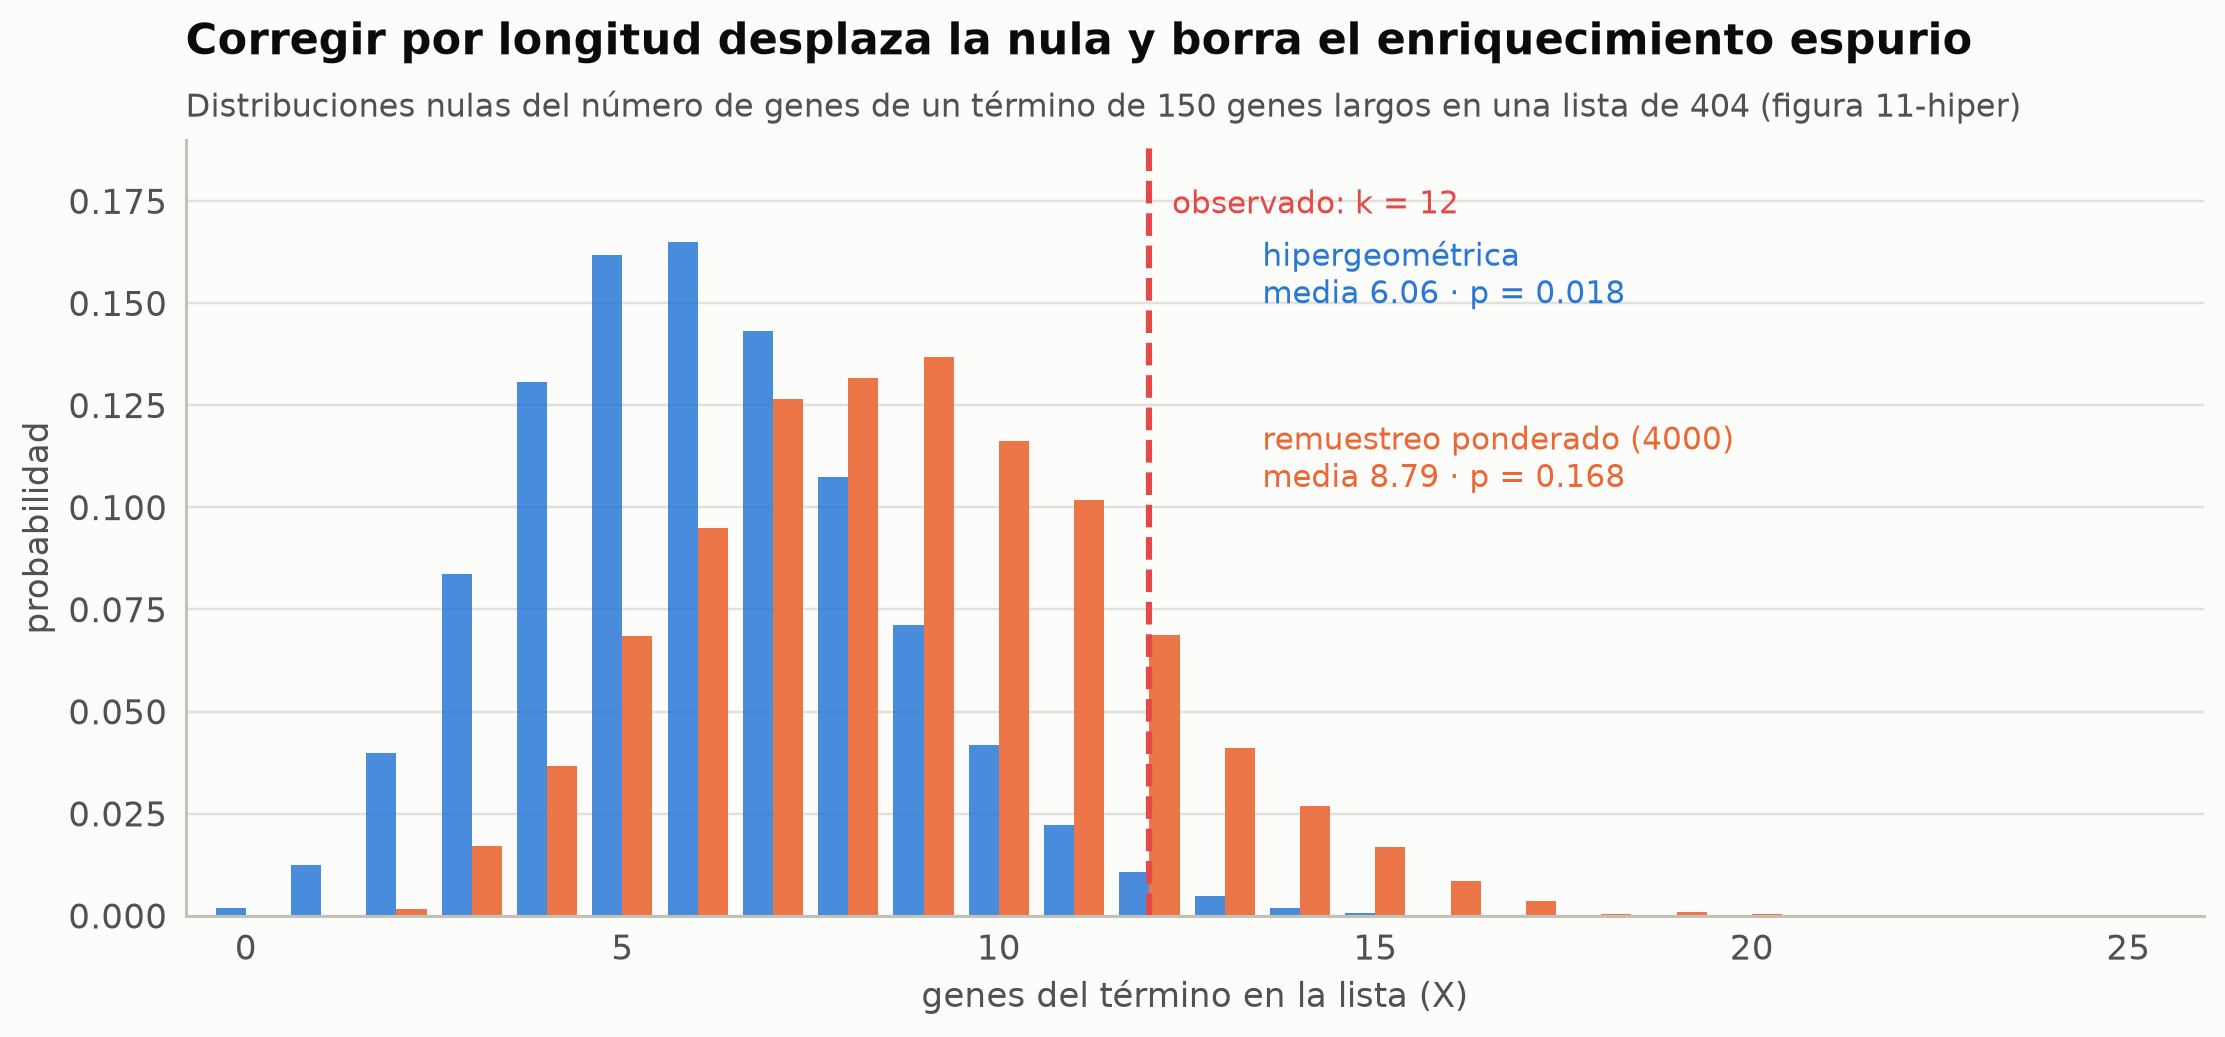

In [19]:
# Figura estática final (figura 11-hiper del libro)
fig, ax = plt.subplots(figsize=(10, 4.6))
h_final = np.bincount(null_w, minlength=len(kx))[:len(kx)] / len(null_w)
ax.bar(kx - 0.2, pmf_h, width=0.4, color=ec.BLUE, alpha=0.85)
ax.bar(kx + 0.2, h_final, width=0.4, color=ec.ORANGE, alpha=0.9)
ax.axvline(k_b, color=ec.RED, ls="--", lw=2)
ax.text(k_b + 0.3, 0.172, f"observado: k = {k_b}", color=ec.RED, fontsize=10)
ax.text(13.5, 0.150, f"hipergeométrica\nmedia {n_b*K_b/N_b:.2f} · p = {ora(k_b, N_b, K_b, n_b):.3f}", color=ec.BLUE, fontsize=10)
ax.text(13.5, 0.105, f"remuestreo ponderado (4000)\nmedia {null_w.mean():.2f} · p = {p_w:.3f}", color=ec.ORANGE, fontsize=10)
ax.set_xlim(-0.8, 26); ax.set_ylim(0, 0.19)
ax.set_xlabel("genes del término en la lista (X)"); ax.set_ylabel("probabilidad")
ec.title(ax, "Corregir por longitud desplaza la nula y borra el enriquecimiento espurio",
         "Distribuciones nulas del número de genes de un término de 150 genes largos en una lista de 404 (figura 11-hiper)")
plt.show()

### 6.3 ¿Hay sesgo de longitud en el experimento *airway*?

Ahora con datos reales. Ajustamos la PWF a dos listas: (a) todos los genes con $q<0{,}05$ (4400 genes) y (b) la
lista estricta que usamos en el ORA ($q<0{,}05$ y $|\log_2\mathrm{FC}|>1$).

> 🤔 **Antes de ejecutar, prediga:** ¿en cuál de las dos listas será más fuerte el sesgo de longitud? Piense en qué
> genes son los que «entran por potencia».

              q < 0,05: β1 = 0.198 · proporción DE 0.228 → 0.330
  q < 0,05 y |LFC| > 1: β1 = 0.021 · proporción DE 0.062 → 0.066


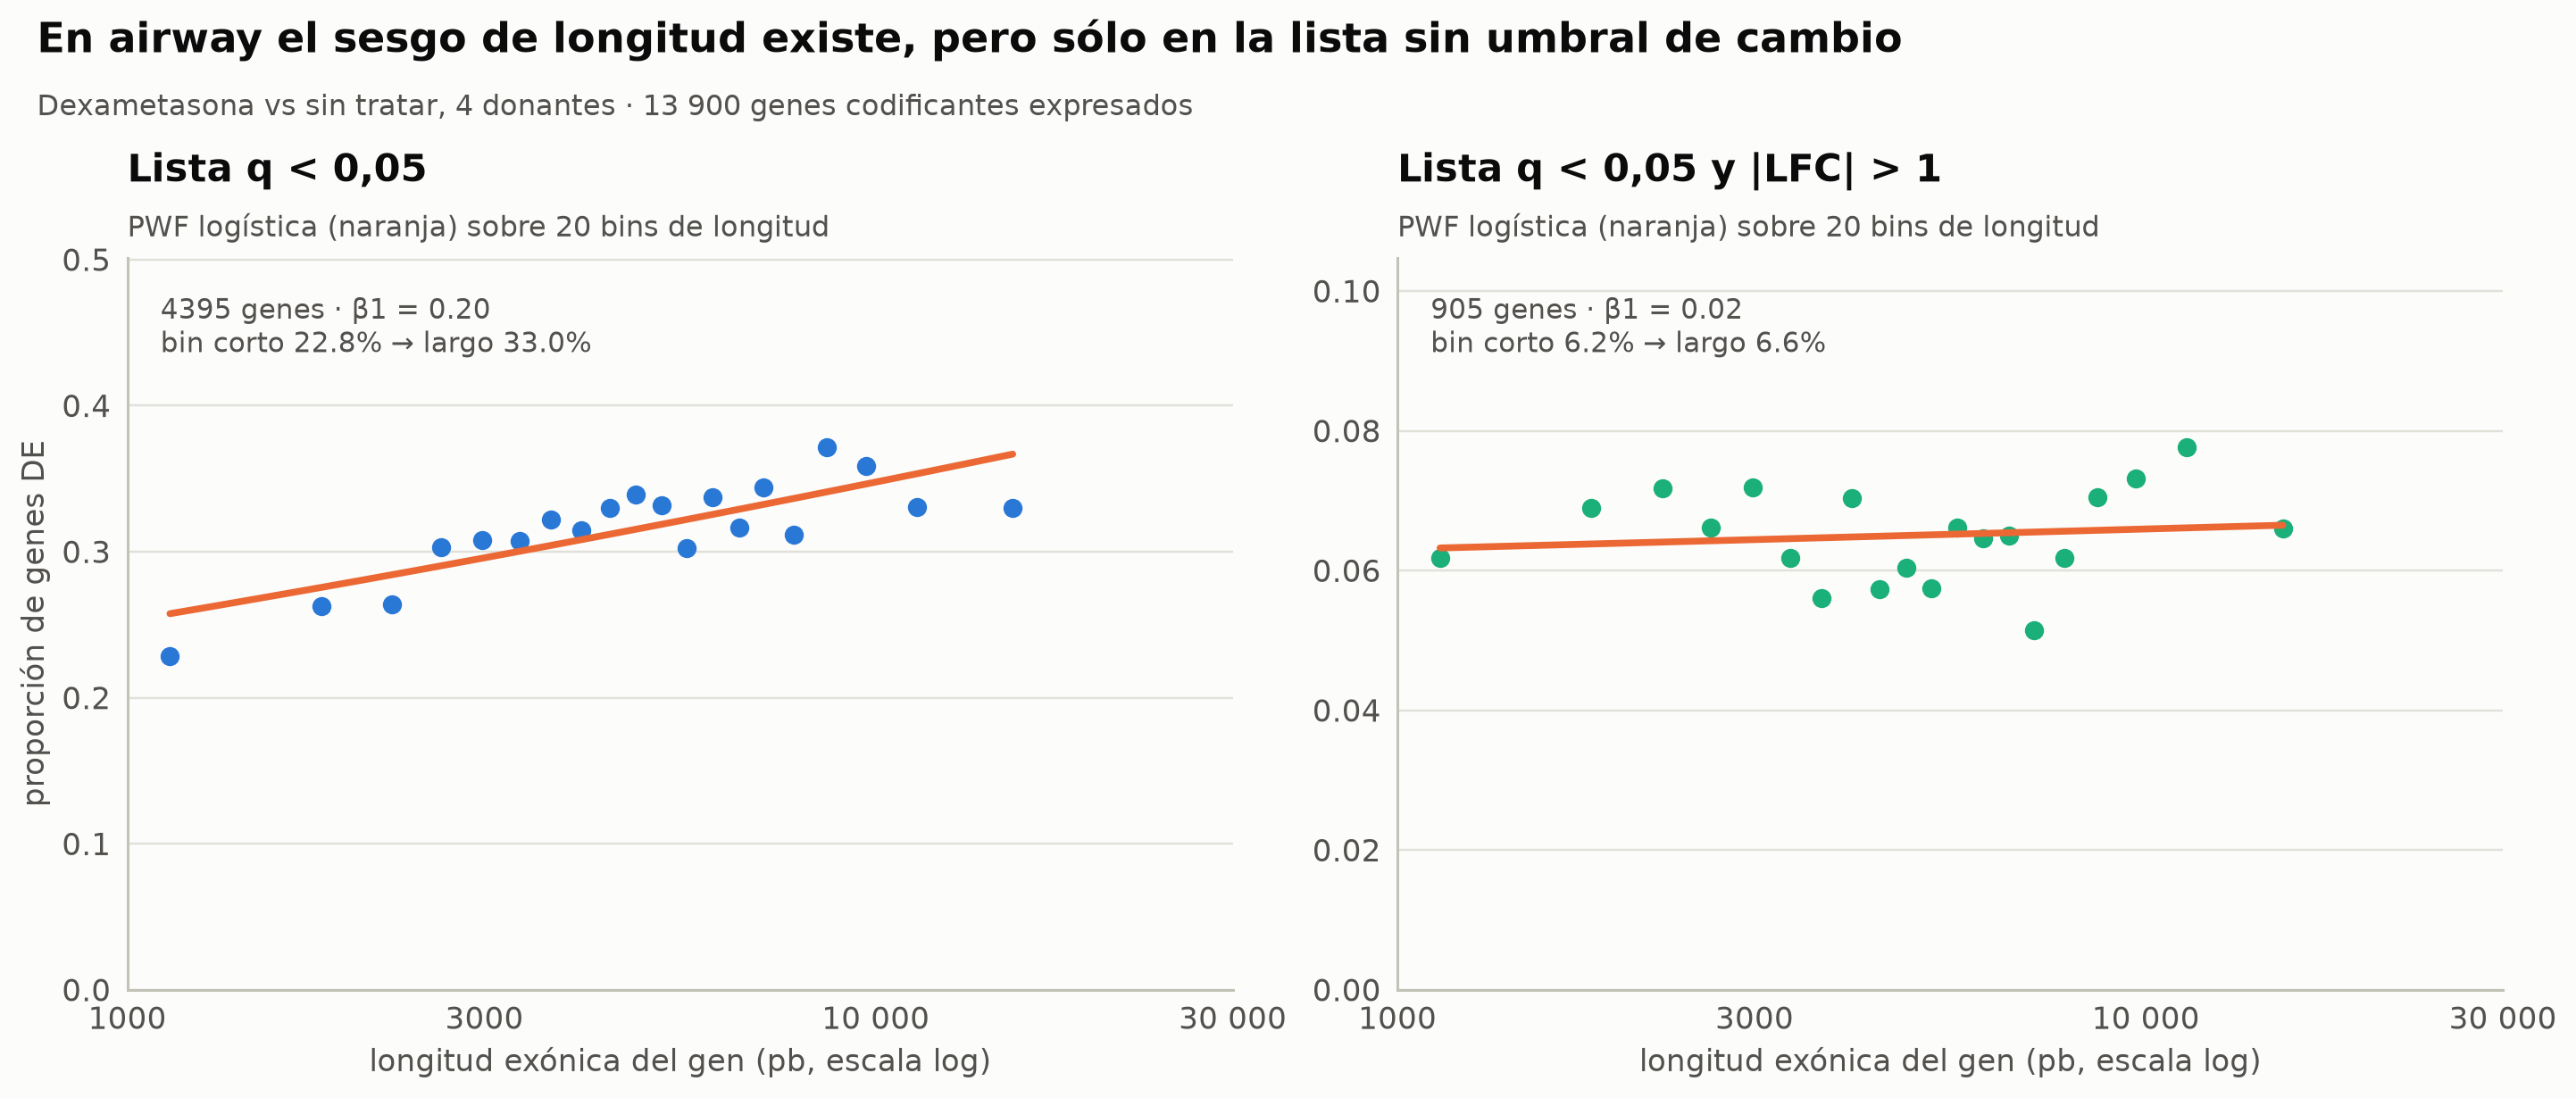

In [20]:
Lr = ranking.bp_length.to_numpy()
lists_len = {"q < 0,05": (ranking.padj < 0.05).to_numpy(),
             "q < 0,05 y |LFC| > 1": ((ranking.padj < 0.05) & (ranking.log2FC.abs() > 1)).to_numpy()}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
pwf_real = {}
for ax, (lab, isde), col in zip(axes, lists_len.items(), [ec.BLUE, ec.AQUA]):
    cen, prop = binned(Lr, isde)
    beta = fit_pwf(Lr, isde)
    pwf_real[lab] = special.expit(beta[0] + beta[1] * np.log(Lr))
    xl = np.exp(np.linspace(np.log(cen[0]), np.log(cen[-1]), 80))
    fitv = special.expit(beta[0] + beta[1] * np.log(xl))
    ax.plot(cen, prop, "o", color=col, ms=6)
    ax.plot(xl, fitv, color=ec.ORANGE, lw=2.5)
    ax.set_xscale("log"); ax.set_ylim(0, prop.max() * 1.35)
    ax.set_xticks([1000, 3000, 10000, 30000]); ax.set_xticklabels(["1000", "3000", "10 000", "30 000"])
    ax.minorticks_off()
    ax.set_xlabel("longitud exónica del gen (pb, escala log)")
    ax.text(0.03, 0.95, f"{isde.sum()} genes · β1 = {beta[1]:.2f}\nbin corto {prop[0]:.1%} → largo {prop[-1]:.1%}",
            transform=ax.transAxes, va="top", fontsize=10, color=ec.INK_2)
    ec.title(ax, f"Lista {lab}", "PWF logística (naranja) sobre 20 bins de longitud")
    print(f"{lab:>22}: β1 = {beta[1]:.3f} · proporción DE {prop[0]:.3f} → {prop[-1]:.3f}")
axes[0].set_ylabel("proporción de genes DE")
ec.fig_title(fig, "En airway el sesgo de longitud existe, pero sólo en la lista sin umbral de cambio",
             "Dexametasona vs sin tratar, 4 donantes · 13 900 genes codificantes expresados")
plt.show()

> 🔎 **Qué observamos.** Con la lista «$q<0{,}05$» la proporción de genes detectados sube del ≈23 % en los genes
> más cortos al ≈33–37 % en los largos: el sesgo de Young et al. aparece en datos reales, aunque con la mitad de
> pendiente que en la simulación (con 4 donantes y 20–40 millones de lecturas, casi todos los genes expresados ya
> tienen bastante potencia). Con el umbral $|\log_2\mathrm{FC}|>1$, la curva es **plana**: los genes que «entraban
> por potencia» eran precisamente los de **cambio pequeño** medidos con precisión, y el umbral de efecto los
> excluye. Es un hallazgo práctico: el sesgo de longitud depende de cómo se construye la lista, y hay que
> diagnosticarlo en cada análisis, no suponerlo.

### 6.4 La corrección de Wallenius sobre términos reales

goseq, por defecto, no remuestrea: usa la **hipergeométrica no central de Wallenius**, que describe la extracción
sin reemplazo de bolas de dos colores con **pesos distintos**. Su parámetro es la razón de momios
$\omega = \bar\pi_{T}/\bar\pi_{\bar T}$ entre la PWF media de los genes del término y la del resto: si el término
tiene genes largos, $\omega>1$ y se «esperan» más genes suyos en la lista. SciPy la implementa en
`stats.nchypergeom_wallenius`. La aplicamos a los términos GO con la lista «$q<0{,}05$», donde el sesgo existe.

In [21]:
isde = lists_len["q < 0,05"]; pwf_r = pwf_real["q < 0,05"]
pos_u = {g: i for i, g in enumerate(ranking.symbol)}
N_r, n_r = len(ranking), int(isde.sum())
rows = []
for t, s in libraries["GO BP"].items():
    idx = np.array([pos_u[g] for g in s if g in pos_u])
    if not (15 <= len(idx) <= 500):
        continue
    inT = np.zeros(N_r, bool); inT[idx] = True
    k_ = int(isde[idx].sum()); K_ = len(idx)
    omega = pwf_r[inT].mean() / pwf_r[~inT].mean()
    rows.append((t, K_, k_, omega, np.median(Lr[idx]), ora(k_, N_r, K_, n_r),
                 stats.nchypergeom_wallenius.sf(k_ - 1, N_r, K_, n_r, omega)))
wal = pd.DataFrame(rows, columns=["term", "K", "k", "omega", "median_len", "p_hyper", "p_wallenius"])
wal["q_hyper"], wal["q_wallenius"] = bh(wal.p_hyper), bh(wal.p_wallenius)
print(f"términos con q < 0,05 · hipergeométrica: {(wal.q_hyper < 0.05).sum()} · Wallenius: {(wal.q_wallenius < 0.05).sum()}")
print(wal.sort_values("p_hyper").head(8)[["term", "K", "k", "omega", "median_len", "p_hyper", "p_wallenius"]]
      .round({"omega": 3, "median_len": 0}).to_string(index=False, formatters={"p_hyper": "{:.1e}".format, "p_wallenius": "{:.1e}".format}))

términos con q < 0,05 · hipergeométrica: 17 · Wallenius: 13
                                                                         term   K   k  omega  median_len p_hyper p_wallenius
                               Extracellular Matrix Organization (GO:0030198) 124  67  1.032      6081.0 1.7e-07     4.7e-07
Transmembrane Receptor Protein Tyrosine Kinase Signaling Pathway (GO:0007169) 211 101  1.035      6435.0 4.8e-07     2.0e-06
                            Extracellular Structure Organization (GO:0043062)  72  43  1.043      6746.0 7.5e-07     2.1e-06
                   External Encapsulating Structure Organization (GO:0045229)  73  43  1.042      6742.0 1.3e-06     3.4e-06
                                    Regulation Of Cell Migration (GO:0030334) 337 146  1.034      6489.0 3.0e-06     1.5e-05
                                 Ras Protein Signal Transduction (GO:0007265) 121  62  1.027      6073.0 5.0e-06     1.1e-05
      Negative Regulation Of Mitotic Cell Cycle Phase Transition 

términos mostrados: 138 · extremo de la diagonal: 6.98


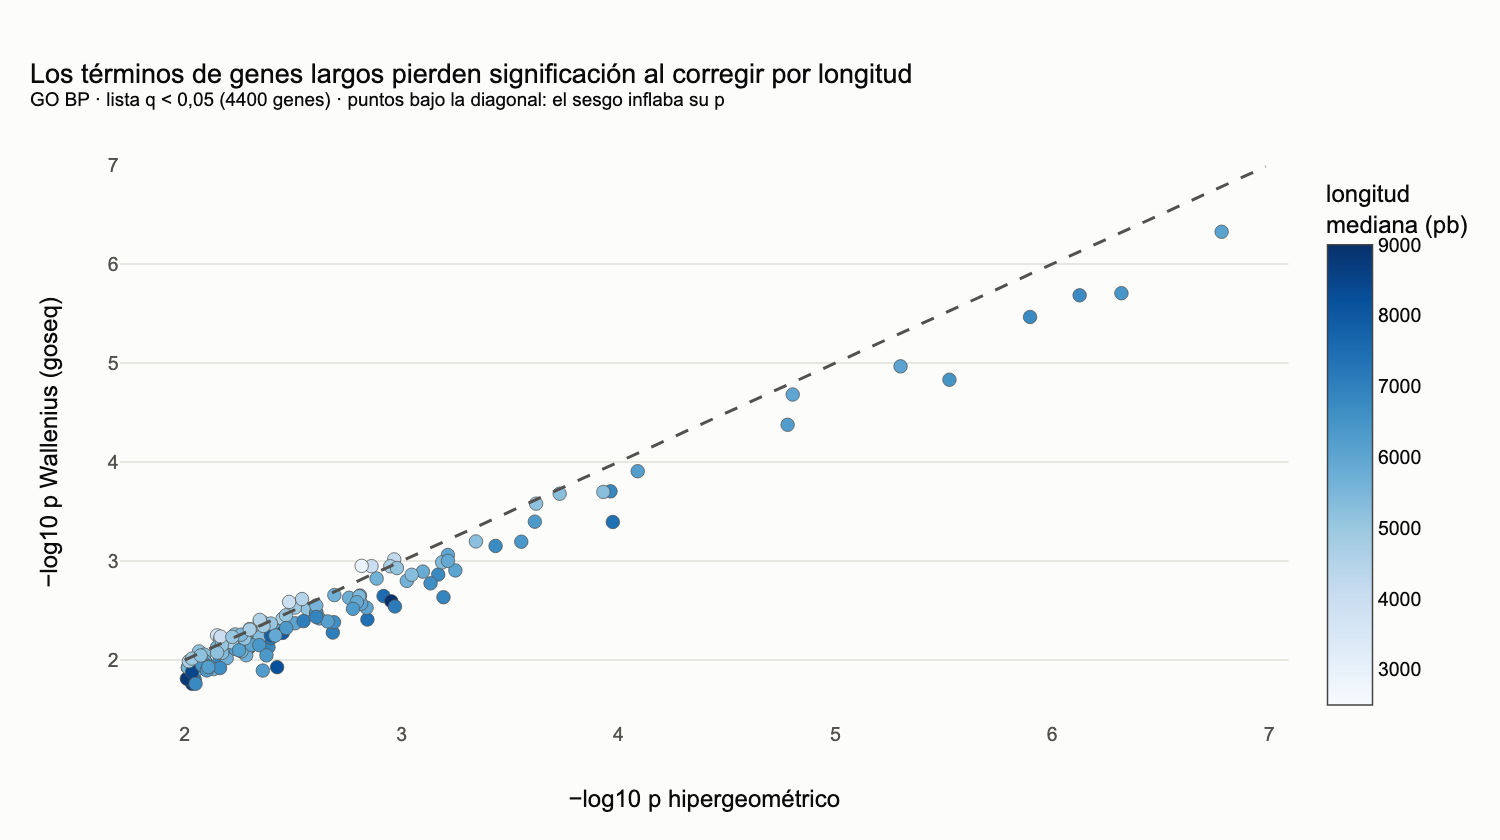

In [22]:
wal["label"] = wal.term.str.replace(r" \(GO:\d+\)", "", regex=True)
wal["cambio"] = np.log10(wal.p_wallenius / wal.p_hyper)
top = wal[wal.p_hyper < 0.01].copy()
fig = px.scatter(top, x=-np.log10(top.p_hyper), y=-np.log10(top.p_wallenius), color="median_len",
                 color_continuous_scale="Blues", range_color=(2500, 9000),
                 custom_data=["label", "K", "k", "omega", "median_len", "p_hyper", "p_wallenius"])
fig.update_traces(marker=dict(size=9, line=dict(color=ec.INK_2, width=0.5)),
                  hovertemplate="<b>%{customdata[0]}</b><br>k = %{customdata[2]} de K = %{customdata[1]}"
                                "<br>longitud mediana de sus genes: %{customdata[4]:,.0f} pb"
                                "<br>ω = PWF media dentro / fuera = %{customdata[3]:.3f}"
                                "<br>p hipergeométrico = %{customdata[5]:.1e}<br>p Wallenius = %{customdata[6]:.1e}"
                                "<extra></extra>")
_lp = -np.log10(np.r_[top.p_hyper.values, top.p_wallenius.values])
mx = float(np.max(_lp[np.isfinite(_lp)]) * 1.03)
print(f"términos mostrados: {len(top)} · extremo de la diagonal: {mx:.2f}")
fig.add_shape(type="line", x0=2.0, y0=2.0, x1=float(mx), y1=float(mx), line=dict(color=ec.INK_2, dash="dash"))
fig.update_layout(title="Los términos de genes largos pierden significación al corregir por longitud"
                        "<br><sup>GO BP · lista q < 0,05 (4400 genes) · puntos bajo la diagonal: el sesgo inflaba su p</sup>",
                  xaxis_title="−log10 p hipergeométrico", yaxis_title="−log10 p Wallenius (goseq)",
                  coloraxis_colorbar=dict(title="longitud<br>mediana (pb)"), height=560, margin=dict(t=110))
fig.show()

> 🔎 **Qué observamos.** Casi todos los puntos caen por debajo de la diagonal: los genes con anotaciones GO ricas
> suelen ser más largos que la media del universo ($\omega>1$), y los términos más oscuros (genes más largos) son
> los que más caen, a veces en medio orden de magnitud: parte de su «enriquecimiento» se debía a que sus genes, por
> largos, se detectan mejor. Sólo unos pocos términos de genes cortos (puntos claros) quedan sobre la diagonal. En *airway* la corrección no cambia la historia (la matriz extracelular y la
> migración siguen arriba), pero sí el orden fino y el número de términos que superan el umbral. En experimentos con
> poca profundidad, o en organismos con genes muy desiguales, la diferencia puede ser mucho mayor.

> ✅ **Compruebe su comprensión.** Un colega usa el genoma como universo **y** no corrige por longitud. ¿Los dos
> errores se compensan o se suman? *(Se suman: ambos inflan los términos de genes expresados y largos, que en muchos
> tejidos son los mismos, como los de matriz extracelular y adhesión.)*

---

## 7. GSEA: sin umbrales

El análisis de sobrerrepresentación tiene dos debilidades:

1. **Depende de un umbral arbitrario.** ¿FDR 0,05 o 0,1? ¿Con o sin $|\log_2\mathrm{FC}|>1$? Acabamos de ver que
   la elección cambia hasta el sesgo de longitud.
2. **Es ciego a cambios pequeños pero coordinados.** Si los cien genes de una ruta bajan un 20 % cada uno, quizá
   ninguno sea significativo, pero el conjunto lo es de forma abrumadora.

Así ocurrió en el estudio de Mootha et al. (2003) sobre músculo de pacientes con diabetes tipo 2: ningún gen
individual destacaba tras corregir por pruebas múltiples, pero los genes de la **fosforilación oxidativa**
aparecían consistentemente reprimidos. Para detectarlo idearon el **análisis de enriquecimiento de conjuntos de
genes** (GSEA), que Subramanian et al. (2005) refinaron después en su forma actual.

### La idea: un paseo por la lista ordenada

Ordene **todos** los genes por un estadístico de cambio (el $z$ de Wald en el libro; nuestro $t$ moderado en
*airway*), del más sobreexpresado al más reprimido. Recorra la lista de arriba abajo con un contador que **sube**
cada vez que encuentra un gen del conjunto $S$ y **baja** un poquito con cada gen que no está. Si los genes de $S$
están repartidos al azar, el contador oscila cerca de cero; si se concentran arriba, sube con fuerza al principio.

Una imagen cotidiana: recorra una fila de 10 000 personas ordenadas por estatura, de la más alta a la más baja,
buscando a los 80 jugadores de un club de baloncesto. Si los encuentra casi todos entre los primeros mil, el club es
claramente «de gente alta», aunque ninguno de ellos, por sí solo, sea un caso excepcional.

**Definición (puntuación de enriquecimiento).** Sean $r_1\ge r_2\ge\cdots\ge r_N$ los estadísticos ordenados,
$N_H=|S|$ y $p\ge 0$ un exponente de ponderación. Para cada posición $i$,

$$
P_{\mathrm{hit}}(i)=\sum_{\substack{j\le i\\ g_j\in S}}\frac{|r_j|^{p}}{N_R},\qquad
P_{\mathrm{miss}}(i)=\sum_{\substack{j\le i\\ g_j\notin S}}\frac{1}{N-N_H},\qquad
N_R=\sum_{g_j\in S}|r_j|^{p},
\tag{11-gsea}
$$

y la puntuación de enriquecimiento $\mathrm{ES}$ es la desviación máxima de $P_{\mathrm{hit}}(i)-P_{\mathrm{miss}}(i)$
respecto a cero, **con su signo**.

| Símbolo | Significado |
|---|---|
| $r_j$ | Estadístico del gen en la posición $j$ de la lista ordenada |
| $g_j$ | Gen en la posición $j$ |
| $N$ | Genes de la lista completa (el universo) |
| $N_H$ | Número de genes del conjunto presentes en la lista |
| $N_R$ | Suma de los pesos de los genes del conjunto (normaliza $P_{\mathrm{hit}}$ a 1) |
| $p$ | Peso: con $p=0$ se obtiene el estadístico de Kolmogórov-Smirnov del trabajo original; con $p=1$ (por defecto), cada gen pesa según la magnitud de su cambio |

Las dos sumas acumuladas valen 1 al final de la lista, así que **el paseo empieza y termina en cero**. Los genes de
$S$ que aparecen antes del máximo forman el **núcleo líder** (*leading edge*), el subconjunto que más contribuye a la
señal y el primero que conviene examinar.

### Un ejemplo de juguete, a mano

Lista de $N=6$ genes con $r = (3, 2, 1, -1, -2, -3)$ y conjunto $S=\{g_1, g_4\}$, con $p=1$. Entonces
$N_R = |3|+|-1| = 4$ y cada fallo resta $1/(N-N_H) = 1/4$:

| $i$ | $g_i\in S$ | $P_{\mathrm{hit}}(i)$ | $P_{\mathrm{miss}}(i)$ | paseo |
|---|---|---|---|---|
| 1 | sí | 3/4 | 0 | **0,75** |
| 2 | no | 3/4 | 1/4 | 0,50 |
| 3 | no | 3/4 | 2/4 | 0,25 |
| 4 | sí | 1 | 2/4 | 0,50 |
| 5 | no | 1 | 3/4 | 0,25 |
| 6 | no | 1 | 1 | 0 |

El máximo es $0{,}75$ en $i=1$, así que $\mathrm{ES}=+0{,}75$ y el núcleo líder es $\{g_1\}$. Con $p=0$, $g_1$ y
$g_4$ pesarían lo mismo ($1/2$ cada uno): el paseo sería $0{,}5;\ 0{,}25;\ 0;\ 0{,}5;\ 0{,}25;\ 0$ y la ES bajaría
a $0{,}5$. El gen con el cambio grande pierde protagonismo. Comprobémoslo con el código del libro.

In [23]:
def paseo_gsea(r, en_conjunto, p=1.0):
    """r: estadísticos; en_conjunto: booleanos. Devuelve paseo y ES (código del libro)."""
    o = np.argsort(-r)
    hit = en_conjunto[o]
    w = np.abs(r[o]) ** p
    phit = np.cumsum(np.where(hit, w, 0)) / w[hit].sum()
    pmiss = np.cumsum(~hit) / (~hit).sum()
    paseo = phit - pmiss
    return paseo, paseo[np.argmax(np.abs(paseo))]

r_toy = np.array([3., 2., 1., -1., -2., -3.])
s_toy = np.array([True, False, False, True, False, False])
for pw_ in (1.0, 0.0):
    walk, es = paseo_gsea(r_toy, s_toy, p=pw_)
    print(f"p = {pw_:.0f}: paseo = {np.round(walk, 3)}  →  ES = {es:+.3f}")
print("ORA del ejemplo del libro:", round(ora(12, 9992, 150, 404), 4))     # 0.0184

p = 1: paseo = [0.75 0.5  0.25 0.5  0.25 0.  ]  →  ES = +0.750
p = 0: paseo = [0.5  0.25 0.   0.5  0.25 0.  ]  →  ES = +0.500
ORA del ejemplo del libro: 0.0184


### 7.1 Ejemplo del libro: «Leer un resultado de GSEA»

En el experimento simulado del libro, un conjunto de **80 genes**, **28** de ellos sobreexpresados de verdad y el
resto sin cambio. Lo construimos con el mismo generador y calculamos el paseo con $p=1$, la ES, su posición, el
núcleo líder y, con **1000 permutaciones de genes** (conjuntos aleatorios de 80 genes), el valor $p$ y la NES.

**Significación y normalización.** Lo ideal es permutar las **etiquetas de las muestras**, que conserva la
correlación entre genes; con tres réplicas por grupo sólo hay diez permutaciones distintas, y en la práctica se
permutan **los genes**, lo que ignora esa correlación y es por tanto algo **anticonservador**. Para comparar conjuntos
de distinto tamaño, la ES se divide por la media de las ES nulas **del mismo signo** y se obtiene la **NES**; el
valor $p$ (para una ES positiva) es $p = (\#\{\mathrm{ES}^{\text{nula}}_b \ge \mathrm{ES}\}+1)/(n_{+}+1)$, donde
$n_{+}$ es el número de permutaciones con ES positiva.

In [24]:
order_b = np.argsort(-wald_b)
upg = np.where(de_b & (lfc_b > 0))[0]
gset_b = np.concatenate([book_rng.choice(upg, 28, replace=False),
                         book_rng.choice(np.where(~de_b)[0], 52, replace=False)])
inset_b = np.zeros(G, bool); inset_b[gset_b] = True
walk_b, ES_b = paseo_gsea(wald_b, inset_b, p=1.0)
imax_b = int(np.argmax(np.abs(walk_b)))
nulls_b = []
for _ in range(1000):                                     # permutación de genes: conjuntos aleatorios de 80 genes
    ins = np.zeros(G, bool); ins[book_rng.choice(G, len(gset_b), replace=False)] = True
    nulls_b.append(paseo_gsea(wald_b, ins)[1])
nulls_b = np.array(nulls_b)
pos_null = nulls_b[nulls_b > 0]
p_es = (np.sum(pos_null >= ES_b) + 1) / (len(pos_null) + 1)
NES_b = ES_b / pos_null.mean()
lead_b = int(inset_b[order_b][:imax_b + 1].sum())
lead_true = int((inset_b & de_b)[order_b][:imax_b + 1].sum())
_, ES0_b = paseo_gsea(wald_b, inset_b, p=0.0)
print(f"ES = {ES_b:.3f} en la posición {imax_b+1} de {G}")
print(f"NES = {NES_b:.2f} · permutaciones con ES positiva n+ = {len(pos_null)} · máx. ES nula = {pos_null.max():.3f}")
print(f"p = (0 + 1)/(n+ + 1) = {p_es:.4f}")
print(f"núcleo líder: {lead_b} genes, de ellos {lead_true} con cambio verdadero (de 28)")
print(f"ES sin pesos (p = 0, Kolmogórov-Smirnov) = {ES0_b:.3f}")

ES = 0.668 en la posición 1087 de 9992
NES = 2.41 · permutaciones con ES positiva n+ = 616 · máx. ES nula = 0.500
p = (0 + 1)/(n+ + 1) = 0.0016
núcleo líder: 30 genes, de ellos 23 con cambio verdadero (de 28)
ES sin pesos (p = 0, Kolmogórov-Smirnov) = 0.295


> 🔎 **Qué observamos.** Todas las cifras del libro: $\mathrm{ES}=0{,}668$ en la posición 1087, NES $=2{,}41$ y
> $p=0{,}0016$. Ninguna de las 1000 ES aleatorias positivas alcanzó el valor observado, así que
> $p\approx 1/(n_{+}+1)$: **el valor $p$ está limitado por el número de permutaciones, no por la evidencia**. El
> núcleo líder tiene 30 genes, que incluyen casi todos los realmente sobreexpresados. Con la versión sin pesos
> ($p=0$) la ES es sólo $0{,}295$: los 52 genes sin cambio diluyen la señal cuando todos los genes pesan lo mismo,
> mientras que la ponderación deja que los pocos genes con cambios fuertes dominen el paseo.

La animación recorre la lista de arriba abajo: cada raya negra es un gen del conjunto y la curva verde es el paseo.

![El paseo de GSEA recorre los 9992 genes ordenados: sube con cada gen del conjunto (rayas) y baja un poco con cada gen ajeno; su máximo, ES = 0,668, se alcanza en la posición 1087.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-11-rnaseq/11.4_paseo_gsea.gif)

*El paseo de GSEA recorre los 9992 genes ordenados: sube con cada gen del conjunto (rayas) y baja un poco con cada gen ajeno; su máximo, ES = 0,668, se alcanza en la posición 1087.*

In [25]:
xs = np.arange(1, G + 1)
hits_pos = np.where(inset_b[order_b])[0] + 1
walk_unw, _ = paseo_gsea(wald_b, inset_b, p=0.0)
stops = np.unique(np.concatenate([np.geomspace(30, G, 44).astype(int), [imax_b + 1, G]]))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.6), gridspec_kw=dict(height_ratios=[4, 0.7], hspace=0.08), sharex=True)

def update(i):
    stop = stops[i]
    ax1.clear(); ax2.clear()
    ax1.plot(xs[:stop], walk_b[:stop], color=ec.GREEN, lw=2.2)
    ax1.plot(xs[:stop], walk_unw[:stop], color=ec.MUTED, lw=1.4, ls="--")
    ax1.axhline(0, color=ec.BASELINE, lw=1)
    j = int(np.argmax(np.abs(walk_b[:stop])))
    ax1.plot([j + 1], [walk_b[j]], "o", color=ec.RED, ms=7)
    ax1.text(j + 1 + 150, walk_b[j] + 0.03, f"máximo hasta ahora: {walk_b[j]:.3f} (posición {j+1})", color=ec.RED, fontsize=10)
    ax1.text(G * 0.98, 0.70, f"genes recorridos: {stop}\ngenes del conjunto vistos: {(hits_pos <= stop).sum()} de 80",
             ha="right", va="top", fontsize=10, color=ec.INK_2)
    ax1.text(G * 0.45, 0.02, "sin pesos (p = 0)", color=ec.MUTED, fontsize=9.5)
    ax1.set_xlim(1, G); ax1.set_ylim(-0.12, 0.78); ax1.set_ylabel("puntuación acumulada")
    ax2.vlines(hits_pos[hits_pos <= stop], 0, 1, color=ec.INK, lw=0.8)
    ax2.set_ylim(0, 1); ax2.set_yticks([]); ax2.set_xlim(1, G)
    ax2.set_xlabel("posición en la lista ordenada (de más sobreexpresado a más reprimido)")
    ec.title(ax1, "El paseo sube con fuerza donde se concentran los genes del conjunto",
             "Conjunto de 80 genes (28 sobreexpresados de verdad) · simulación del libro · p = 1 (verde)")

ec.animate(fig, update, frames=len(stops), interval=150, name="11.4_paseo_gsea")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

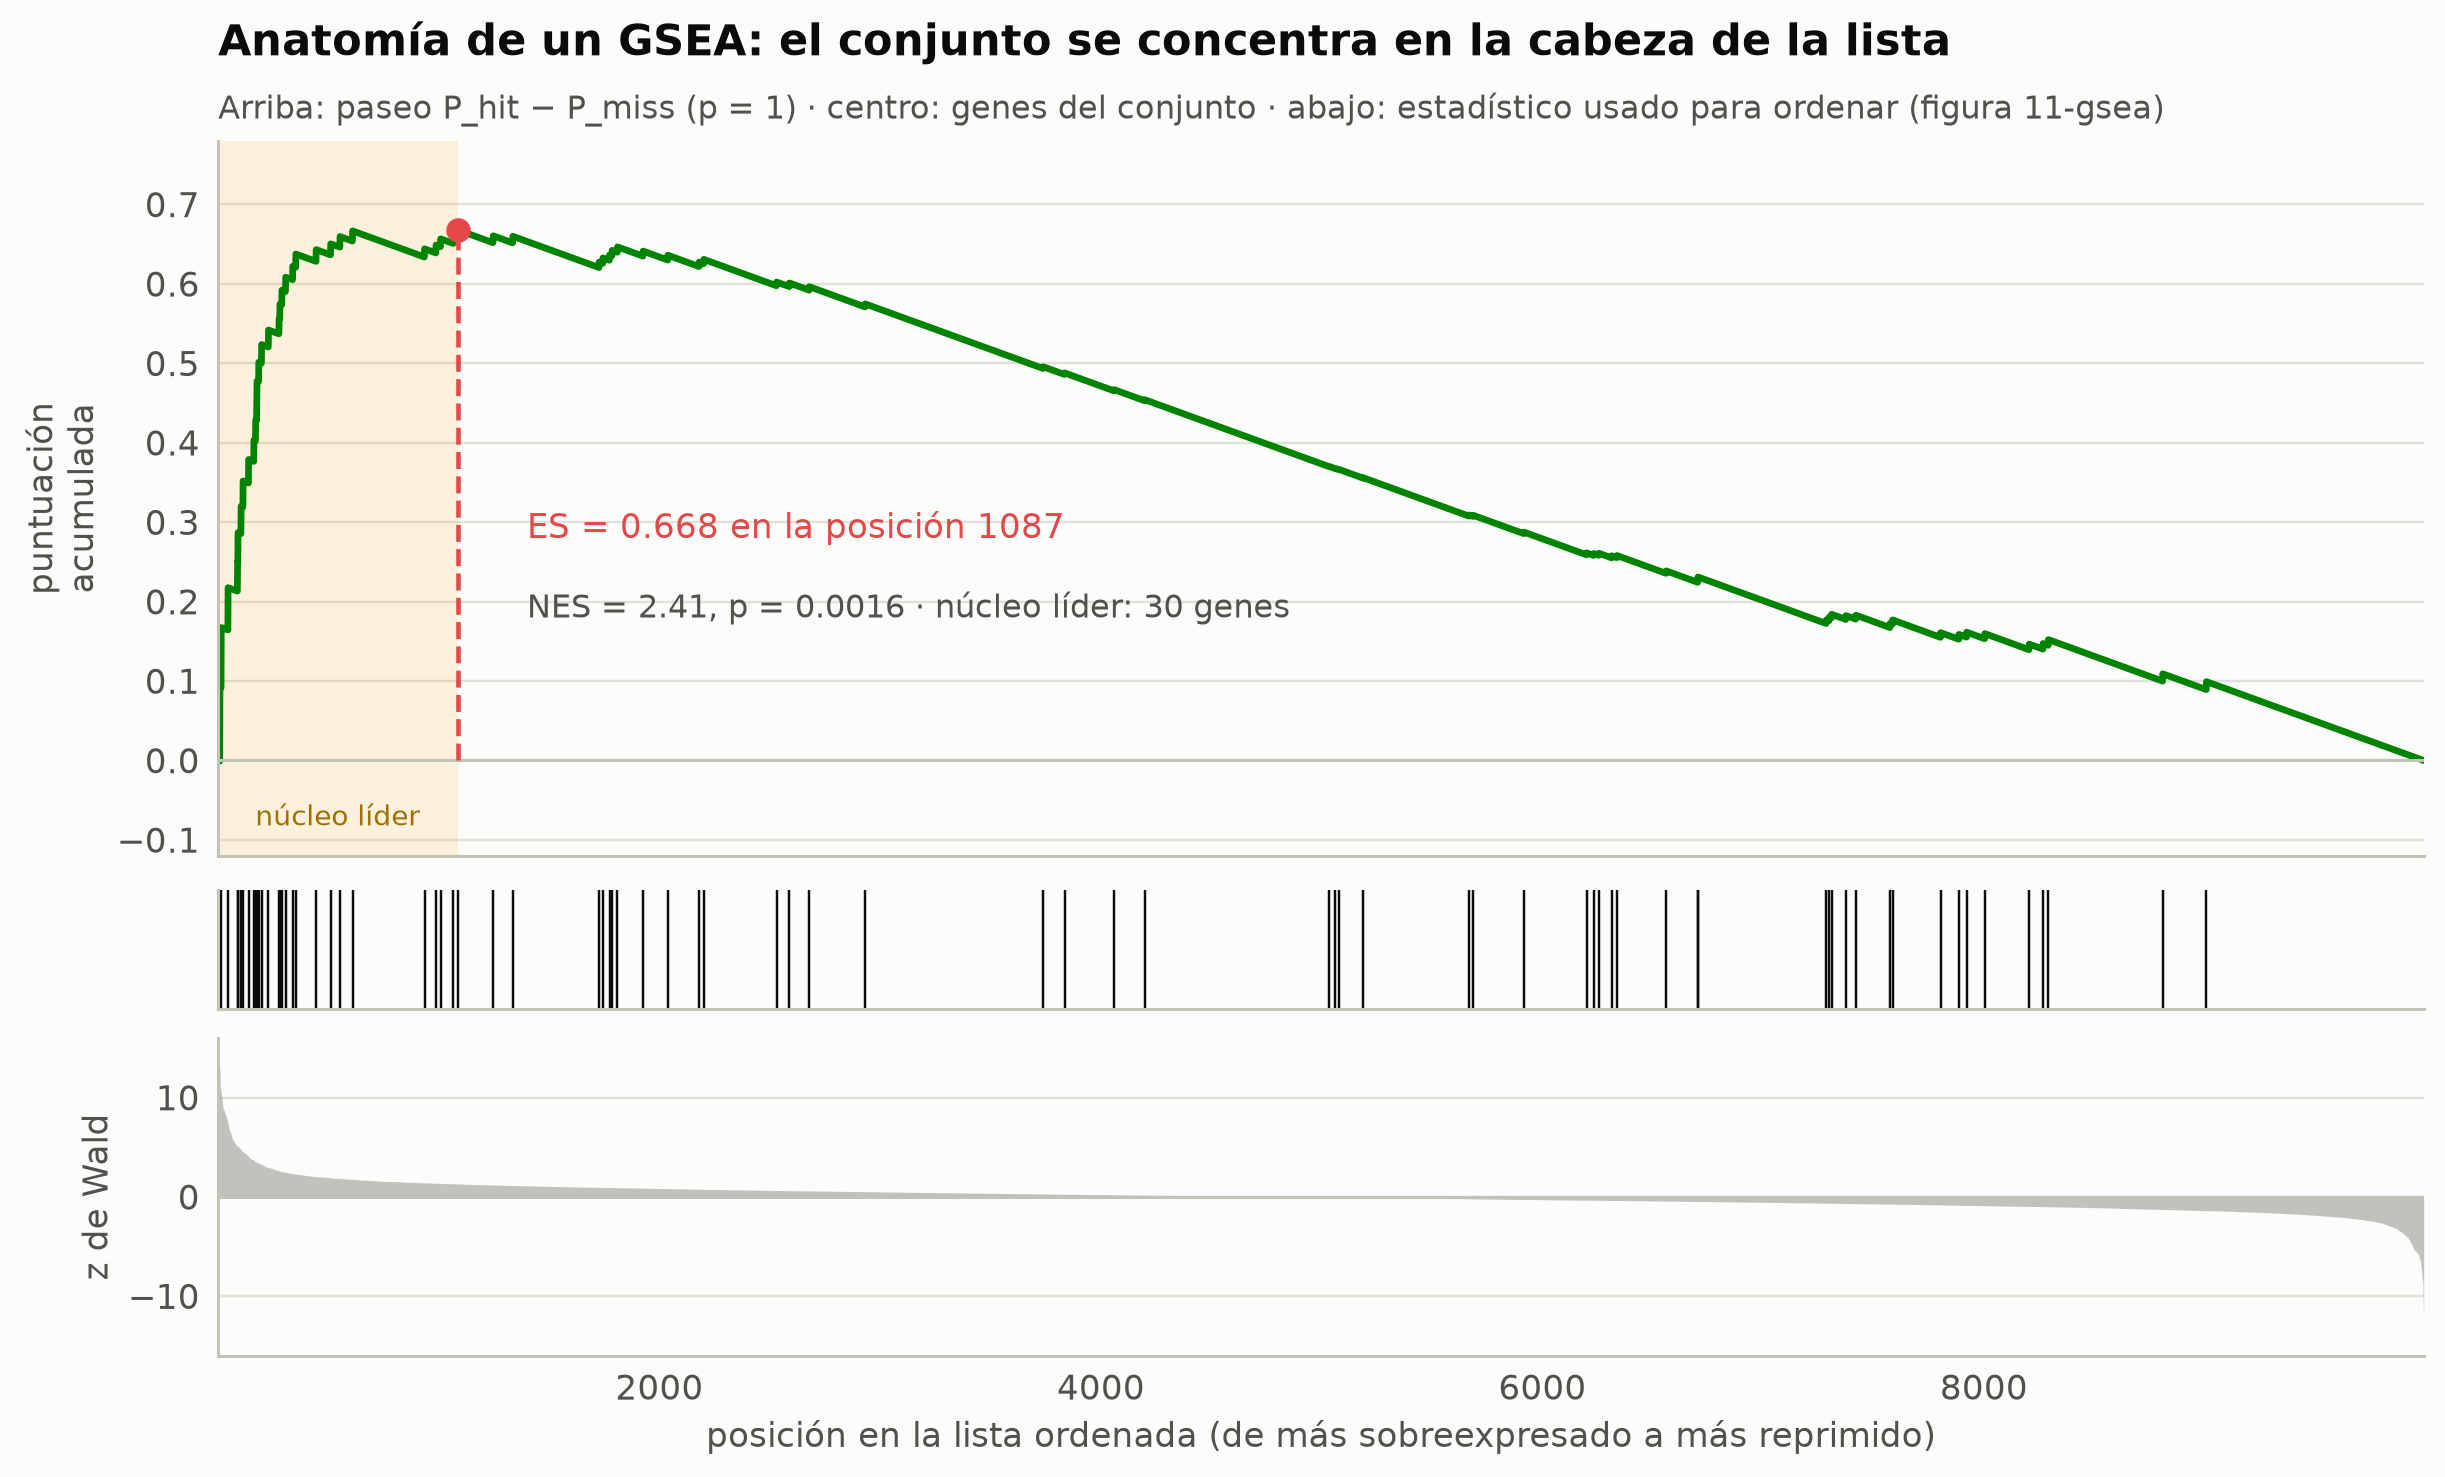

In [26]:
# Figura de tres paneles del libro (figura 11-gsea): paseo, rayas del conjunto y estadístico de orden
fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(11, 6.6), sharex=True,
                                 gridspec_kw=dict(height_ratios=[3.6, 0.6, 1.6], hspace=0.06))
a1.plot(xs, walk_b, color=ec.GREEN, lw=2.2)
a1.axhline(0, color=ec.BASELINE, lw=1)
a1.vlines(imax_b + 1, 0, ES_b, color=ec.RED, ls="--", lw=1.5)
a1.plot([imax_b + 1], [ES_b], "o", color=ec.RED, ms=7)
a1.text(1400, 0.28, f"ES = {ES_b:.3f} en la posición {imax_b+1}", color=ec.RED, fontsize=11)
a1.text(1400, 0.18, f"NES = {NES_b:.2f}, p = {p_es:.4f} · núcleo líder: {lead_b} genes", color=ec.INK_2, fontsize=10.5)
a1.axvspan(1, imax_b + 1, color=ec.YELLOW, alpha=0.12)
a1.text(imax_b / 2, -0.09, "núcleo líder", ha="center", va="bottom", fontsize=9, color="#a07000")
a1.set_ylim(-0.12, 0.78); a1.set_ylabel("puntuación\nacumulada")
a2.vlines(hits_pos, 0, 1, color=ec.INK, lw=0.8); a2.set_yticks([]); a2.set_ylim(0, 1)
a3.fill_between(xs, np.clip(wald_b[order_b], -15, 15), color=ec.MUTED, alpha=0.5, lw=0)
a3.axhline(0, color=ec.BASELINE, lw=1); a3.set_ylim(-16, 16); a3.set_ylabel("z de Wald")
a3.set_xlim(1, G); a3.set_xlabel("posición en la lista ordenada (de más sobreexpresado a más reprimido)")
ec.title(a1, "Anatomía de un GSEA: el conjunto se concentra en la cabeza de la lista",
         "Arriba: paseo P_hit − P_miss (p = 1) · centro: genes del conjunto · abajo: estadístico usado para ordenar (figura 11-gsea)")
plt.show()

> ✅ **Compruebe su comprensión.** Si el conjunto estuviera concentrado **al final** de la lista (genes reprimidos),
> ¿cómo sería el paseo y qué signo tendría la ES? *(El paseo bajaría lentamente al principio, porque sólo encuentra
> fallos, alcanzaría un mínimo profundo justo antes de la zona de los genes del conjunto y subiría bruscamente hasta
> cero al final: ES negativa. El núcleo líder serían los genes del conjunto situados **después** del mínimo.)*

### 7.2 Muchas permutaciones, rápido: la idea de fgsea

Calcular 1000 paseos completos de 10 000 posiciones para cada uno de miles de conjuntos es costoso. Dos trucos lo
resuelven:

1. **Sólo importan las posiciones de los genes del conjunto.** Si $q_1<q_2<\dots<q_{N_H}$ son esas posiciones (base 0)
   y $W_h$ la suma acumulada de los pesos hasta el $h$-ésimo gen del conjunto, justo después de él el paseo vale
   $W_h/N_R - (q_h - h + 1)/(N-N_H)$, y justo antes, $W_{h-1}/N_R - (q_h-h+1)/(N-N_H)$. El máximo y el mínimo del
   paseo ocurren en esos puntos, así que basta un cálculo de tamaño $N_H$ y no de tamaño $N$.
2. **Reutilizar las permutaciones.** Korotkevich et al. (fgsea, 2016) mostraron que una misma muestra de conjuntos
   aleatorios sirve para **todos los conjuntos del mismo tamaño**. Generamos una sola matriz de permutaciones de la
   lista y, para un conjunto de tamaño $m$, usamos sus primeras $m$ columnas.

In [27]:
def es_from_positions(P, abs_r, p=1.0):
    """ES de muchos conjuntos a la vez. P: (B, m) posiciones (base 0) de los m genes de cada conjunto."""
    P = np.sort(P, axis=1)
    B, m = P.shape; N = len(abs_r)
    w = abs_r[P] ** p
    cw = np.cumsum(w, axis=1); NR = cw[:, -1:]
    h = np.arange(1, m + 1)
    miss_before = (P - (h - 1)) / (N - m)                 # fallos acumulados antes del gen h del conjunto
    top = cw / NR - miss_before                           # justo después de cada gen del conjunto
    bottom = (cw - w) / NR - miss_before                  # justo antes
    mx, mn = top.max(1), bottom.min(1)
    return np.where(mx >= -mn, mx, mn)

# comprobación contra el paseo completo, en el ejemplo del libro
pos_b = np.sort(np.where(inset_b[order_b])[0])
print(f"ES por posiciones = {es_from_positions(pos_b[None, :], np.abs(wald_b[order_b]))[0]:.6f}"
      f" · ES del paseo completo = {ES_b:.6f}")

ES por posiciones = 0.667884 · ES del paseo completo = 0.667884


---

## 8. 🧪 GSEA desde cero sobre el experimento *airway*

Ordenamos los 13 900 genes por el $t$ moderado y evaluamos los 50 *hallmarks* y las rutas de KEGG de 15–500 genes
con 2000 permutaciones de genes reutilizadas por tamaño. Como FDR usamos BH sobre los valores $p$ nominales, una
simplificación: el GSEA original estima la FDR comparando la distribución de NES observadas con la de NES nulas de
todos los conjuntos.

> 🤔 **Antes de ejecutar, prediga:** ¿qué *hallmark* tendrá la NES positiva más alta? Pista: los glucocorticoides
> se llaman así por su efecto sobre la glucosa, y el tejido adiposo es uno de sus grandes blancos.

In [28]:
rk = ranking.sort_values("t", ascending=False).reset_index(drop=True)
r_air = rk.t.to_numpy(); genes_air = rk.symbol.to_numpy(); N_air = len(r_air)
pos_air = {g: i for i, g in enumerate(genes_air)}
abs_r_air = np.abs(r_air)
perm_rng = np.random.default_rng(114)
N_PERM = 2000
PERM = np.argsort(perm_rng.random((N_PERM, N_air)), axis=1)[:, :500]     # una sola matriz de permutaciones

def gsea_prerank(sets, min_size=15, max_size=500):
    """GSEA con permutación de genes: ES, NES, p nominal, q (BH) y núcleo líder de cada conjunto."""
    rows, null_cache = [], {}
    for t, s in sets.items():
        idx = np.array(sorted(pos_air[g] for g in s if g in pos_air))
        m = len(idx)
        if not (min_size <= m <= max_size):
            continue
        es = es_from_positions(idx[None, :], abs_r_air)[0]
        if m not in null_cache:
            null_cache[m] = es_from_positions(PERM[:, :m], abs_r_air)
        nul = null_cache[m]
        same = nul[nul >= 0] if es >= 0 else nul[nul < 0]
        p = (np.sum(np.abs(same) >= abs(es)) + 1) / (len(same) + 1)
        nes = es / np.abs(same).mean()
        # núcleo líder: genes del conjunto antes del máximo (ES > 0) o después del mínimo (ES < 0)
        walk = np.zeros(N_air, bool); walk[idx] = True
        w_ = np.where(walk, abs_r_air, 0)
        rs = np.cumsum(w_) / w_.sum() - np.cumsum(~walk) / (~walk).sum()
        j = int(np.argmax(rs)) if es >= 0 else int(np.argmin(rs))
        lead = genes_air[idx[idx <= j]] if es >= 0 else genes_air[idx[idx >= j]][::-1]
        rows.append((t, m, es, nes, p, len(lead), ", ".join(lead[:12])))
    out = pd.DataFrame(rows, columns=["term", "size", "ES", "NES", "pval", "n_lead", "leading_edge"])
    out["q"] = bh(out.pval.values)
    return out.sort_values("NES", ascending=False).reset_index(drop=True)

t_ = time.time()
gsea_res = {short: gsea_prerank(libraries[short]) for short in ["Hallmark", "KEGG"]}
print(f"GSEA de {sum(len(v) for v in gsea_res.values())} conjuntos en {time.time()-t_:.1f} s")
h = gsea_res["Hallmark"]
show = pd.concat([h.head(6), h.tail(4)])
show[["term", "size", "ES", "NES", "pval", "q", "n_lead", "leading_edge"]].round({"ES": 3, "NES": 2, "pval": 4, "q": 3})

GSEA de 340 conjuntos en 0.8 s


,term,size,ES,NES,pval,q,n_lead,leading_edge
0,Adipogenesis,187,0.449,1.91,0.0010,0.024,74,"SPARCL1, GPX3, STOM, TST, ACADS, SLC5A6, SORBS..."
1,TNF-alpha Signaling via NF-kB,176,0.374,1.58,0.0010,0.024,46,"DUSP1, DNAJB4, PER1, NR4A3, TSC22D1, PTX3, CEB..."
2,Androgen Response,91,0.409,1.57,0.0111,0.079,26,"ADAMTS1, TSC22D1, STEAP4, PDLIM5, FKBP5, GPD1L..."
3,Oxidative Phosphorylation,184,0.349,1.48,0.0039,0.052,81,"CPT1A, ALDH6A1, ISCA1, CYB5A, UQCRC1, SLC25A4,..."
4,UV Response Dn,140,0.353,1.44,0.0059,0.059,45,"DUSP1, COL11A1, ANXA4, MT1E, PDLIM5, TGFBR2, A..."
5,Complement,145,0.344,1.41,0.0135,0.085,48,"CTSC, DGKH, MAFF, RAF1, ANG, DUSP5, COL4A2, MM..."
46,Interferon Alpha Response,88,-0.343,-1.32,0.0544,0.170,34,"SAMD9L, CASP1, PARP9, TRIM5, IFI44, CD74, UBA7..."
47,Hedgehog Signaling,27,-0.452,-1.36,0.0908,0.210,14,"AMOT, CDK6, LDB1, VEGFA, TLE3, CDK5R1, ADGRG1,..."
48,E2F Targets,192,-0.322,-1.39,0.0072,0.060,64,"LIG1, CDKN1A, BRCA1, CDK4, PCNA, CIT, TUBB, EZ..."
49,p53 Pathway,180,-0.332,-1.43,0.0041,0.052,53,"RRAD, CDKN1A, RAP2B, PLK2, HSPA4L, SDC1, LIF, ..."


In [29]:
k_ = gsea_res["KEGG"]
print("KEGG · NES más altas:")
print(k_.head(6)[["term", "size", "NES", "pval", "q"]].round(3).to_string(index=False))
print("\nKEGG · NES más bajas:")
print(k_.tail(6)[["term", "size", "NES", "pval", "q"]].round(3).to_string(index=False))

KEGG · NES más altas:
                                                      term  size   NES  pval     q
                                        Mineral absorption    37 1.912 0.001 0.053
                           Adipocytokine signaling pathway    55 1.871 0.002 0.053
                                     Propanoate metabolism    30 1.798 0.004 0.088
                                    AMPK signaling pathway   102 1.700 0.002 0.053
                                        Yersinia infection   113 1.696 0.002 0.053
Epithelial cell signaling in Helicobacter pylori infection    60 1.674 0.006 0.097

KEGG · NES más bajas:
                                                     term  size    NES  pval     q
         Inflammatory mediator regulation of TRP channels    79 -1.610 0.006 0.097
                                          DNA replication    35 -1.615 0.011 0.130
                         Cortisol synthesis and secretion    50 -1.653 0.005 0.097
Endocrine and other factor-regulated calci

La figura interactiva siguiente dibuja el paseo real de los *hallmarks* con mayor NES positiva y negativa. Pase el
ratón por las rayas: verá el gen, su posición, su $t$ moderado y si pertenece al núcleo líder.

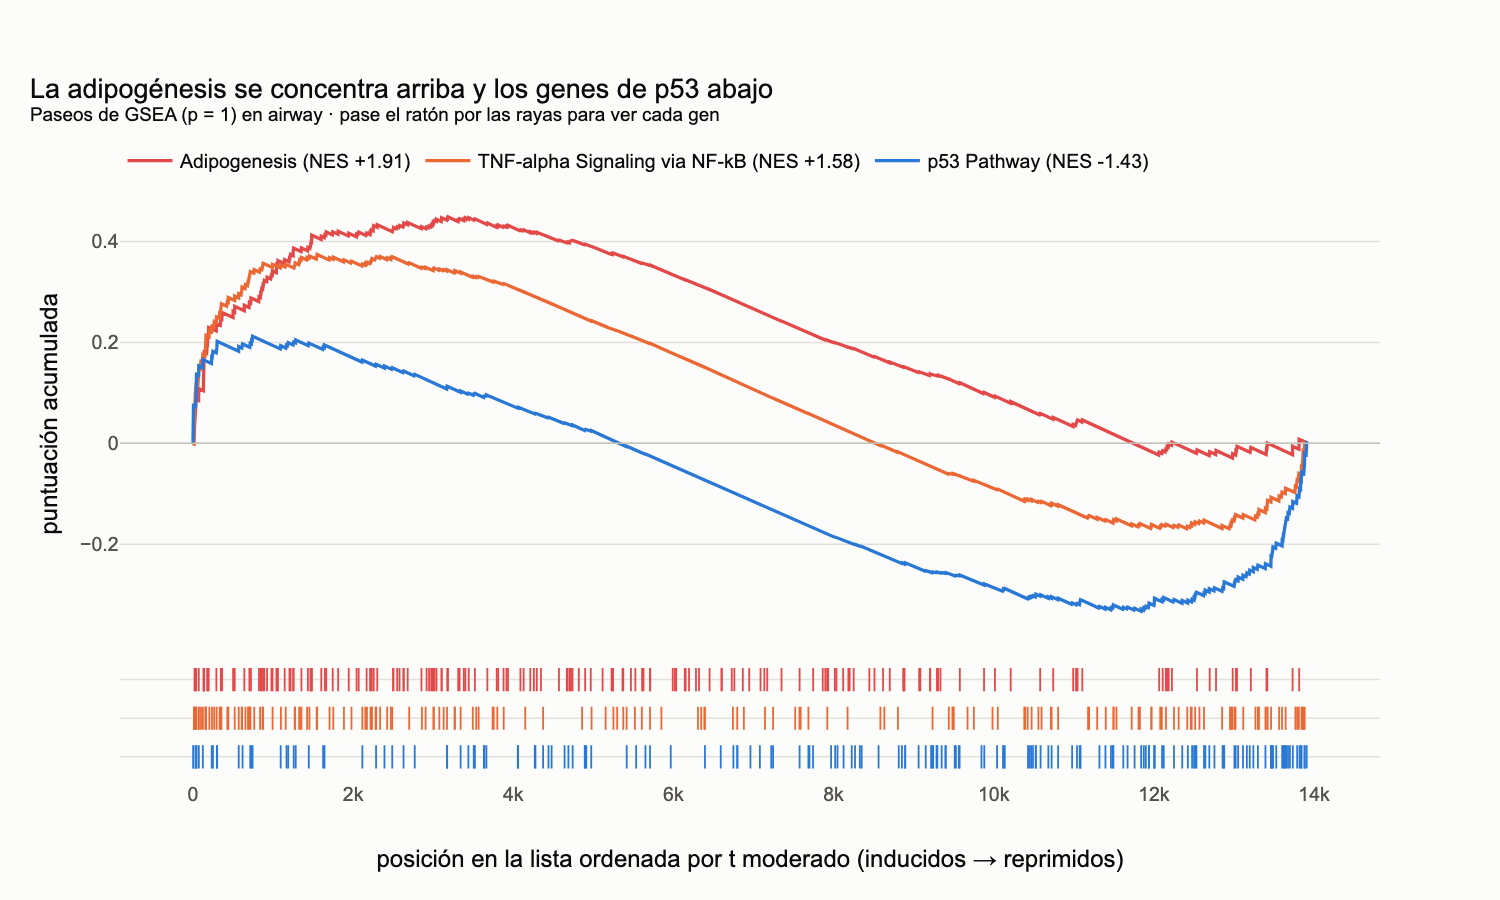

In [30]:
def walk_real(term, sets):
    idx = np.array(sorted(pos_air[g] for g in sets[term] if g in pos_air))
    inset = np.zeros(N_air, bool); inset[idx] = True
    w_ = np.where(inset, abs_r_air, 0)
    rs = np.cumsum(w_) / w_.sum() - np.cumsum(~inset) / (~inset).sum()
    return idx, rs

pick = [h.term.iloc[0], h.term.iloc[1], h.term.iloc[-1]]
colors = [ec.RED, ec.ORANGE, ec.BLUE]
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.78, 0.22], vertical_spacing=0.04)
step = 10
for j, (t, col) in enumerate(zip(pick, colors)):
    idx, rs = walk_real(t, libraries["Hallmark"])
    es_i = int(np.argmax(np.abs(rs))); es = rs[es_i]
    xs_ = np.unique(np.concatenate([np.arange(0, N_air, step), idx, [es_i]]))
    row = h[h.term == t].iloc[0]
    fig.add_trace(go.Scatter(x=xs_ + 1, y=rs[xs_], mode="lines", line=dict(color=col, width=2.2),
                             name=f"{t} (NES {row.NES:+.2f})",
                             hovertemplate=f"<b>{t}</b><br>posición %{{x}}<br>paseo = %{{y:.3f}}<extra></extra>"), 1, 1)
    lead = (idx <= es_i) if es > 0 else (idx >= es_i)
    fig.add_trace(go.Scatter(x=idx + 1, y=np.full(len(idx), -j - 1), mode="markers",
                             marker=dict(symbol="line-ns", size=11, line=dict(width=1.2, color=col)),
                             customdata=np.stack([genes_air[idx], r_air[idx], np.where(lead, "sí", "no")], 1),
                             hovertemplate="<b>%{customdata[0]}</b> · posición %{x}<br>t moderado = %{customdata[1]:.2f}"
                                           "<br>¿en el núcleo líder? %{customdata[2]}<extra>" + t + "</extra>",
                             showlegend=False), 2, 1)
fig.add_hline(y=0, line=dict(color=ec.BASELINE, width=1), row=1, col=1)
fig.update_yaxes(title_text="puntuación acumulada", row=1, col=1)
fig.update_yaxes(showticklabels=False, range=[-3.6, -0.4], row=2, col=1)
fig.update_xaxes(title_text="posición en la lista ordenada por t moderado (inducidos → reprimidos)", row=2, col=1)
fig.update_layout(title="La adipogénesis se concentra arriba y los genes de p53 abajo"
                        "<br><sup>Paseos de GSEA (p = 1) en airway · pase el ratón por las rayas para ver cada gen</sup>",
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=600, margin=dict(t=130))
fig.show()

> 🔎 **Qué observamos.** La marca **Adipogenesis** tiene la NES más alta: su núcleo líder, repartido por los
> primeros miles de puestos, reúne genes de metabolismo lipídico y mitocondrial (*ACADS*, *GPX3*, *TST*) y de
> señalización de insulina (*SORBS1*): muchos cambios moderados en la misma dirección, justo lo que GSEA detecta y
> un ORA con umbral estricto apenas ve (en el ORA quedaba en el puesto 12). La marca **TNF-α/NF-κB** sale
> positiva: en la lista ordenada pesan más los genes inducidos (*DUSP1*, *PER1*, *NR4A3*, *TSC22D1*, *CEBPD*) que los
> mediadores reprimidos (*LIF*, *PTGS2*, *IL6*), lo mismo que vimos en el ORA. En el extremo
> opuesto, **p53 Pathway** y **E2F Targets** (proliferación) tienen NES negativa, compatible con el conocido efecto
> antiproliferativo de los glucocorticoides en músculo liso. En KEGG, **absorción de minerales** (las
> metalotioneínas), **señalización por adipocitocinas** y **AMPK** encabezan la lista positiva, y **replicación del
> ADN** y **reparación de apareamientos erróneos** (proliferación) la negativa. La NES más negativa, «Herpes simplex
> virus 1 infection», es una advertencia: en KEGG 2021 ese conjunto tiene ≈500 genes, de los cuales unos 300 son
> factores de transcripción con dedos de zinc (*ZNF*); el nombre del conjunto no describe lo que mide aquí.
>
> Observe también la escala: las NES reales de *airway* (≈1,5–2) son más modestas que la del ejemplo del libro
> (2,41) porque los conjuntos reales mezclan genes que suben, que bajan y que no cambian.

### 8.1 ¿Y si permutamos las muestras? Sólo 16 maneras

El libro advierte que permutar genes ignora la correlación entre ellos. Con un diseño **pareado**, permutar las
etiquetas equivale a **intercambiar «tratado» y «sin tratar» dentro de cada donante**, es decir, a cambiar el signo de
las diferencias $d_{gc}$ de algunos donantes. Con 4 donantes hay sólo $2^4=16$ combinaciones, y cada una tiene su «espejo» (cambiar todos los signos
invierte la lista y da la misma $|\mathrm{ES}|$ con el signo contrario): sólo **8** son realmente distintas. Si
comparamos $|\mathrm{ES}|$, el valor $p$ más pequeño alcanzable es $2/16 = 0{,}125$, por fuerte que sea la
evidencia: es el eco en *airway* de las «diez permutaciones» que menciona el libro para 3 contra 3.

In [31]:
def moderated_t(dd):
    """t moderado para una matriz de diferencias pareadas (mismos pasos que en la sección 2)."""
    lf = dd.mean(1); v = dd.var(1, ddof=1)
    e_ = np.log(v) - special.digamma(df_g / 2) + np.log(df_g / 2)
    ev = e_.var(ddof=1) - special.polygamma(1, df_g / 2)
    d0_ = 2 * optimize.brentq(lambda x: special.polygamma(1, x) - ev, 1e-6, 1e6) if ev > 0 else 1e6
    s02_ = np.exp(e_.mean() + special.digamma(d0_ / 2) - np.log(d0_ / 2))
    return lf / np.sqrt((d0_ * s02_ + df_g * v) / (d0_ + df_g) / m_pairs)

sets_flip = {t: libraries["Hallmark"][t] for t in [h.term.iloc[0], "TNF-alpha Signaling via NF-kB", h.term.iloc[-1]]}
pc_pos = {g: i for i, g in enumerate(pc.symbol)}      # 'd' sigue el orden de 'pc', no el de 'ranking'
flip_rows = []
for signs in itertools.product([1, -1], repeat=m_pairs):
    tt = moderated_t(d * np.array(signs))
    o = np.argsort(-tt); rank_of = np.empty(len(tt), int); rank_of[o] = np.arange(len(tt))
    abs_sorted = np.abs(tt[o])
    for t, s in sets_flip.items():
        P = np.array(sorted(rank_of[pc_pos[g]] for g in s if g in pc_pos))
        flip_rows.append((signs, t, es_from_positions(P[None, :], abs_sorted)[0]))
flips = pd.DataFrame(flip_rows, columns=["signos", "term", "ES"])
for t in sets_flip:
    f = flips[flips.term == t]
    es_obs = f.ES[f.signos.apply(lambda s: all(x == 1 for x in s))].iloc[0]
    p_flip = np.mean(np.abs(f.ES) >= abs(es_obs) - 1e-12)
    print(f"{t:<32} ES observada = {es_obs:+.3f} · p por intercambio de etiquetas = {p_flip:.3f} (mínimo posible 2/16 = 0,125)")

Adipogenesis                     ES observada = +0.449 · p por intercambio de etiquetas = 0.125 (mínimo posible 2/16 = 0,125)
TNF-alpha Signaling via NF-kB    ES observada = +0.374 · p por intercambio de etiquetas = 0.125 (mínimo posible 2/16 = 0,125)
p53 Pathway                      ES observada = -0.332 · p por intercambio de etiquetas = 0.125 (mínimo posible 2/16 = 0,125)


> 🔎 **Qué observamos.** Las tres marcas quedan en el mínimo posible, $p=0{,}125$: ninguna reordenación de
> etiquetas supera la observada, pero con 4 donantes eso no basta para declarar nada. La permutación de etiquetas
> es honesta con la correlación entre genes, pero **no tiene resolución**. De ahí que en la
> práctica se permuten los genes (anticonservador) o se usen métodos que modelan la correlación entre genes
> (CAMERA, ROAST en limma). Con seis o más réplicas por grupo la permutación de muestras vuelve a ser viable; el
> ejercicio 8 del libro propone esa comparación.

### 8.2 Comparación con `gseapy`

`gseapy` (Fang et al., 2023) reimplementa GSEA en Python con un núcleo en Rust. Su modo `prerank` recibe la lista
ordenada y una colección y devuelve ES, NES, $p$ y FDR. En Colab se instala con `pip` (≈10 s).

gseapy 1.3.1: 50 conjuntos en 1.2 s
máxima diferencia de ES: 4.44e-16
correlación de NES: 1.0000


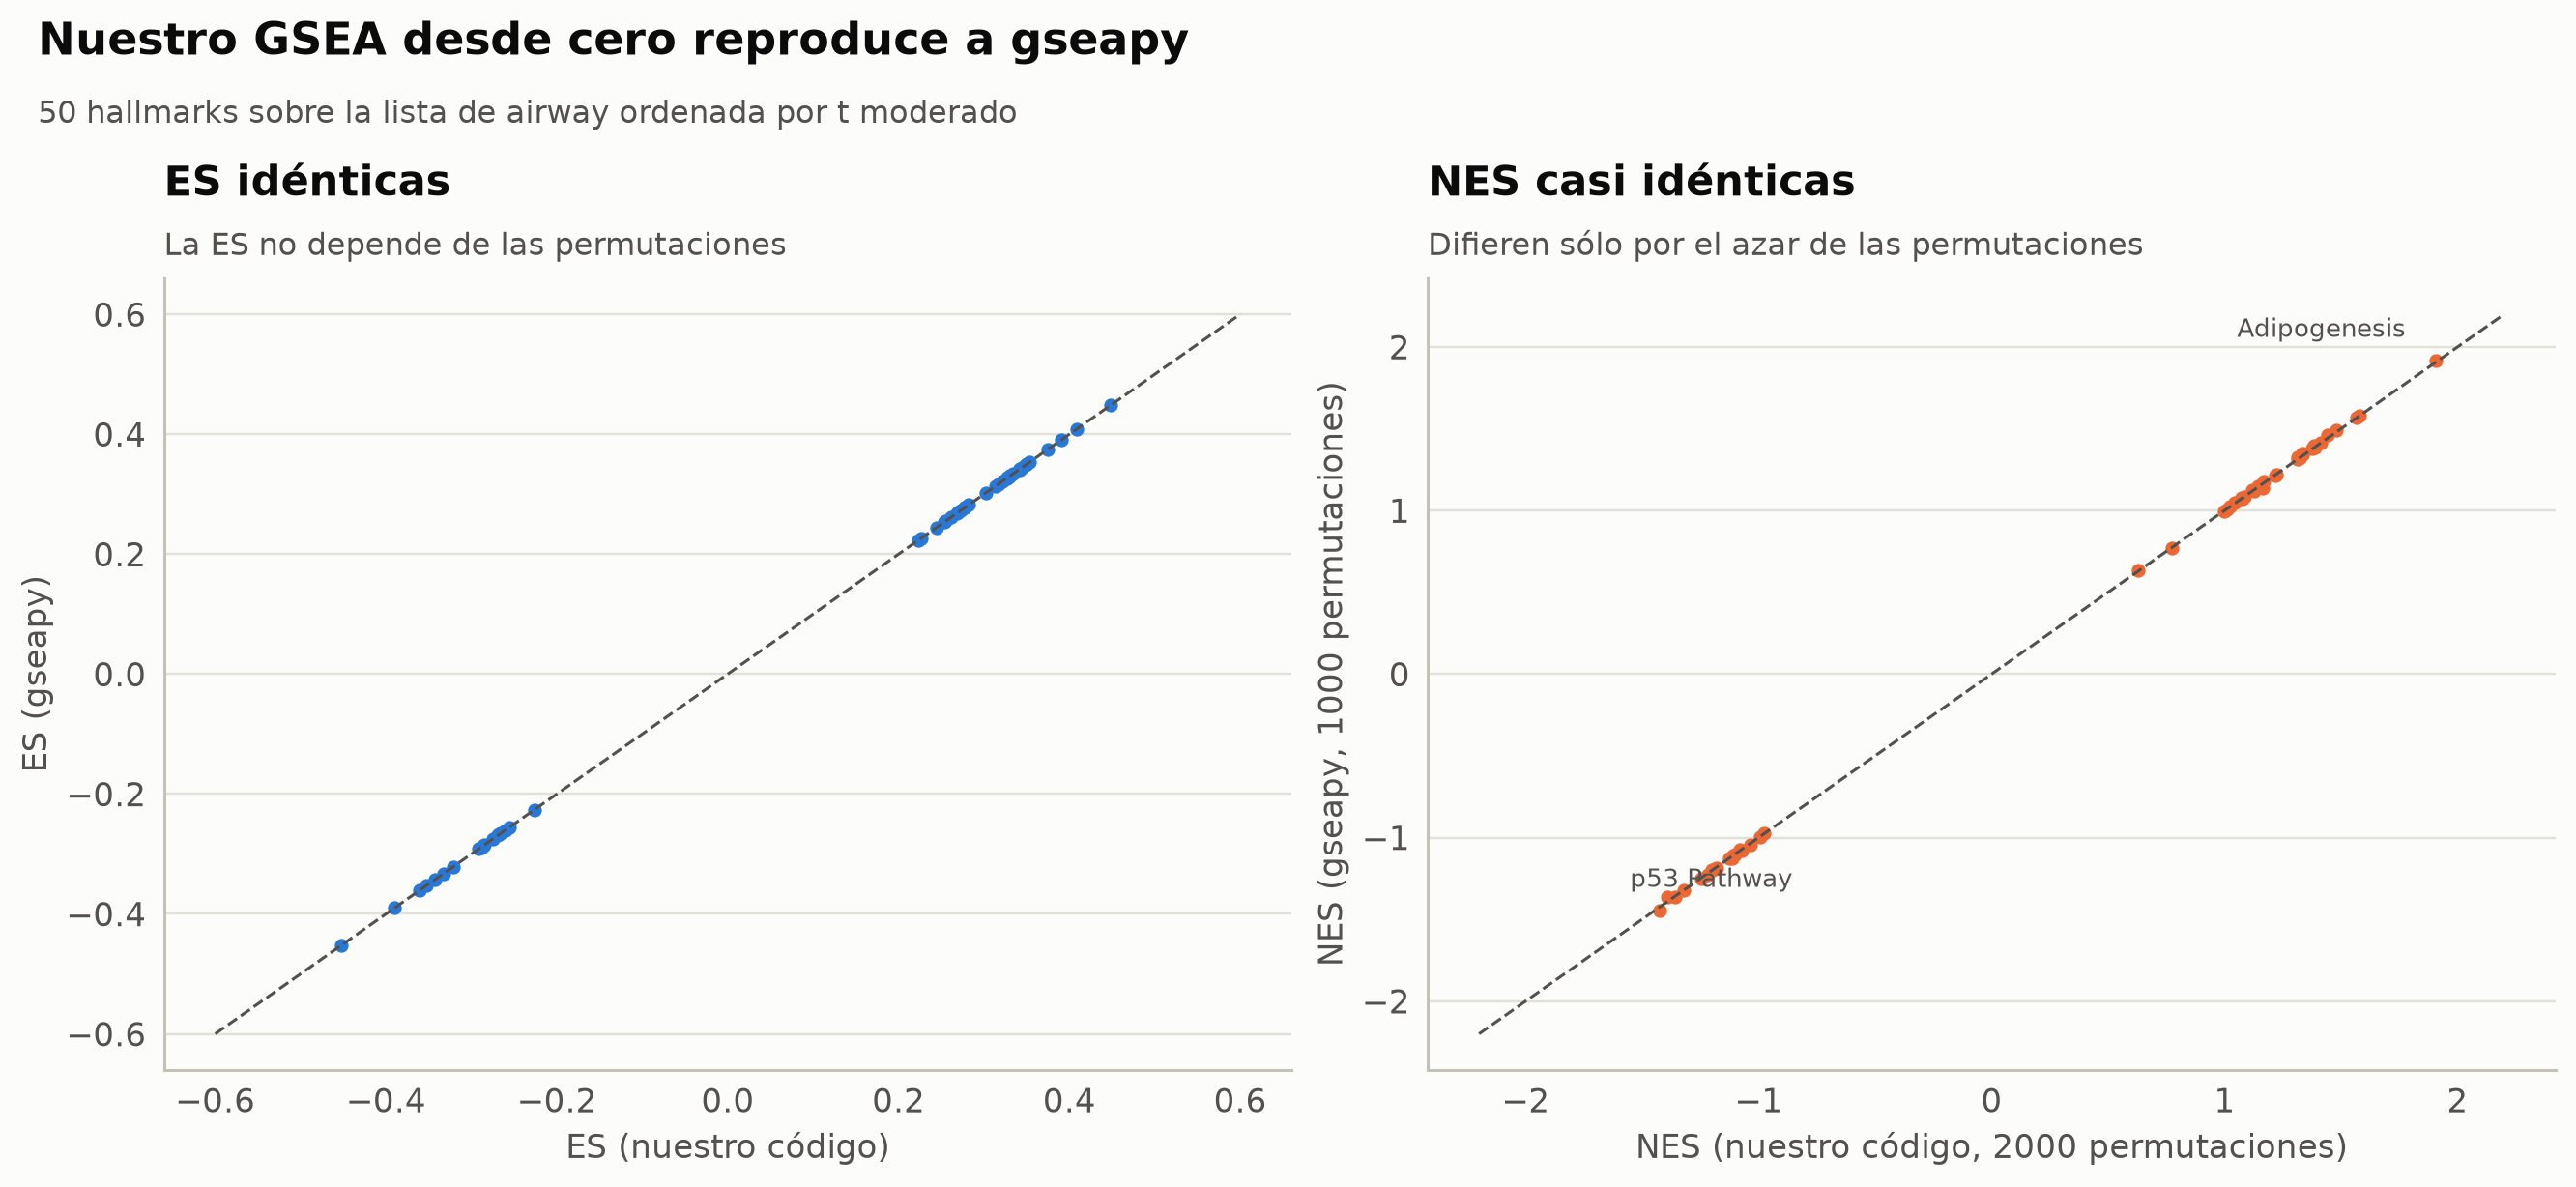

,Term,ES,NES,NOM p-val,FDR q-val,Lead_genes
0,Adipogenesis,0.449,1.918,0.000,0.006,SPARCL1;GPX3;STOM;TST;ACADS;SLC5A6;SORBS1;OMD;...
1,TNF-alpha Signaling via NF-kB,0.374,1.580,0.000,0.097,DUSP1;DNAJB4;PER1;NR4A3;TSC22D1;PTX3;CEBPD;PDL...
2,Androgen Response,0.409,1.571,0.002,0.069,ADAMTS1;TSC22D1;STEAP4;PDLIM5;FKBP5;GPD1L;CDC1...
3,Oxidative Phosphorylation,0.349,1.491,0.004,0.100,CPT1A;ALDH6A1;ISCA1;CYB5A;UQCRC1;SLC25A4;ATP1B...
4,UV Response Dn,0.353,1.460,0.002,0.101,DUSP1;COL11A1;ANXA4;MT1E;PDLIM5;TGFBR2;APBB2;C...
5,p53 Pathway,-0.332,-1.446,0.002,0.314,RRAD;CDKN1A;RAP2B;PLK2;HSPA4L;SDC1;LIF;SOCS1;S...
6,Complement,0.344,1.414,0.009,0.131,CTSC;DGKH;MAFF;RAF1;ANG;DUSP5;COL4A2;MMP15;GNB...
7,Hypoxia,0.329,1.394,0.015,0.131,DUSP1;MT2A;ERRFI1;MT1E;ATF3;IRS2;GLRX;CITED2;A...


In [32]:
try:
    import gseapy as gp
except ImportError:
    if IN_COLAB:
        %pip install -q gseapy
        import gseapy as gp
    else:
        gp = None
        print("gseapy no está instalado; omitimos la comparación (pip install gseapy)")

if gp is not None:
    t_ = time.time()
    pre = gp.prerank(rnk=rk[["symbol", "t"]], gene_sets={k: sorted(v) for k, v in libraries["Hallmark"].items()},
                     permutation_num=1000, min_size=15, max_size=500, weight=1.0, seed=7, threads=2,
                     outdir=None, verbose=False)
    gpres = pre.res2d.astype({"ES": float, "NES": float, "NOM p-val": float, "FDR q-val": float})
    print(f"gseapy {gp.__version__}: {len(gpres)} conjuntos en {time.time()-t_:.1f} s")
    both = gsea_res["Hallmark"].merge(gpres[["Term", "ES", "NES", "NOM p-val", "FDR q-val"]], left_on="term",
                                      right_on="Term", suffixes=("", "_gseapy"))
    print(f"máxima diferencia de ES: {np.abs(both.ES - both.ES_gseapy).max():.2e}")
    print(f"correlación de NES: {np.corrcoef(both.NES, both.NES_gseapy)[0, 1]:.4f}")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    axes[0].scatter(both.ES, both.ES_gseapy, color=ec.BLUE, s=22)
    axes[0].plot([-0.6, 0.6], [-0.6, 0.6], color=ec.INK_2, ls="--", lw=1)
    axes[0].set_xlabel("ES (nuestro código)"); axes[0].set_ylabel("ES (gseapy)")
    ec.title(axes[0], "ES idénticas", "La ES no depende de las permutaciones")
    axes[1].scatter(both.NES, both.NES_gseapy, color=ec.ORANGE, s=22)
    axes[1].plot([-2.2, 2.2], [-2.2, 2.2], color=ec.INK_2, ls="--", lw=1)
    for _, rr in both.loc[[both.NES.idxmax(), both.NES.idxmin()]].iterrows():
        axes[1].annotate(rr.term[:26], (rr.NES, rr.NES_gseapy), xytext=(-10, 8), textcoords="offset points",
                         fontsize=8.5, ha="right" if rr.NES > 0 else "left", color=ec.INK_2)
    axes[1].set_xlabel("NES (nuestro código, 2000 permutaciones)"); axes[1].set_ylabel("NES (gseapy, 1000 permutaciones)")
    ec.title(axes[1], "NES casi idénticas", "Difieren sólo por el azar de las permutaciones")
    ec.fig_title(fig, "Nuestro GSEA desde cero reproduce a gseapy", "50 hallmarks sobre la lista de airway ordenada por t moderado")
    plt.show()
    display(gpres.head(8)[["Term", "ES", "NES", "NOM p-val", "FDR q-val", "Lead_genes"]]
            .assign(Lead_genes=lambda x: x.Lead_genes.str.slice(0, 60)).round(3))

> 🔎 **Qué observamos.** Las ES coinciden hasta el último decimal: es el mismo cálculo determinista de la ecuación
> 11-gsea. Las NES difieren sólo en el segundo decimal, porque cada implementación usa sus propias permutaciones
> aleatorias. Los valores $q$ no son comparables uno a uno con nuestros BH: `gseapy` sigue el método de FDR del GSEA
> original, que compara cada NES con las NES nulas de **todos** los conjuntos, y por eso puede dar valores mayores
> o menores según el conjunto.

---

## 9. Lo que un enriquecimiento no dice

Un término enriquecido es una **hipótesis**, no una conclusión. Tres razones:

1. **Las anotaciones están sesgadas hacia los genes más estudiados.** *TP53* o *TNF* tienen cientos de anotaciones;
   un gen descubierto hace cinco años, casi ninguna. Los términos «populares» tienen ventaja.
2. **Muchas anotaciones se infieren electrónicamente** sin validación experimental (código de evidencia IEA).
3. **La estructura anidada de la GO** hace que un mismo grupo de genes produzca decenas de términos redundantes que
   parecen resultados independientes.

Veamos el tercer punto con nuestros datos: ¿cuánto se solapan los 15 términos GO más significativos del ORA de los
genes reprimidos? Medimos el solapamiento con el índice de Jaccard, $|A\cap B|/|A\cup B|$, **de los genes de la
lista que sostienen cada término**.

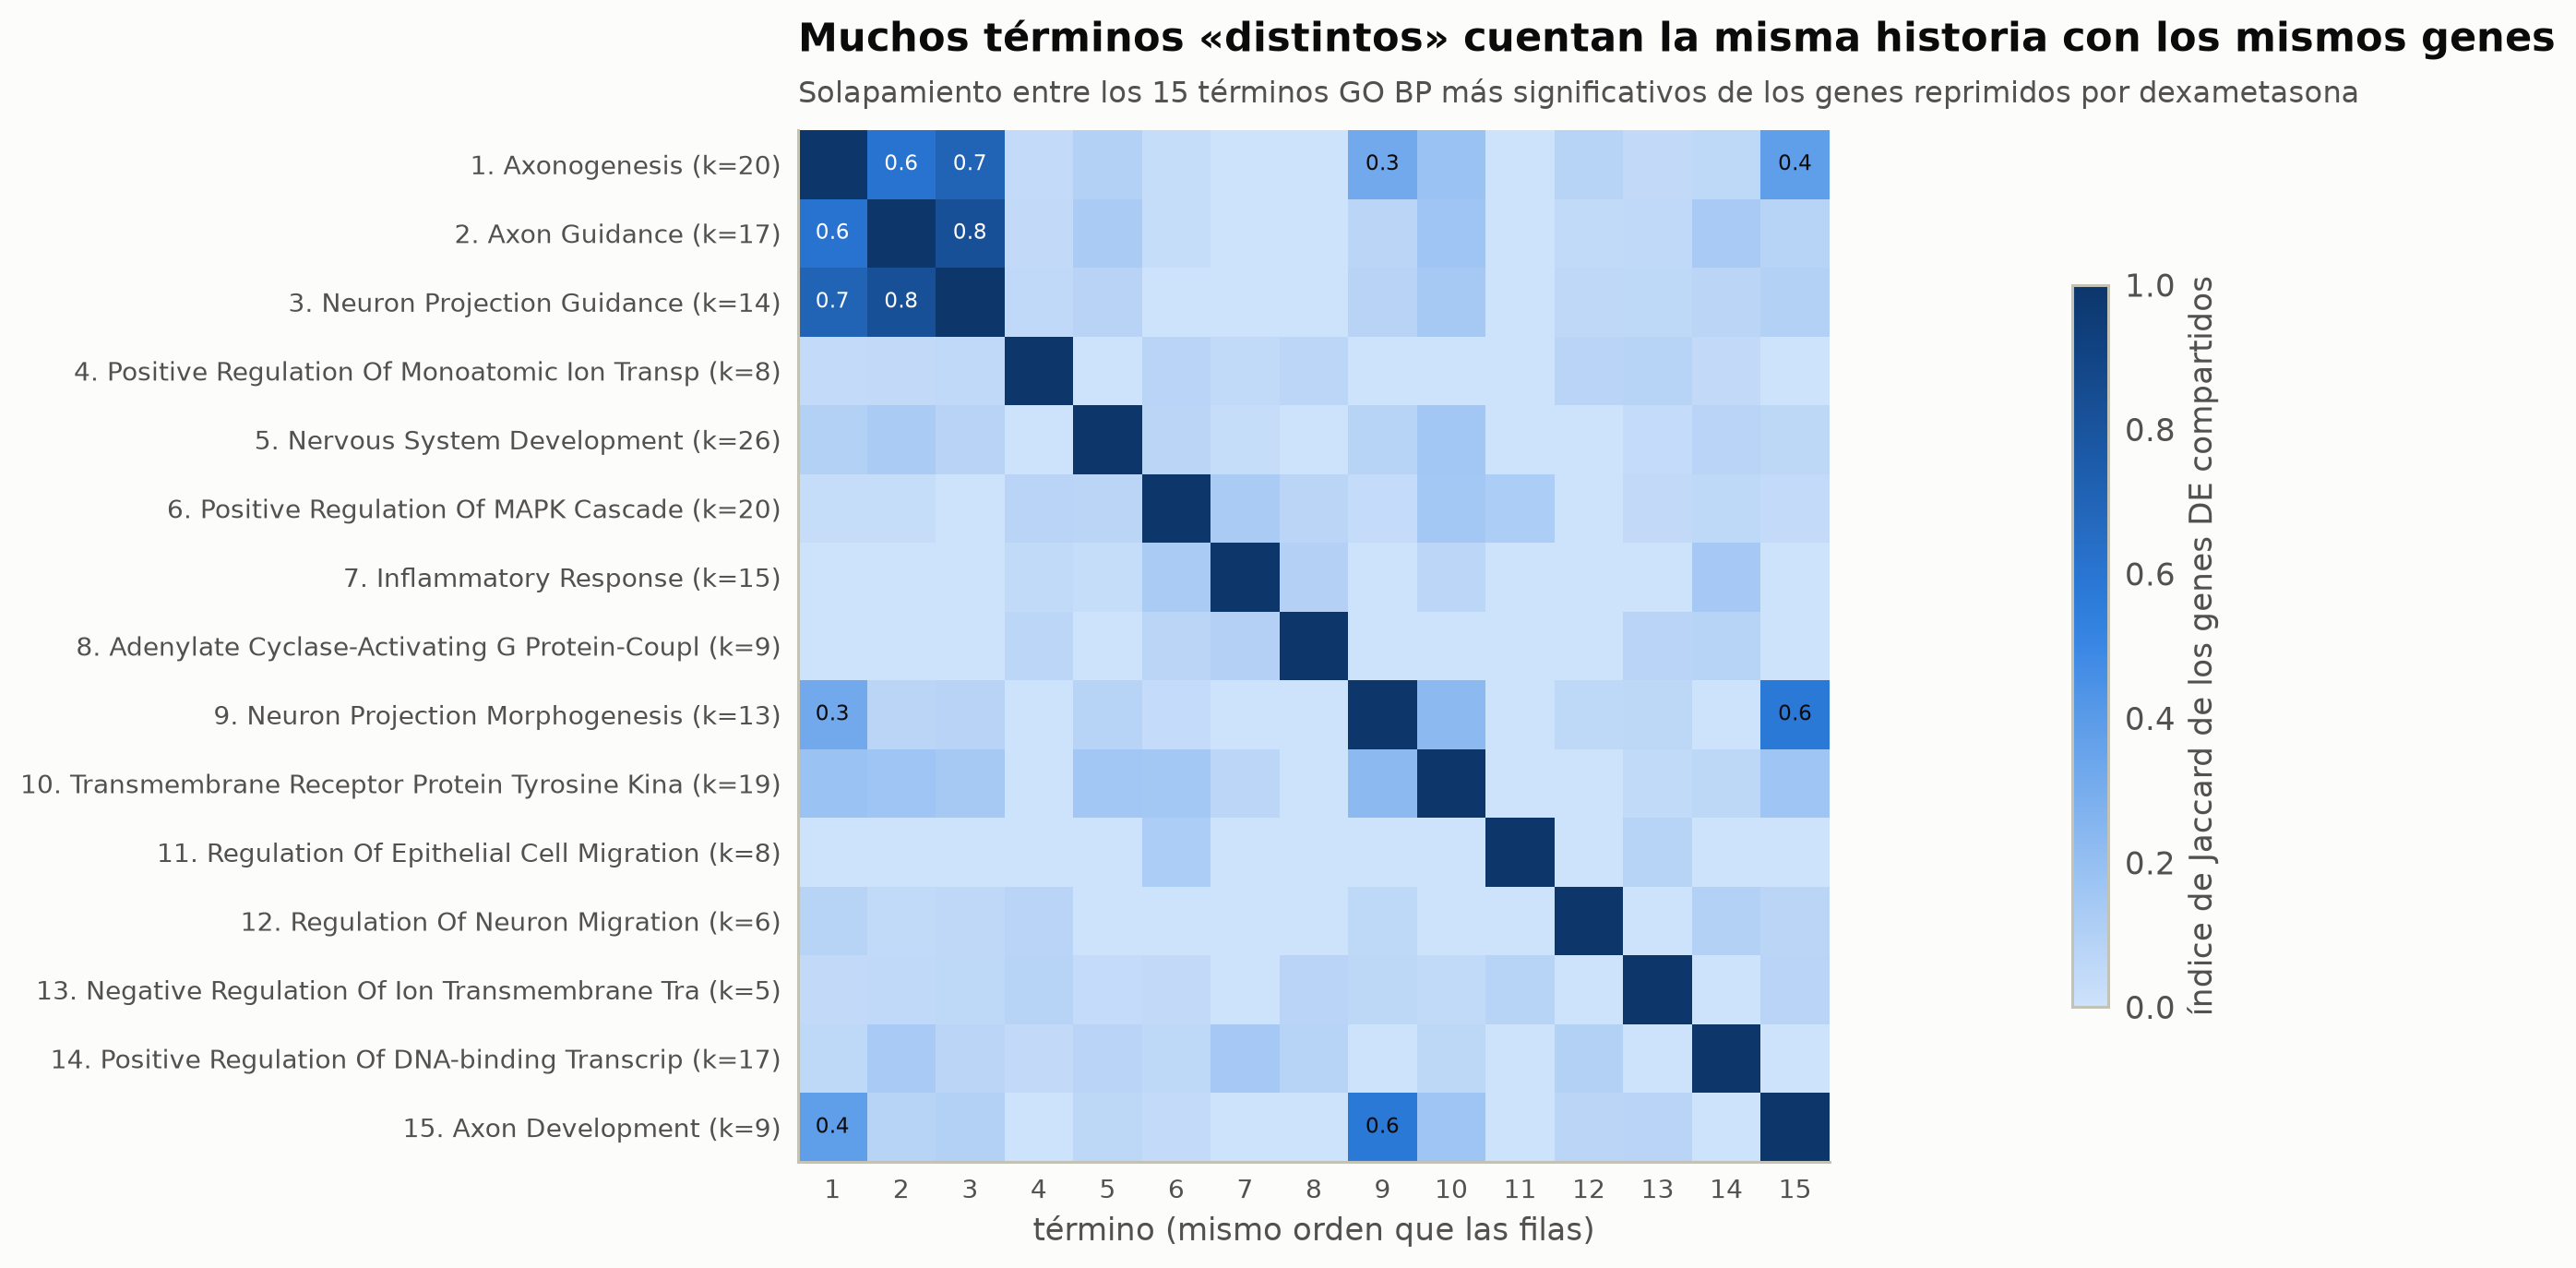

In [33]:
top_go = ora_res[("GO BP", "down")].head(15).copy()
hit_sets = [set(g.split(", ")) for g in top_go.genes]
labels = [t.split(" (GO")[0][:44] for t in top_go.term]
J = np.array([[len(a & b) / len(a | b) for b in hit_sets] for a in hit_sets])
fig, ax = plt.subplots(figsize=(11, 8.2))
im = ax.imshow(J, cmap=ec.CMAP_SEQ, vmin=0, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(range(1, len(labels) + 1), fontsize=9)
ax.set_yticklabels([f"{i+1}. {l} (k={k})" for i, (l, k) in enumerate(zip(labels, top_go.k))], fontsize=9)
ax.grid(False)
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j and J[i, j] >= 0.3:
            ax.text(j, i, f"{J[i, j]:.1f}", ha="center", va="center", fontsize=7.5,
                    color="white" if J[i, j] > 0.6 else ec.INK)
cb = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02); cb.set_label("índice de Jaccard de los genes DE compartidos")
ax.set_xlabel("término (mismo orden que las filas)")
ec.title(ax, "Muchos términos «distintos» cuentan la misma historia con los mismos genes",
         "Solapamiento entre los 15 términos GO BP más significativos de los genes reprimidos por dexametasona")
plt.show()

> 🔎 **Qué observamos.** Axonogénesis, guía axonal, guía de proyecciones neuronales, morfogénesis de proyecciones
> neuronales y desarrollo del axón (términos 1, 2, 3, 9 y 15) comparten buena parte de sus genes: son **un único
> hallazgo** repetido con nombres distintos, heredado por la regla del camino verdadero y por anotaciones
> redundantes. Los demás términos se solapan poco y sí aportan información distinta. Contarlos
> como hallazgos independientes infla la impresión de «muchos procesos alterados».

**Qué informar siempre** (y qué pedir cuando lea un artículo):

| Elemento | En esta lección |
|---|---|
| Universo | 13 900 genes codificantes con media normalizada ≥ 10 |
| Versión de la anotación | Enrichr: MSigDB Hallmark 2020, KEGG 2021 Human, GO BP 2023; genes en GENCODE v26 |
| Criterio de la lista (ORA) | $q<0{,}05$ y $\lvert\log_2\mathrm{FC}\rvert>1$, por dirección |
| Estadístico de orden (GSEA) | $t$ moderado pareado; $p=1$; 2000 permutaciones de genes |
| Corrección múltiple | BH por colección y dirección |
| Tamaños de conjunto | 15–500 genes del universo |
| Genes que sostienen cada término | columna `genes` (ORA) y núcleo líder (GSEA) |

Y prefiera pocos conjuntos bien definidos (*hallmarks*, rutas de KEGG) a miles de términos solapados cuando el
objetivo sea **interpretar**; use la GO completa cuando el objetivo sea **explorar**, con herramientas que
resuman la redundancia (agrupar términos por genes compartidos, o métodos que tienen en cuenta el grafo).

---

## 10. Ejercicios

**Ejercicio 1 (básico).** Volviendo al autobús: la ciudad tiene $N=5000$ habitantes y $K=100$ pelirrojos. ¿A partir
de cuántos pelirrojos en un autobús de 40 pasajeros el valor $p$ hipergeométrico baja de 0,05? ¿Y de 0,001? Repita
con un autobús de 200 pasajeros y comente cómo cambia el umbral respecto al número esperado.

**Ejercicio 2 (intermedio).** El ORA depende del umbral. Repita el ORA de *hallmarks* de los genes inducidos con
cuatro listas: $q<0{,}01$, $q<0{,}05$, $q<0{,}1$ (todas con $\log_2\mathrm{FC}>0$) y $q<0{,}05$ con
$\log_2\mathrm{FC}>1$. Muestre en una tabla el rango y el $q$ de «TNF-alpha Signaling via NF-kB» y «Adipogenesis» en
cada caso. ¿Cuál es más estable? ¿Qué sugiere eso sobre la ventaja de GSEA?

**Ejercicio 3 (intermedio; ejercicio 9 del libro).** Para el ejemplo «Un enriquecimiento espurio», implemente la
corrección por longitud con la hipergeométrica no central de Wallenius (`stats.nchypergeom_wallenius`), usando como
peso del término la razón entre la PWF media de sus genes y la del resto. Compare la media y el valor $p$ con los
del remuestreo (8,79 y 0,168).

**Ejercicio 4 (intermedio).** Repita el GSEA de *hallmarks* sobre *airway* con $p=0$ (sin pesos). ¿Qué conjuntos
ganan o pierden más NES? Relacione la respuesta con la explicación del libro sobre los genes sin cambio que diluyen
la señal.

**Ejercicio 5 (avanzado).** El GSEA de la sección 8 usa 2000 permutaciones, así que el $p$ nominal no puede bajar de
$1/2001$. Para la marca con mayor NES, estime cuántas permutaciones harían falta para distinguir su $p$ real, y
compruébelo aumentando `N_PERM` a 20 000 sólo para ese conjunto. ¿Qué ventaja tiene el enfoque de fgsea aquí?

In [34]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
for n_bus_ in (40, 200):
    Xb = stats.hypergeom(5000, 100, n_bus_)
    ks = np.arange(0, n_bus_ + 1)
    k05 = ks[Xb.sf(ks - 1) < 0.05][0]; k001 = ks[Xb.sf(ks - 1) < 0.001][0]
    print(f"autobús de {n_bus_}: esperado {n_bus_*100/5000:.1f} · p<0,05 desde k = {k05} · p<0,001 desde k = {k001}")
# Con 40 pasajeros basta con 3 pelirrojos (≈4 veces lo esperado) para p<0,05; con 200 hacen falta 9
# (≈2,2 veces lo esperado): con listas más grandes, enriquecimientos relativos más modestos ya son significativos.

autobús de 40: esperado 0.8 · p<0,05 desde k = 3 · p<0,001 desde k = 6
autobús de 200: esperado 4.0 · p<0,05 desde k = 8 · p<0,001 desde k = 12


In [35]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
crit = {"q<0,01": (ranking.padj < 0.01) & (ranking.log2FC > 0),
        "q<0,05": (ranking.padj < 0.05) & (ranking.log2FC > 0),
        "q<0,1": (ranking.padj < 0.1) & (ranking.log2FC > 0),
        "q<0,05 y LFC>1": (ranking.padj < 0.05) & (ranking.log2FC > 1)}
rows = []
for lab, mask in crit.items():
    r = ora_table(set(ranking.symbol[mask]), libraries["Hallmark"], universe)
    for t in ["TNF-alpha Signaling via NF-kB", "Adipogenesis"]:
        i = r.index[r.term == t][0]
        rows.append({"lista": lab, "n": int(mask.sum()), "conjunto": t, "rango": i + 1, "q": r.q[i]})
display(pd.DataFrame(rows).pivot(index="lista", columns="conjunto", values=["rango", "q"]).round(4))
# TNF-α/NF-κB es el primero con cualquier lista: su señal está en genes con cambios grandes. Adipogenesis pasa
# del puesto 12 (lista estricta) al 2 (q<0,05 o q<0,1): su señal está en muchos genes con cambios moderados, que
# sólo entran con umbrales laxos. El orden depende del umbral; GSEA evita elegirlo (y da a Adipogenesis la NES máxima).

rango                                          q  \
conjunto       Adipogenesis TNF-alpha Signaling via NF-kB Adipogenesis   
lista                                                                    
q<0,01                  9.0                           1.0       0.0274   
q<0,05                  2.0                           1.0       0.0012   
q<0,05 y LFC>1         12.0                           1.0       0.0355   
q<0,1                   2.0                           1.0       0.0006   

                                              
conjunto       TNF-alpha Signaling via NF-kB  
lista                                         
q<0,01                                0.0000  
q<0,05                                0.0000  
q<0,05 y LFC>1                        0.0000  
q<0,1                                 0.0001

In [36]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
inT_b = np.zeros(G, bool); inT_b[term_b] = True
omega_b = pwf_b[inT_b].mean() / pwf_b[~inT_b].mean()
W = stats.nchypergeom_wallenius(N_b, K_b, n_b, omega_b)
print(f"ω = {omega_b:.3f} · media Wallenius = {W.mean():.2f} (remuestreo: {null_w.mean():.2f})")
print(f"p Wallenius = {W.sf(k_b - 1):.3f} (remuestreo: {p_w:.3f}; hipergeométrico: {ora(k_b, N_b, K_b, n_b):.3f})")
# Las dos correcciones coinciden en lo esencial: la media sube de 6,06 a ≈8,8 y el p pasa de 0,018 a ≈0,17.
# Wallenius es instantánea (una fórmula por término); el remuestreo es más general pero más lento.

ω = 1.486 · media Wallenius = 8.86 (remuestreo: 8.79)
p Wallenius = 0.176 (remuestreo: 0.168; hipergeométrico: 0.018)


In [37]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
def gsea_es_only(sets, p=1.0):
    out = {}
    for t, s in sets.items():
        idx = np.array(sorted(pos_air[g] for g in s if g in pos_air))
        if 15 <= len(idx) <= 500:
            es = es_from_positions(idx[None, :], abs_r_air, p=p)[0]
            nul = es_from_positions(PERM[:, :len(idx)], abs_r_air, p=p)
            same = nul[nul >= 0] if es >= 0 else nul[nul < 0]
            out[t] = es / np.abs(same).mean()
    return pd.Series(out)
cmp4 = pd.DataFrame({"NES p=1": gsea_es_only(libraries["Hallmark"], 1.0), "NES p=0": gsea_es_only(libraries["Hallmark"], 0.0)})
cmp4["cambio"] = cmp4["NES p=0"] - cmp4["NES p=1"]
display(cmp4.sort_values("cambio").round(2).iloc[np.r_[0:4, -4:0]])
# Sin pesos, varios conjuntos cambian incluso de signo: con p = 1 su ES dependía de unos pocos genes con t enormes
# en un extremo; con p = 0 manda la posición de la mayoría de sus genes, que está en el otro. Es la dilución que
# describe el libro, vista desde el otro lado.

,NES p=1,NES p=0,cambio
Estrogen Response Early,1.13,-1.42,-2.55
KRAS Signaling Dn,1.15,-1.16,-2.32
Apoptosis,1.00,-1.22,-2.22
Glycolysis,1.17,-0.77,-1.94
heme Metabolism,-1.07,0.88,1.95
Notch Signaling,-1.08,1.20,2.29
PI3K/AKT/mTOR Signaling,-1.13,1.34,2.46
Myogenesis,-1.11,1.75,2.86


In [38]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
best = gsea_res["Hallmark"].iloc[0]
idx = np.array(sorted(pos_air[g] for g in libraries["Hallmark"][best.term] if g in pos_air))
big_rng = np.random.default_rng(5)
nul = np.concatenate([es_from_positions(np.argsort(big_rng.random((2000, N_air)), axis=1)[:, :len(idx)], abs_r_air)
                      for _ in range(10)])                                   # 20 000 permutaciones en bloques
pos_n = nul[nul >= 0]
print(f"{best.term}: ES = {best.ES:.3f}; con {len(nul)} permutaciones, ES nulas ≥ observada: {np.sum(pos_n >= best.ES)}")
print(f"p ≈ {(np.sum(pos_n >= best.ES) + 1) / (len(pos_n) + 1):.2e}")
# Si ninguna permutación alcanza la ES, p sólo está acotado por 1/(n+ + 1). fgsea reutiliza las permutaciones
# entre conjuntos del mismo tamaño y, en su versión multinivel, estima p muy pequeños sin millones de permutaciones.

Adipogenesis: ES = 0.449; con 20000 permutaciones, ES nulas ≥ observada: 0
p ≈ 9.55e-05


---

## 📌 Resumen

* Una lista de genes se traduce en hipótesis con **colecciones de conjuntos**: la **GO** (tres ontologías organizadas
  como grafo acíclico dirigido, con la **regla del camino verdadero**), las rutas de **KEGG** y los 50 ***hallmarks***
  de MSigDB.
* El **ORA** pregunta si hay más genes del término en la lista de los esperados, $\mathbb{E}[X]=nK/N$, con la
  **hipergeométrica** (idéntica a Fisher unilateral) y BH sobre todos los términos. En *airway*, los genes inducidos
  por dexametasona se enriquecen en los frenos de NF-κB, migración y metabolismo, y los reprimidos en citocinas.
* El **universo** son los genes analizados tras el filtrado, **no el genoma**: con el genoma, casi todos los términos
  de genes del tejido parecen enriquecidos.
* El **sesgo de longitud** hace que los genes largos se detecten mejor: la **PWF** de goseq lo mide y el remuestreo
  ponderado o la **Wallenius** lo corrigen. En el ejemplo del libro, $p=0{,}018$ pasa a $0{,}168$. En *airway* existe
  para la lista $q<0{,}05$ y desaparece con un umbral de efecto.
* **GSEA** usa la lista completa ordenada y detecta cambios pequeños y coordinados: paseo
  $P_{\mathrm{hit}}-P_{\mathrm{miss}}$, ES, NES, núcleo líder y $p$ por permutación, limitado por el número de
  permutaciones. Con $p=1$ los genes con cambios fuertes dominan; con $p=0$, los genes sin cambio diluyen la señal.
* Permutar genes es rápido pero anticonservador; permutar muestras respeta la correlación pero, con 4 pares, sólo
  ofrece 16 permutaciones.
* Un enriquecimiento es una **hipótesis**: informe universo, versión de la anotación, criterio, corrección y
  **los genes** que sostienen cada término, y desconfíe de la redundancia.

## 📚 Lecturas recomendadas

* Ashburner, M. et al. (2000). Gene Ontology: tool for the unification of biology. *Nature Genetics* 25:25–29.
  [doi:10.1038/75556](https://doi.org/10.1038/75556)
* The Gene Ontology Consortium (2023). The Gene Ontology knowledgebase in 2023. *Genetics* 224:iyad031.
  [doi:10.1093/genetics/iyad031](https://doi.org/10.1093/genetics/iyad031)
* Kanehisa, M. y Goto, S. (2000). KEGG: Kyoto Encyclopedia of Genes and Genomes. *Nucleic Acids Research* 28:27–30.
  [doi:10.1093/nar/28.1.27](https://doi.org/10.1093/nar/28.1.27)
* Liberzon, A. et al. (2015). The Molecular Signatures Database hallmark gene set collection. *Cell Systems*
  1:417–425. [doi:10.1016/j.cels.2015.12.004](https://doi.org/10.1016/j.cels.2015.12.004)
* Young, M. D., Wakefield, M. J., Smyth, G. K. y Oshlack, A. (2010). Gene ontology analysis for RNA-seq: accounting
  for selection bias. *Genome Biology* 11:R14. [doi:10.1186/gb-2010-11-2-r14](https://doi.org/10.1186/gb-2010-11-2-r14)
* Mootha, V. K. et al. (2003). PGC-1α-responsive genes involved in oxidative phosphorylation are coordinately
  downregulated in human diabetes. *Nature Genetics* 34:267–273. [doi:10.1038/ng1180](https://doi.org/10.1038/ng1180)
* Subramanian, A. et al. (2005). Gene set enrichment analysis: a knowledge-based approach for interpreting
  genome-wide expression profiles. *PNAS* 102:15545–15550.
  [doi:10.1073/pnas.0506580102](https://doi.org/10.1073/pnas.0506580102)
* Korotkevich, G. et al. (2016). Fast gene set enrichment analysis. *bioRxiv*.
  [doi:10.1101/060012](https://doi.org/10.1101/060012)
* Kuleshov, M. V. et al. (2016). Enrichr: a comprehensive gene set enrichment analysis web server 2016 update.
  *Nucleic Acids Research* 44:W90–W97. [doi:10.1093/nar/gkw377](https://doi.org/10.1093/nar/gkw377)
* Fang, Z., Liu, X. y Peltz, G. (2023). GSEApy: a comprehensive package for performing gene set enrichment analysis
  in Python. *Bioinformatics* 39:btac757. [doi:10.1093/bioinformatics/btac757](https://doi.org/10.1093/bioinformatics/btac757)
* Smyth, G. K. (2004). Linear models and empirical Bayes methods for assessing differential expression in
  microarray experiments. *Statistical Applications in Genetics and Molecular Biology* 3:Article 3.
  [doi:10.2202/1544-6115.1027](https://doi.org/10.2202/1544-6115.1027)
* Himes, B. E. et al. (2014). RNA-Seq transcriptome profiling identifies CRISPLD2 as a glucocorticoid responsive
  gene that modulates cytokine function in airway smooth muscle cells. *PLoS One* 9:e99625.
  [doi:10.1371/journal.pone.0099625](https://doi.org/10.1371/journal.pone.0099625)
* Wilks, C. et al. (2021). recount3: summaries and queries for large-scale RNA-seq expression and splicing.
  *Genome Biology* 22:323. [doi:10.1186/s13059-021-02533-6](https://doi.org/10.1186/s13059-021-02533-6)
* Rhen, T. y Cidlowski, J. A. (2005). Antiinflammatory action of glucocorticoids — new mechanisms for old drugs.
  *New England Journal of Medicine* 353:1711–1723. [doi:10.1056/NEJMra050541](https://doi.org/10.1056/NEJMra050541)

In [39]:
print(f"⏱️ Tiempo total de la lección: {time.time() - T0:.0f} s")

⏱️ Tiempo total de la lección: 47 s


---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)